# Week-15

ecosystem_palette = {
    "Lakes": "#56B4E9",
    "Streams": "#009E73",
    "Marine": "#0072B2",
    "Terrestrial aboveground": "#4DAF4A",
    "Terrestrial belowground": "#A6761D",
}

metric_palette = {
    "ROC-AUC": "#7B3294",   # purple
    "PR-AUC": "#C51B7D",    # magenta
    "Precision": "#FE6100", # orange
    "Recall": "#CAB2D6",    # violet
    "F1": "#E6AB02",        # mustard
    "TSS": "#666666",       # dark gray
    "TPR": "#1B9E77",       # teal-green
}

version_palette = {
    "Original": "#7570B3",
    "Directed": "#1F78B4",
    "Directed-Negative": "#1B9E77",
}

network_type_palette = {
    "Empirical": "#3A7D44",
    "Pseudo": "#C6923A",
}

[INFO] Foodwebs with Nodes >= 40: 160
[INFO] Foodwebs in results before filter: 290
[INFO] Foodwebs in results after filter: 160


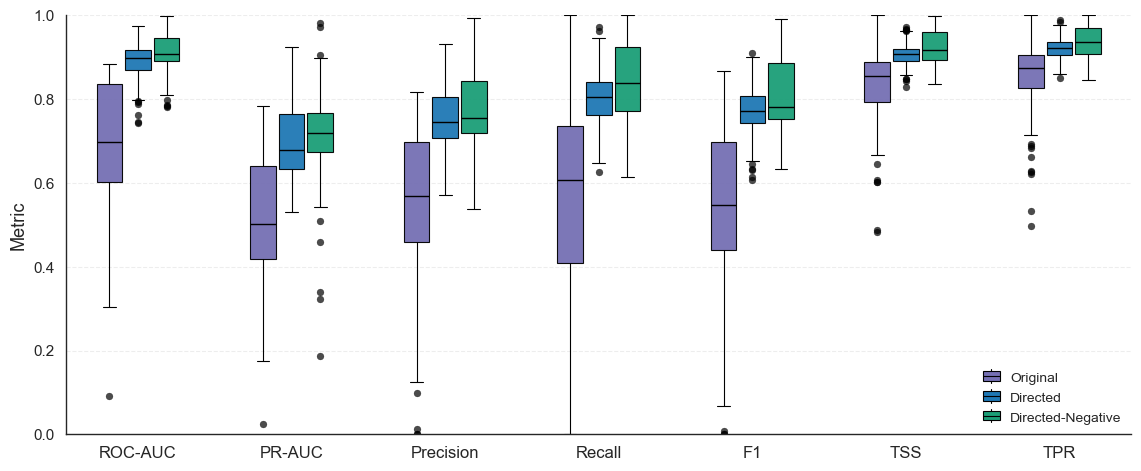

In [8]:
import os
import re
import math
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib.legend_handler import HandlerBase


# =========================
# Style (match old snippet)
# =========================
sns.set_theme(context="paper", style="white")


# =========================
# Config
# =========================
RESULTS_DIR_ORIGINAL = Path("../../../src/matlab/data/result_wlnm_original_pseudo_properties_k60_evaluate_unseen-false/prediction_scores_logs")
RESULTS_DIR_DIRECTED = Path("../../../src/matlab/data/result_wlnm_directed_pseudo_properties_k60_evaluate_unseen-false/prediction_scores_logs")
RESULTS_DIR_DIR_NEG  = Path("../../../src/matlab/data/result_wlnm_dir_neg_pseudo_properties_k60_evaluate_unseen-false/prediction_scores_logs")

FOODWEB_CSV = Path("../../../src/matlab/data/foodwebs_mat/foodweb_metrics_ecosystem.csv")

METRICS = ["ROC_AUC", "PR_AUC", "Precision", "Recall", "F1Score", "PseudoTSS", "PseudoTPR"]
K_TARGET = None
K_COL = "K"
NODES_THRESHOLD = 40

GLOB_PATTERN_ORIGINAL = "*_tax_mass_results_random_wlnm_original.csv"
GLOB_PATTERN_DIRECTED = "*_tax_mass_results_random_wlnm_directed.csv"
GLOB_PATTERN_DIR_NEG  = "*_tax_mass_results_random_wlnm_dir_neg.csv"


# =========================
# Helpers
# =========================
def normalize_fw_label(name: str) -> str:
    name = str(name).strip()
    name, _ = os.path.splitext(name)
    name = name.replace(" ", "_")
    for token in [
        "_results_", "_result_", "_results",
        "_random", "_tax_mass", "_tax", "_mass"
    ]:
        name = name.replace(token, "_")
    return "_".join(part for part in name.split("_") if part)


def parse_foodweb_from_name(fname: str) -> str:
    base = Path(fname).name
    if "_results_" in base:
        return base.split("_results_")[0]
    return Path(fname).stem


def coerce_numeric(df: pd.DataFrame, cols) -> pd.DataFrame:
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df


def load_one_csv(csv_path: Path, version: str):
    df = pd.read_csv(csv_path)

    present_metrics = [m for m in METRICS if m in df.columns]
    if not present_metrics:
        print(f"[SKIP] Missing all metrics {METRICS}: {csv_path.name}")
        return None

    df = coerce_numeric(df, METRICS + [K_COL])

    if K_TARGET is not None and K_COL in df.columns:
        df = df[df[K_COL] == K_TARGET].copy()
        if df.empty:
            return None

    out = {
        "Foodweb": parse_foodweb_from_name(csv_path.name),
        "Version": version,
        "n_rows": int(len(df)),
        "file": csv_path.name,
        "folder": str(csv_path.parent),
    }

    valid_any = False
    for metric in METRICS:
        if metric in df.columns:
            vals = df[metric].dropna().values
            out[f"{metric}_mean"] = float(np.mean(vals)) if vals.size else np.nan
            if vals.size:
                valid_any = True
        else:
            out[f"{metric}_mean"] = np.nan

    if not valid_any:
        return None

    return out


def load_folder(folder: Path, pattern: str, version: str):
    csv_files = sorted(folder.glob(pattern))
    if not csv_files:
        raise FileNotFoundError(
            f"No files found in {folder.resolve()} matching: {pattern}"
        )

    rows = []
    for p in csv_files:
        rec = load_one_csv(p, version=version)
        if rec is not None:
            rows.append(rec)

    return rows


# =========================
# Load all CSVs (four folders)
# =========================
rows = []
rows += load_folder(RESULTS_DIR_ORIGINAL, GLOB_PATTERN_ORIGINAL, version="original")
rows += load_folder(RESULTS_DIR_DIRECTED, GLOB_PATTERN_DIRECTED, version="directed")
rows += load_folder(RESULTS_DIR_DIR_NEG,  GLOB_PATTERN_DIR_NEG,  version="dir_neg")

df_all = pd.DataFrame(rows)

if df_all.empty:
    raise RuntimeError("No valid rows after loading folders. Check patterns or CSV columns.")


# =========================
# Apply NODE_THRESHOLD logic
# =========================
meta = pd.read_csv(FOODWEB_CSV)
meta.columns = [c.strip() for c in meta.columns]

fw_col = next((c for c in meta.columns if c.lower() == "foodweb"), None)
nodes_col = next((c for c in meta.columns if c.lower() == "nodes"), None)

if fw_col is None or nodes_col is None:
    raise ValueError("Could not find 'Foodweb' and 'Nodes' columns in FOODWEB_CSV.")

meta["FW_KEY"] = meta[fw_col].apply(normalize_fw_label)
df_all["FW_KEY"] = df_all["Foodweb"].apply(normalize_fw_label)

meta_filtered = meta.loc[meta[nodes_col] >= NODES_THRESHOLD, ["FW_KEY", nodes_col]].copy()
allowed_fw_keys = set(meta_filtered["FW_KEY"].unique())

print(f"[INFO] Foodwebs with Nodes >= {NODES_THRESHOLD}: {len(allowed_fw_keys)}")
print(f"[INFO] Foodwebs in results before filter: {df_all['FW_KEY'].nunique()}")

df_all = df_all[df_all["FW_KEY"].isin(allowed_fw_keys)].copy()

print(f"[INFO] Foodwebs in results after filter: {df_all['Foodweb'].nunique()}")

if df_all.empty:
    raise ValueError(f"No foodwebs left after filtering Nodes > {NODES_THRESHOLD}.")


# =========================
# Optional: enforce one row per Foodweb per Version
# =========================
mean_cols = [f"{metric}_mean" for metric in METRICS]
df_all = (
    df_all
    .groupby(["Foodweb", "Version"], as_index=False)[mean_cols]
    .mean()
)

class HandlerMiniBoxplot(HandlerBase):
    def create_artists(
        self, legend, orig_handle,
        xdescent, ydescent, width, height, fontsize, trans
    ):
        facecolor = orig_handle["facecolor"]
        edgecolor = orig_handle.get("edgecolor", "black")
        linewidth = orig_handle.get("linewidth", 0.6)

        # Slight downward shift for visual alignment with text
        y_shift = -0.06 * height

        cx = xdescent + 0.5 * width
        cy = ydescent + 0.5 * height + y_shift

        # Smaller box so whiskers sit clearly outside
        box_w = 0.8 * width
        box_h = 0.8 * height
        box_x = cx - box_w / 2
        box_y = cy - box_h / 2

        # Whisker ends must stay outside the box
        whisk_top_y = box_y + box_h + 0.18 * height
        whisk_bot_y = box_y - 0.18 * height

        box = Rectangle(
            (box_x, box_y),
            box_w,
            box_h,
            facecolor=facecolor,
            edgecolor=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        median = Line2D(
            [box_x, box_x + box_w],
            [cy, cy],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        whisker_top = Line2D(
            [cx, cx],
            [box_y + box_h, whisk_top_y],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        whisker_bottom = Line2D(
            [cx, cx],
            [whisk_bot_y, box_y],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        return [box, median, whisker_top, whisker_bottom]

# =========================
# Plot: single-panel boxplots comparing versions across metrics
# =========================
order = ["original", "directed", "dir_neg"]
label_map = {
    "original": "Original",
    "directed": "Directed",
    "dir_neg": "Directed-Negative",
}
palette = {
    "original": "#7570b3",
    "directed": "#1f78b4",
    "dir_neg": "#1b9e77",
}

plot_metrics = [
    ("ROC_AUC_mean", "ROC-AUC"),
    ("PR_AUC_mean", "PR-AUC"),
    ("Precision_mean", "Precision"),
    ("Recall_mean", "Recall"),
    ("F1Score_mean", "F1"),
    ("PseudoTSS_mean", "TSS"),
    ("PseudoTPR_mean", "TPR"),
]

fig, ax = plt.subplots(figsize=(11.5, 4.8))

group_gap = 1.5
group_centers = 1.0 + np.arange(len(plot_metrics)) * group_gap

# Small offsets so versions within the same metric stay close together
offsets = np.array([-0.28, 0.0, 0.28])
box_width = 0.25

legend_handles = []

for j, version in enumerate(order):
    data_for_version = []
    positions_for_version = []

    for i, (metric_col, _) in enumerate(plot_metrics):
        vals = (
            df_all.loc[df_all["Version"] == version, metric_col]
            .dropna()
            .values
        )

        if len(vals) == 0:
            continue

        data_for_version.append(vals)
        positions_for_version.append(group_centers[i] + offsets[j])

    bp = ax.boxplot(
        data_for_version,
        positions=positions_for_version,
        widths=box_width,
        patch_artist=True,
        manage_ticks=False,
        showfliers=True,
        boxprops=dict(
            facecolor=palette[version],
            edgecolor="black",
            linewidth=0.8,
            alpha=0.95,
        ),
        medianprops=dict(color="black", linewidth=1.0),
        whiskerprops=dict(color="black", linewidth=0.8),
        capprops=dict(color="black", linewidth=0.8),
        flierprops=dict(
            marker="o",
            markersize=5,
            markerfacecolor="black",
            markeredgecolor="black",
            markeredgewidth=0.2,
            alpha=0.7,
        ),
    )

legend_handles = [
    {
        "facecolor": palette[v],
        "edgecolor": "black",
        "linewidth": 0.8,
    }
    for v in order
]

ax.set_xlim(group_centers[0] - 0.7, group_centers[-1] + 0.7)
ax.set_ylim(0, 1.0)

ax.set_xticks(group_centers)
ax.set_xticklabels([label for _, label in plot_metrics], rotation=0, ha="center", fontsize=12)

ax.set_ylabel("Metric", fontsize=13)
ax.set_xlabel("")

ax.tick_params(axis="y", labelsize=11)
ax.yaxis.set_major_locator(plt.MaxNLocator(6))
ax.grid(True, axis="y", linestyle="--", alpha=0.35)

ax.legend(
    handles=legend_handles,
    labels=[label_map[v] for v in order],
    handler_map={dict: HandlerMiniBoxplot()},
    loc="lower right",
    frameon=False,
    fontsize=10,
    handlelength=1.5,
    handleheight=0.9,
    handletextpad=0.6,
    borderpad=0.2,
    labelspacing=0.45,
)

sns.despine(ax=ax)
plt.tight_layout()
plt.show()

Filtered food webs by size: kept 160 / 290 (>= 40 nodes).


/var/folders/fh/0vq0142d1t36s502_bgq3z480000gp/T/ipykernel_23875/2225493025.py:169: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/fh/0vq0142d1t36s502_bgq3z480000gp/T/ipykernel_23875/2225493025.py:169: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/fh/0vq0142d1t36s502_bgq3z480000gp/T/ipykernel_23875/2225493025.py:169: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/fh/0vq0142d1t36s502_bgq3z480000gp/T/ipykernel_23875/2225493025.py:169: FutureWarning: 

Passing `palette` without assigning `hue` is deprecat

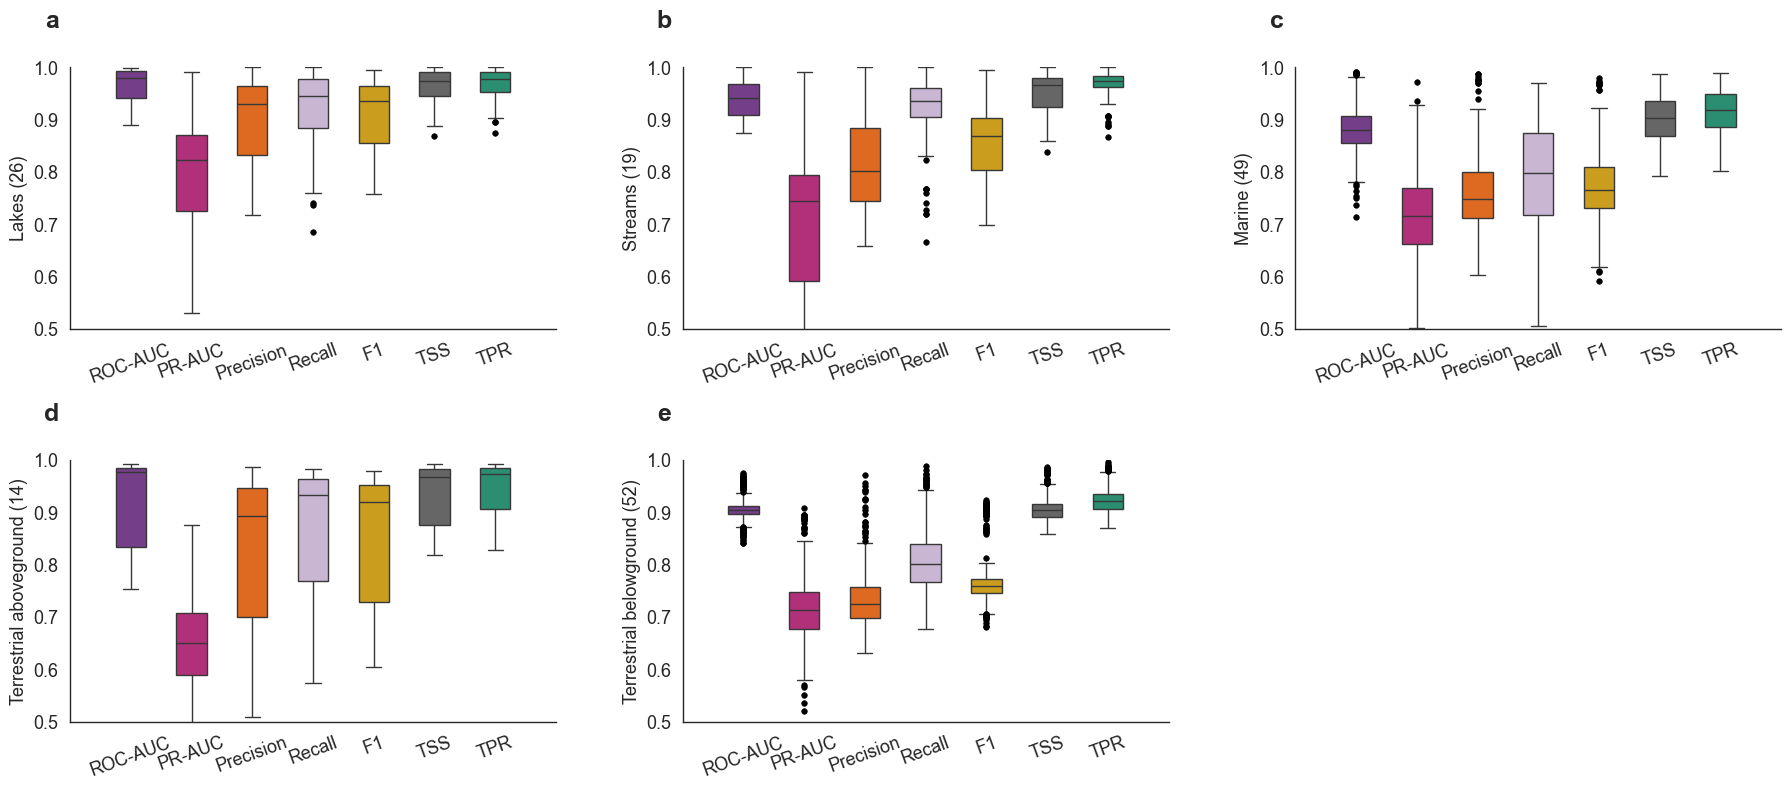

In [23]:
import os
import glob
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_context("paper")
sns.set_style("white")

# === Paths ===
results_dir = "../../../src/matlab/data/result_wlnm_dir_neg_pseudo_properties_k60_evaluate_unseen-false/prediction_scores_logs"
ecosystem_file = "../../../src/matlab/data/foodwebs_mat/foodweb_metrics_ecosystem.csv"

METRIC_ORDER = ["ROC_AUC", "PR_AUC", "Precision", "Recall", "F1Score", "PseudoTSS", "PseudoTPR"]
xtick_labels = ["ROC-AUC", "PR-AUC", "Precision", "Recall", "F1", "TSS", "TPR"]
MIN_NODES = 40
Y_PADDING = 0.02
Y_MIN_FLOOR = 0.5
Y_MAX_CAP = 1.0

metric_palette = {
    "ROC_AUC": "#7B3294",    # purple
    "PR_AUC": "#C51B7D",     # magenta
    "Precision": "#FE6100",  # orange
    "Recall": "#CAB2D6",     # violet
    "F1Score": "#E6AB02",    # mustard
    "PseudoTSS": "#666666",  # dark gray
    "PseudoTPR": "#1B9E77",  # teal-green
}

# === Load ecosystem metadata ===
df_ecosystem = pd.read_csv(ecosystem_file)

def normalize_colname(s: str) -> str:
    return (
        s.strip().lower()
        .replace(" ", "")
        .replace(".", "")
        .replace("-", "")
        .replace("_", "")
    )

# Detect node-count column robustly
node_candidates = {"n_nodes", "num_nodes", "nodes", "nodecount", "n", "s"}
norm_map = {normalize_colname(c): c for c in df_ecosystem.columns}
node_col = next((norm_map[k] for k in node_candidates if k in norm_map), None)

if node_col is None:
    raise RuntimeError(
        "Could not find a node-count column in ecosystem metadata. "
        "Please add one (e.g., 'S', 'nodes', 'num_species', 'node_count')."
    )

# === Load result CSVs and stack ===
csv_files = glob.glob(os.path.join(results_dir, "*_mass_results_random_wlnm_dir_neg.csv"))
dfs = []

for file in csv_files:
    df = pd.read_csv(file)
    df["Foodweb"] = os.path.basename(file).split("_results_")[0]
    dfs.append(df)

if not dfs:
    raise RuntimeError("No result CSV found. Check the path or pattern.")

df_all = pd.concat(dfs, ignore_index=True)

# === Merge metrics with ecosystem metadata ===
df_merged = pd.merge(
    df_all,
    df_ecosystem[["Foodweb", "EcosystemType", node_col]],
    on="Foodweb",
    how="left"
)

# === Apply node-count filter ===
before_n = df_merged["Foodweb"].nunique()
df_merged = df_merged[df_merged[node_col] >= MIN_NODES].copy()
after_n = df_merged["Foodweb"].nunique()

print(f"Filtered food webs by size: kept {after_n} / {before_n} (>= {MIN_NODES} nodes).")

# === Prepare long-format data ===
df_plot = df_merged.melt(
    id_vars=["Foodweb", "TrainRatio", "EcosystemType", "Iteration"],
    value_vars=METRIC_ORDER,
    var_name="Metric",
    value_name="Value"
)

df_plot["TrainRatio"] = df_plot["TrainRatio"].astype(str)

# === Preferred ecosystem order ===
preferred_ecosystem_order = [
    "lakes",
    "streams",
    "marine",
    "terrestrial aboveground",
    "terrestrial belowground",
]

ecosystems_present = (
    df_merged["EcosystemType"]
    .dropna()
    .astype(str)
    .str.strip()
    .drop_duplicates()
    .tolist()
)

eco_lookup = {eco.lower(): eco for eco in ecosystems_present}

ecosystem_order = [
    eco_lookup[eco]
    for eco in preferred_ecosystem_order
    if eco in eco_lookup
]

ecosystem_order += [
    eco for eco in ecosystems_present
    if eco.lower() not in set(preferred_ecosystem_order)
]

# === Panel labels ===
labels_map = (
    df_merged[["Foodweb", "EcosystemType"]]
    .drop_duplicates()
    .groupby("EcosystemType")["Foodweb"]
    .nunique()
    .to_dict()
)
labels_map = {eco: f"{str(eco).strip().capitalize()} ({n})" for eco, n in labels_map.items()}

# === Filter TrainRatio = 60 ===
subset = df_plot[pd.to_numeric(df_plot["TrainRatio"], errors="coerce") == 60.0].copy()
if subset.empty:
    raise RuntimeError("No rows for TrainRatio = 60.0. Check how TrainRatio is stored.")

subset["Metric"] = pd.Categorical(
    subset["Metric"],
    categories=METRIC_ORDER,
    ordered=True
)

# === Plot: fit panels into two rows ===
n_panels = len(ecosystem_order)
n_rows = 2
n_cols = math.ceil(n_panels / n_rows)

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(18, 8),
    sharey=False
)

axes = np.array(axes).reshape(-1)
panel_letters = list("abcdefghijklmnopqrstuvwxyz")

for i, eco in enumerate(ecosystem_order):
    ax = axes[i]
    sub = subset[subset["EcosystemType"] == eco].copy()

    if sub.empty:
        ax.set_axis_off()
        continue

    sns.boxplot(
        data=sub,
        x="Metric",
        y="Value",
        order=METRIC_ORDER,
        palette=metric_palette,
        # hue="Metric",
        legend=False,
        width=0.5,
        flierprops={
            "marker": "o",
            "markersize": 4,
            "markerfacecolor": "black",
            "markeredgecolor": "black",
            "markeredgewidth": 0.5,
            "linestyle": "none",
        },
        ax=ax,
    )

    leg = ax.get_legend()
    if leg is not None:
        leg.remove()

    ax.set_xlabel("")
    ax.set_xticks(range(len(METRIC_ORDER)))
    ax.set_xticklabels(xtick_labels, rotation=20, fontsize=13)

    ax.set_ylabel(labels_map.get(eco, eco), fontsize=13)
    ax.tick_params(axis="y", labelleft=True, labelsize=13)

    ax.set_xlim(-1, len(METRIC_ORDER) - 1 + 1)

    ax.set_ylim(0.5, 1.0)
    ax.set_yticks([0.5, 0.6, 0.7, 0.8, 0.9, 1.0])

    # ax.grid(True, axis="y", linestyle="--", alpha=0.35)
    ax.grid(False, axis="x")
    sns.despine(ax=ax)

    ax.annotate(
        panel_letters[i],
        xy=(0, 1.1),
        xycoords="axes fraction",
        xytext=(-8, 6),
        textcoords="offset points",
        ha="right",
        va="bottom",
        fontsize=18,
        fontweight="bold",
        annotation_clip=False,
    )

# Hide unused axes
for j in range(n_panels, len(axes)):
    axes[j].set_axis_off()

fig.tight_layout(rect=[0, 0, 1, 1], w_pad=5)
plt.show()

Filtered food webs by size: kept 160 / 290 (>= 40 nodes).


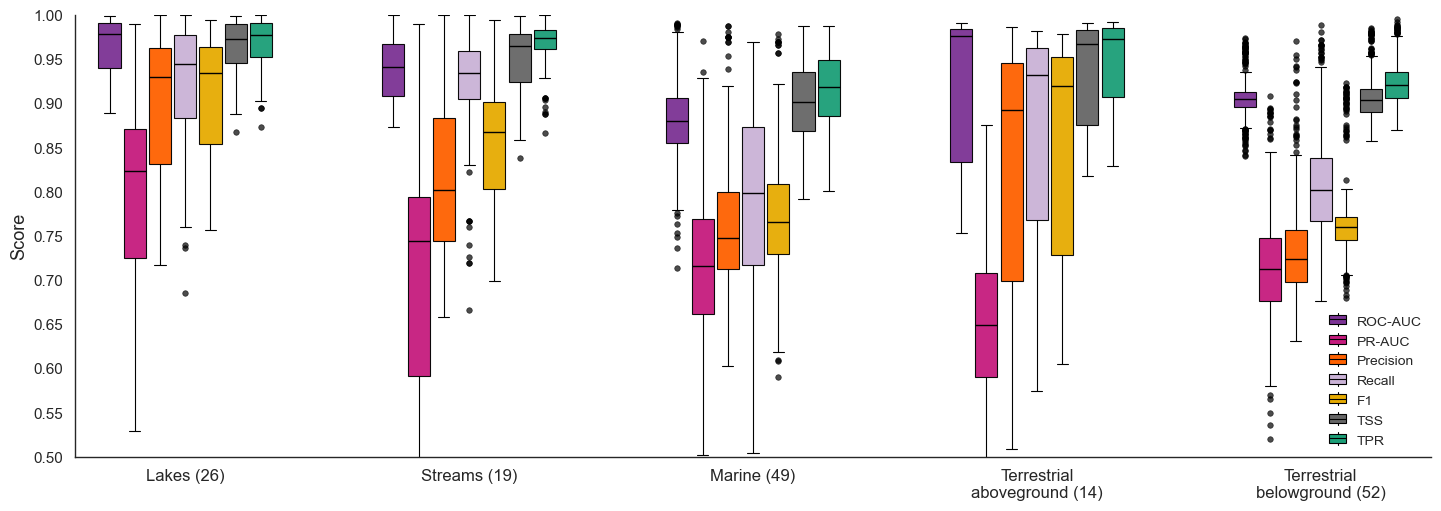

In [3]:
import os
import glob
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib.legend_handler import HandlerBase

sns.set_context("paper")
sns.set_style("white")

# === Paths ===
results_dir = "../../../src/matlab/data/result_wlnm_dir_neg_pseudo_properties_k60_evaluate_unseen-false/prediction_scores_logs"
ecosystem_file = "../../../src/matlab/data/foodwebs_mat/foodweb_metrics_ecosystem.csv"

METRIC_ORDER = ["ROC_AUC", "PR_AUC", "Precision", "Recall", "F1Score", "PseudoTSS", "PseudoTPR"]
xtick_labels = ["ROC-AUC", "PR-AUC", "Precision", "Recall", "F1", "TSS", "TPR"]

MIN_NODES = 40
Y_PADDING = 0.02
Y_MIN_FLOOR = 0.5
Y_MAX_CAP = 1.0

metric_palette = {
    "ROC_AUC": "#7B3294",    # purple
    "PR_AUC": "#C51B7D",     # magenta
    "Precision": "#FE6100",  # orange
    "Recall": "#CAB2D6",     # violet
    "F1Score": "#E6AB02",    # mustard
    "PseudoTSS": "#666666",  # dark gray
    "PseudoTPR": "#1B9E77",  # teal-green
}

# === Load ecosystem metadata ===
df_ecosystem = pd.read_csv(ecosystem_file)

def normalize_colname(s: str) -> str:
    return (
        s.strip().lower()
        .replace(" ", "")
        .replace(".", "")
        .replace("-", "")
        .replace("_", "")
    )

# Detect node-count column robustly
node_candidates = {"n_nodes", "num_nodes", "nodes", "nodecount", "n", "s"}
norm_map = {normalize_colname(c): c for c in df_ecosystem.columns}
node_col = next((norm_map[k] for k in node_candidates if k in norm_map), None)

if node_col is None:
    raise RuntimeError(
        "Could not find a node-count column in ecosystem metadata. "
        "Please add one (e.g., 'S', 'nodes', 'num_species', 'node_count')."
    )

# === Load result CSVs and stack ===
csv_files = glob.glob(os.path.join(results_dir, "*_mass_results_random_wlnm_dir_neg.csv"))
dfs = []

for file in csv_files:
    df = pd.read_csv(file)
    df["Foodweb"] = os.path.basename(file).split("_results_")[0]
    dfs.append(df)

if not dfs:
    raise RuntimeError("No result CSV found. Check the path or pattern.")

df_all = pd.concat(dfs, ignore_index=True)

# === Merge metrics with ecosystem metadata ===
df_merged = pd.merge(
    df_all,
    df_ecosystem[["Foodweb", "EcosystemType", node_col]],
    on="Foodweb",
    how="left"
)

# === Apply node-count filter ===
before_n = df_merged["Foodweb"].nunique()
df_merged = df_merged[df_merged[node_col] >= MIN_NODES].copy()
after_n = df_merged["Foodweb"].nunique()

print(f"Filtered food webs by size: kept {after_n} / {before_n} (>= {MIN_NODES} nodes).")

# === Prepare long-format data ===
df_plot = df_merged.melt(
    id_vars=["Foodweb", "TrainRatio", "EcosystemType", "Iteration"],
    value_vars=METRIC_ORDER,
    var_name="Metric",
    value_name="Value"
)

df_plot["TrainRatio"] = df_plot["TrainRatio"].astype(str)

# === Preferred ecosystem order ===
preferred_ecosystem_order = [
    "lakes",
    "streams",
    "marine",
    "terrestrial aboveground",
    "terrestrial belowground",
]

ecosystems_present = (
    df_merged["EcosystemType"]
    .dropna()
    .astype(str)
    .str.strip()
    .drop_duplicates()
    .tolist()
)

eco_lookup = {eco.lower(): eco for eco in ecosystems_present}

ecosystem_order = [
    eco_lookup[eco]
    for eco in preferred_ecosystem_order
    if eco in eco_lookup
]

ecosystem_order += [
    eco for eco in ecosystems_present
    if eco.lower() not in set(preferred_ecosystem_order)
]

# === Panel labels ===
labels_map = (
    df_merged[["Foodweb", "EcosystemType"]]
    .drop_duplicates()
    .groupby("EcosystemType")["Foodweb"]
    .nunique()
    .to_dict()
)

def format_ecosystem_label(eco: str, n: int) -> str:
    eco_clean = str(eco).strip().lower()

    custom_labels = {
        "terrestrial aboveground": "Terrestrial\naboveground",
        "terrestrial belowground": "Terrestrial\nbelowground",
        "lakes": "Lakes",
        "streams": "Streams",
        "marine": "Marine",
    }

    label = custom_labels.get(eco_clean, str(eco).strip().capitalize())
    return f"{label} ({n})"

labels_map = {eco: format_ecosystem_label(eco, n) for eco, n in labels_map.items()}

# === Filter TrainRatio = 60 ===
subset = df_plot[pd.to_numeric(df_plot["TrainRatio"], errors="coerce") == 60.0].copy()
if subset.empty:
    raise RuntimeError("No rows for TrainRatio = 60.0. Check how TrainRatio is stored.")

subset["Metric"] = pd.Categorical(
    subset["Metric"],
    categories=METRIC_ORDER,
    ordered=True
)

class HandlerMiniBoxplot(HandlerBase):
    def create_artists(
        self, legend, orig_handle,
        xdescent, ydescent, width, height, fontsize, trans
    ):
        facecolor = orig_handle["facecolor"]
        edgecolor = orig_handle.get("edgecolor", "black")
        linewidth = orig_handle.get("linewidth", 0.6)

        y_shift = -0.06 * height

        cx = xdescent + 0.5 * width
        cy = ydescent + 0.5 * height + y_shift

        box_w = 0.8 * width
        box_h = 0.8 * height
        box_x = cx - box_w / 2
        box_y = cy - box_h / 2

        whisk_top_y = box_y + box_h + 0.18 * height
        whisk_bot_y = box_y - 0.18 * height

        box = Rectangle(
            (box_x, box_y),
            box_w,
            box_h,
            facecolor=facecolor,
            edgecolor=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        median = Line2D(
            [box_x, box_x + box_w],
            [cy, cy],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        whisker_top = Line2D(
            [cx, cx],
            [box_y + box_h, whisk_top_y],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        whisker_bottom = Line2D(
            [cx, cx],
            [whisk_bot_y, box_y],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        return [box, median, whisker_top, whisker_bottom]
# === Plot: single-panel boxplots grouped by ecosystem ===
plot_ecosystems = ecosystem_order
metric_order = METRIC_ORDER

fig, ax = plt.subplots(figsize=(14.5, 5.2))

# Base x positions for ecosystem groups
group_gap = 1.8
group_centers = 1.0 + np.arange(len(plot_ecosystems)) * group_gap

# Small offsets so metrics within the same ecosystem stay close together
offsets = np.linspace(-0.48, 0.48, len(metric_order))
box_width = 0.14

for j, metric in enumerate(metric_order):
    data_for_metric = []
    positions_for_metric = []

    for i, eco in enumerate(plot_ecosystems):
        vals = (
            subset.loc[
                (subset["EcosystemType"] == eco) & (subset["Metric"] == metric),
                "Value"
            ]
            .dropna()
            .values
        )

        if len(vals) == 0:
            continue

        data_for_metric.append(vals)
        positions_for_metric.append(group_centers[i] + offsets[j])

    ax.boxplot(
        data_for_metric,
        positions=positions_for_metric,
        widths=box_width,
        patch_artist=True,
        manage_ticks=False,
        showfliers=True,
        boxprops=dict(
            facecolor=metric_palette[metric],
            edgecolor="black",
            linewidth=0.8,
            alpha=0.95,
        ),
        medianprops=dict(color="black", linewidth=1.0),
        whiskerprops=dict(color="black", linewidth=0.8),
        capprops=dict(color="black", linewidth=0.8),
        flierprops=dict(
            marker="o",
            markersize=4,
            markerfacecolor="black",
            markeredgecolor="black",
            markeredgewidth=0.5,
            alpha=0.7,
        ),
    )

legend_handles = [
    {
        "facecolor": metric_palette[m],
        "edgecolor": "black",
        "linewidth": 0.8,
    }
    for m in metric_order
]

legend_labels = {
    "ROC_AUC": "ROC-AUC",
    "PR_AUC": "PR-AUC",
    "Precision": "Precision",
    "Recall": "Recall",
    "F1Score": "F1",
    "PseudoTSS": "TSS",
    "PseudoTPR": "TPR",
}

ax.set_xlim(group_centers[0] - 0.7, group_centers[-1] + 0.7)
ax.set_ylim(0.5, 1.0)
ax.set_yticks([0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0])

ax.set_xticks(group_centers)
ax.set_xticklabels(
    [labels_map.get(eco, str(eco).strip().capitalize()) for eco in plot_ecosystems],
    rotation=0,
    fontsize=12,
)

ax.set_ylabel("Score", fontsize=13)
ax.set_xlabel("")

ax.tick_params(axis="y", labelsize=11)
# ax.grid(True, axis="y", linestyle="--", alpha=0.35)
ax.grid(False, axis="x")

ax.legend(
    handles=legend_handles,
    labels=[legend_labels[m] for m in metric_order],
    handler_map={dict: HandlerMiniBoxplot()},
    loc="lower right",
    frameon=False,
    fontsize=10,
    handlelength=1.5,
    handleheight=0.9,
    handletextpad=0.6,
    borderpad=0.2,
    labelspacing=0.45,
)

sns.despine(ax=ax)
plt.tight_layout()
plt.show()

Filtered foodweb list by size: kept 160 / 290 (>= 40 nodes).

Processing: Grand Caricaie  marsh dominated by Cladietum marisci, not mown  ClControl2

Species key for Grand Caricaie  marsh dominated by Cladietum marisci, not mown  ClControl2_tax_mass (pretty):
 Number                  Species       Mass_mg
      1             Sminthuridae        0.0295
      2             Poduromorpha        0.0295
      3              Acari phyto        0.0345
      4               Acari pred        0.0345
      5                Araneidae        0.0345
      6                Hahnia sp        0.0345
      7            Cecidomyiidae        0.0532
      8             Theridion sp        0.0964
      9        Ootetrastichus sp        0.2126
     10         Stilicus rufipes        0.2454
     11               Cicadoidea        0.2590
     12           Tetragnatha sp        0.3455
     13         Mangora acalypha        0.3455
     14              Delphacidae        0.3787
     15        Cercyon sternalis   

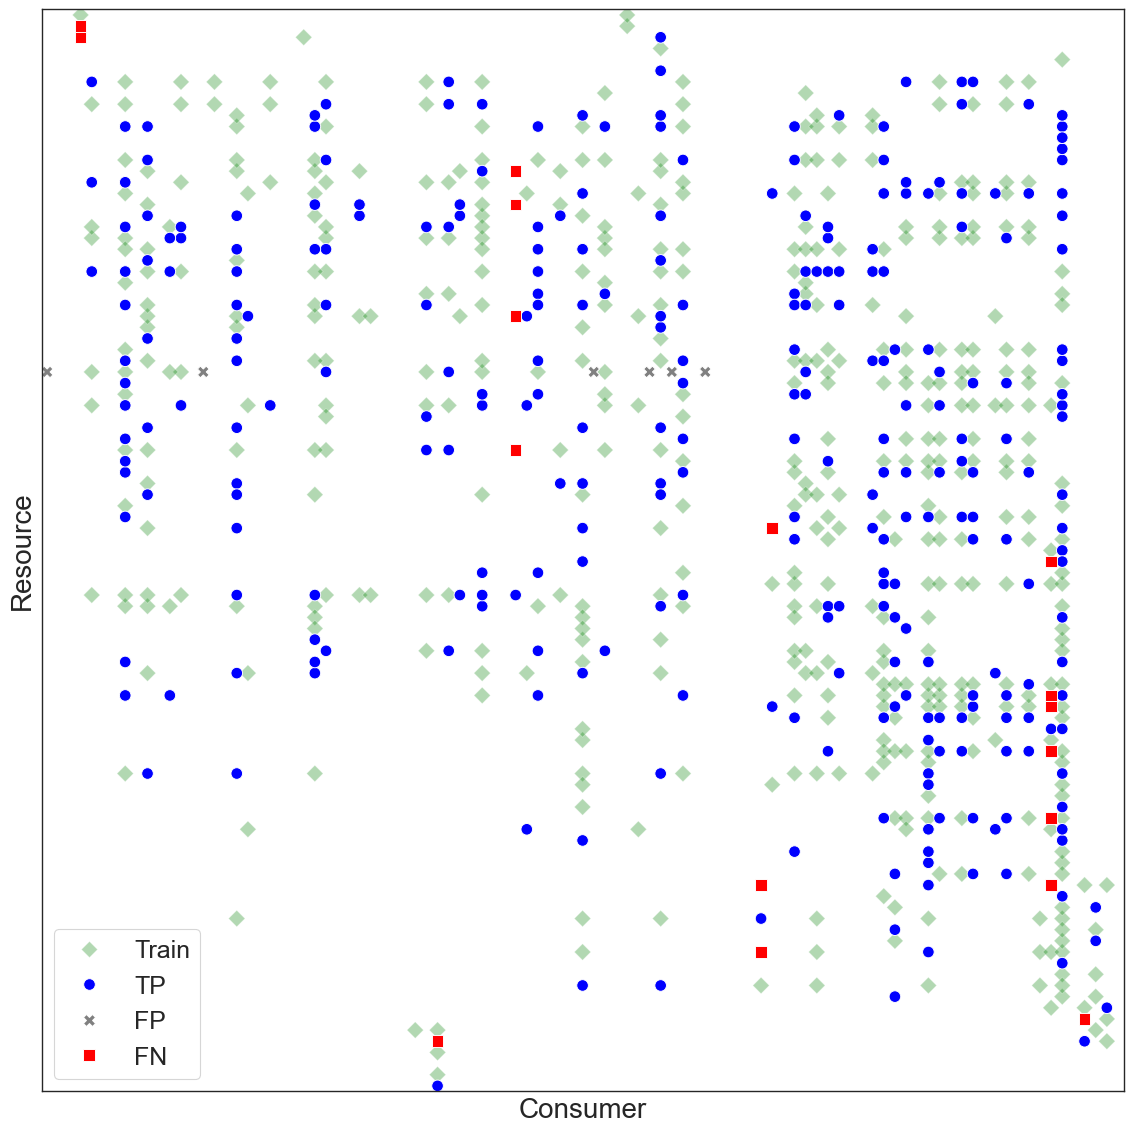

In [4]:
import os
import re
import scipy.io
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.sparse import coo_matrix, csr_matrix

# Apply seaborn style
sns.set_theme(context="paper", style="white", font_scale=3)

# =========================
# Figure controls (flags)
# =========================
MIN_NODES = 40

SHOW_TITLES = False
SHOW_TICKS = False

XLAB = "Consumer"
YLAB = "Resource"

PANEL_XTICK_FONTSIZES = [12]   # single panel
PANEL_YTICK_FONTSIZES = [12]   # single panel

# =========================
# Numeric axis labels + species key printing
# =========================
USE_NUMERIC_AXIS_LABELS = False
PRINT_SPECIES_KEY = False
EXPORT_SPECIES_KEY_FILE = False
SPECIES_KEY_DIR = "./species_keys"
SPECIES_KEY_FORMAT = "csv"

# =========================
# Plot one specific foodweb
# =========================
TARGET_FOODWEB_1 = "Grand Caricaie  marsh dominated by Cladietum marisci, not mown  ClControl2"
PANEL_LETTERS = ["a"]

# === Load foodweb names list ===
foodwebs_list_df = pd.read_csv("../../../src/matlab/data/foodwebs_mat/foodweb_metrics_ecosystem.csv")

# === Filter to foodwebs with nodes >= MIN_NODES ===
def normalize_colname(s: str) -> str:
    return (
        s.strip().lower()
        .replace(" ", "")
        .replace(".", "")
        .replace("-", "")
        .replace("_", "")
    )

node_candidates = {
    "n_nodes", "num_nodes", "nodes", "nodecount", "n", "s",
    "species", "numspecies", "numberofspecies", "speciescount"
}

norm_map = {normalize_colname(c): c for c in foodwebs_list_df.columns}
node_col = next((norm_map[k] for k in node_candidates if k in norm_map), None)

if node_col is None:
    raise RuntimeError(
        "Could not find a node-count column in foodweb_metrics_ecosystem.csv. "
        "Please add one such as 'Nodes' or 'S'."
    )

before_n = len(foodwebs_list_df)
foodwebs_list_df = foodwebs_list_df[foodwebs_list_df[node_col] >= MIN_NODES].copy()
after_n = len(foodwebs_list_df)

print(f"Filtered foodweb list by size: kept {after_n} / {before_n} (>= {MIN_NODES} nodes).")

# === Base paths ===
base_csv_path = "../../../src/matlab/data/result_wlnm_dir_neg_pseudo_properties_k60_evaluate_unseen-false/confusion_matrix_csv"
base_mat_path = "../../../src/matlab/data/foodwebs_mat"

# =========================
# Choose which foodweb to iterate
# =========================
all_foodwebs = foodwebs_list_df["Foodweb"].astype(str).tolist()

def resolve_foodweb(target_name, all_names):
    exact = [fw for fw in all_names if fw == target_name]
    if exact:
        return exact[0]

    prefix_matches = [fw for fw in all_names if fw.split("_")[0] == target_name]
    if prefix_matches:
        return prefix_matches[0]

    raise ValueError(
        f"TARGET_FOODWEB='{target_name}' not found in filtered foodweb list. "
        f"Example valid values: {all_names[:5]}"
    )

foodweb_iter = [
    resolve_foodweb(TARGET_FOODWEB_1, all_foodwebs),
]

# =========================
# Build one 1x1 figure
# =========================
fig, ax = plt.subplots(1, 1, figsize=(12, 12))
axs = [ax]

global_species_offset = 0

# === Iterate over the selected foodweb ===
for panel_idx, foodweb in enumerate(foodweb_iter):
    ax = axs[panel_idx]

    print(f"\nProcessing: {foodweb.split('_')[0]}")

    try:
        # === Load CSV prediction results ===
        tp_file = os.path.join(base_csv_path, f"{foodweb}_K_10_random_ratio60_TP_links.csv")
        fp_file = os.path.join(base_csv_path, f"{foodweb}_K_10_random_ratio60_FP_links.csv")
        fn_file = os.path.join(base_csv_path, f"{foodweb}_K_10_random_ratio60_FN_links.csv")
        train_file = os.path.join(base_csv_path, f"{foodweb}_K_10_random_ratio60_train_links.csv")
        mat_file = os.path.join(base_mat_path, f"{foodweb}.mat")

        tp = pd.read_csv(tp_file).dropna(subset=["Prey", "Predator"])
        fp = pd.read_csv(fp_file).dropna(subset=["Prey", "Predator"])
        fn = pd.read_csv(fn_file).dropna(subset=["Prey", "Predator"])

        # === Load .mat adjacency and metadata ===
        mat_data = scipy.io.loadmat(mat_file)
        net = mat_data["net"]
        taxonomy = [
            str(t[0]) if isinstance(t, (list, np.ndarray)) else str(t)
            for t in mat_data["taxonomy"].flatten()
        ]
        mass = mat_data["mass"].flatten().astype(float)
        mass = np.round(mass * 1000.0, 4)

        # === Sort species by mass ===
        taxonomy_df = pd.DataFrame({"Species": taxonomy, "Mass": mass})
        taxonomy_df = taxonomy_df.dropna().sort_values(by="Mass").reset_index(drop=True)
        sorted_species = taxonomy_df["Species"].tolist()
        species_index = {name: i for i, name in enumerate(sorted_species)}
        N = len(sorted_species)
        sorted_species_reversed = sorted_species[::-1]

        # Number each species globally (continued across panels)
        start_num = global_species_offset + 1
        species_to_num = {sp: start_num + i for i, sp in enumerate(sorted_species)}
        num_to_species = {start_num + i: sp for i, sp in enumerate(sorted_species)}

        if PRINT_SPECIES_KEY:
            key_df = taxonomy_df.copy()
            key_df["Number"] = np.arange(start_num, start_num + len(key_df))
            key_df = key_df[["Number", "Species", "Mass"]].rename(columns={"Mass": "Mass_mg"})
            key_df["Mass_mg"] = key_df["Mass_mg"].map(lambda x: f"{x:.4f}")

            print(f"\nSpecies key for {foodweb} (pretty):")
            print(key_df.to_string(index=False))

            if EXPORT_SPECIES_KEY_FILE:
                out_dir = Path(SPECIES_KEY_DIR)
                out_dir.mkdir(parents=True, exist_ok=True)

                safe_fw = re.sub(r"[^A-Za-z0-9._-]+", "_", str(foodweb)).strip("_")
                ext = "tsv" if SPECIES_KEY_FORMAT.lower() == "tsv" else "csv"
                out_path = out_dir / f"{safe_fw}_species_key.{ext}"

                sep = "\t" if ext == "tsv" else ","
                key_df.to_csv(out_path, sep=sep, index=False, encoding="utf-8")

                print(f"\nSaved species key file to: {out_path.resolve()}")

        # Keep matrix conversion logic intact in case net format varies
        if isinstance(net, coo_matrix):
            net = net.tocsr()
        elif isinstance(net, (np.ndarray, list)):
            net = csr_matrix(net)

        idx_sorted = [taxonomy.index(sp) for sp in sorted_species]
        adj_sorted = net[np.ix_(idx_sorted, idx_sorted)].toarray().astype(float)

        # === Filter predictions to valid species ===
        tp = tp[tp["Prey"].isin(species_index) & tp["Predator"].isin(species_index)]
        fp = fp[fp["Prey"].isin(species_index) & fp["Predator"].isin(species_index)]
        fn = fn[fn["Prey"].isin(species_index) & fn["Predator"].isin(species_index)]

        # === Build DataFrame for Predation Matrix
        def make_df(df, label):
            return pd.DataFrame({
                "PreyIdx": df["Prey"].map(species_index),
                "PredIdx": df["Predator"].map(species_index),
                "Label": label
            })

        df_pm = pd.concat([
            make_df(tp, "TP"),
            make_df(fp, "FP"),
            make_df(fn, "FN")
        ]).dropna().astype({"PreyIdx": int, "PredIdx": int})
        df_pm["PreyIdx"] = N - 1 - df_pm["PreyIdx"]

        # === Load Training Links (if available)
        df_train = None
        if os.path.isfile(train_file):
            train = pd.read_csv(train_file).dropna(subset=["Prey", "Predator"])
            train = train[train["Prey"].isin(species_index) & train["Predator"].isin(species_index)]
            df_train = pd.DataFrame({
                "PreyIdx": train["Prey"].map(species_index),
                "PredIdx": train["Predator"].map(species_index),
                "Label": "Train"
            })
            df_train["PreyIdx"] = N - 1 - df_train["PreyIdx"]

        # === Panel label
        # ax.text(
        #     -0.05, 1.05, PANEL_LETTERS[panel_idx],
        #     transform=ax.transAxes,
        #     fontsize=40,
        #     fontweight="bold",
        #     va="top",
        #     ha="left",
        #     clip_on=False
        # )

        # === Plot training links first (background)
        if df_train is not None:
            sns.scatterplot(
                data=df_train,
                x="PredIdx",
                y="PreyIdx",
                hue="Label",
                style="Label",
                markers={"Train": "D"},
                palette={"Train": "green"},
                alpha=0.3,
                s=70,
                legend="brief",
                ax=ax
            )

        # === Plot TP, FP, FN
        sns.scatterplot(
            data=df_pm,
            x="PredIdx",
            y="PreyIdx",
            hue="Label",
            style="Label",
            markers={"TP": "o", "FP": "X", "FN": "s", "Train": "D"},
            palette={"TP": "blue", "FP": "gray", "FN": "red", "Train": "green"},
            s=70,
            ax=ax
        )

        # =========================
        # Professional axis styling
        # =========================
        ax.invert_yaxis()
        ax.set_xlim(-0.5, N - 0.5)
        ax.set_ylim(-0.5, N - 0.5)
        ax.set_aspect("equal", adjustable="box")

        ax.set_xlabel(XLAB, fontsize=20)
        ax.set_ylabel(YLAB, fontsize=20)

        if SHOW_TICKS:
            ax.set_xticks(range(N))
            ax.set_yticks(range(N))

            x_tick_fs = PANEL_XTICK_FONTSIZES[panel_idx]
            y_tick_fs = PANEL_YTICK_FONTSIZES[panel_idx]

            if USE_NUMERIC_AXIS_LABELS:
                x_labels = [str(species_to_num[sp]) for sp in sorted_species]
                y_labels = [str(species_to_num[sp]) for sp in sorted_species_reversed]

                ax.set_xticklabels(x_labels, rotation=90, fontsize=x_tick_fs)
                ax.set_yticklabels(y_labels, fontsize=y_tick_fs)
            else:
                ax.set_xticklabels(sorted_species, rotation=90, fontsize=x_tick_fs)
                ax.set_yticklabels(sorted_species_reversed, fontsize=y_tick_fs)

            ax.tick_params(axis="both", which="both", length=3)
        else:
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_xticklabels([])
            ax.set_yticklabels([])
            ax.tick_params(axis="both", which="both", length=0)

        if SHOW_TITLES:
            ax.set_title(foodweb, fontsize=12)

        ax.legend(loc="lower left", prop={"size": 18}, title="")

        # Update numbering offset so the next panel continues
        global_species_offset += N

    except Exception as e:
        print(f"Skipping {foodweb} due to error: {e}")
        ax.set_axis_off()

plt.tight_layout()
plt.show()

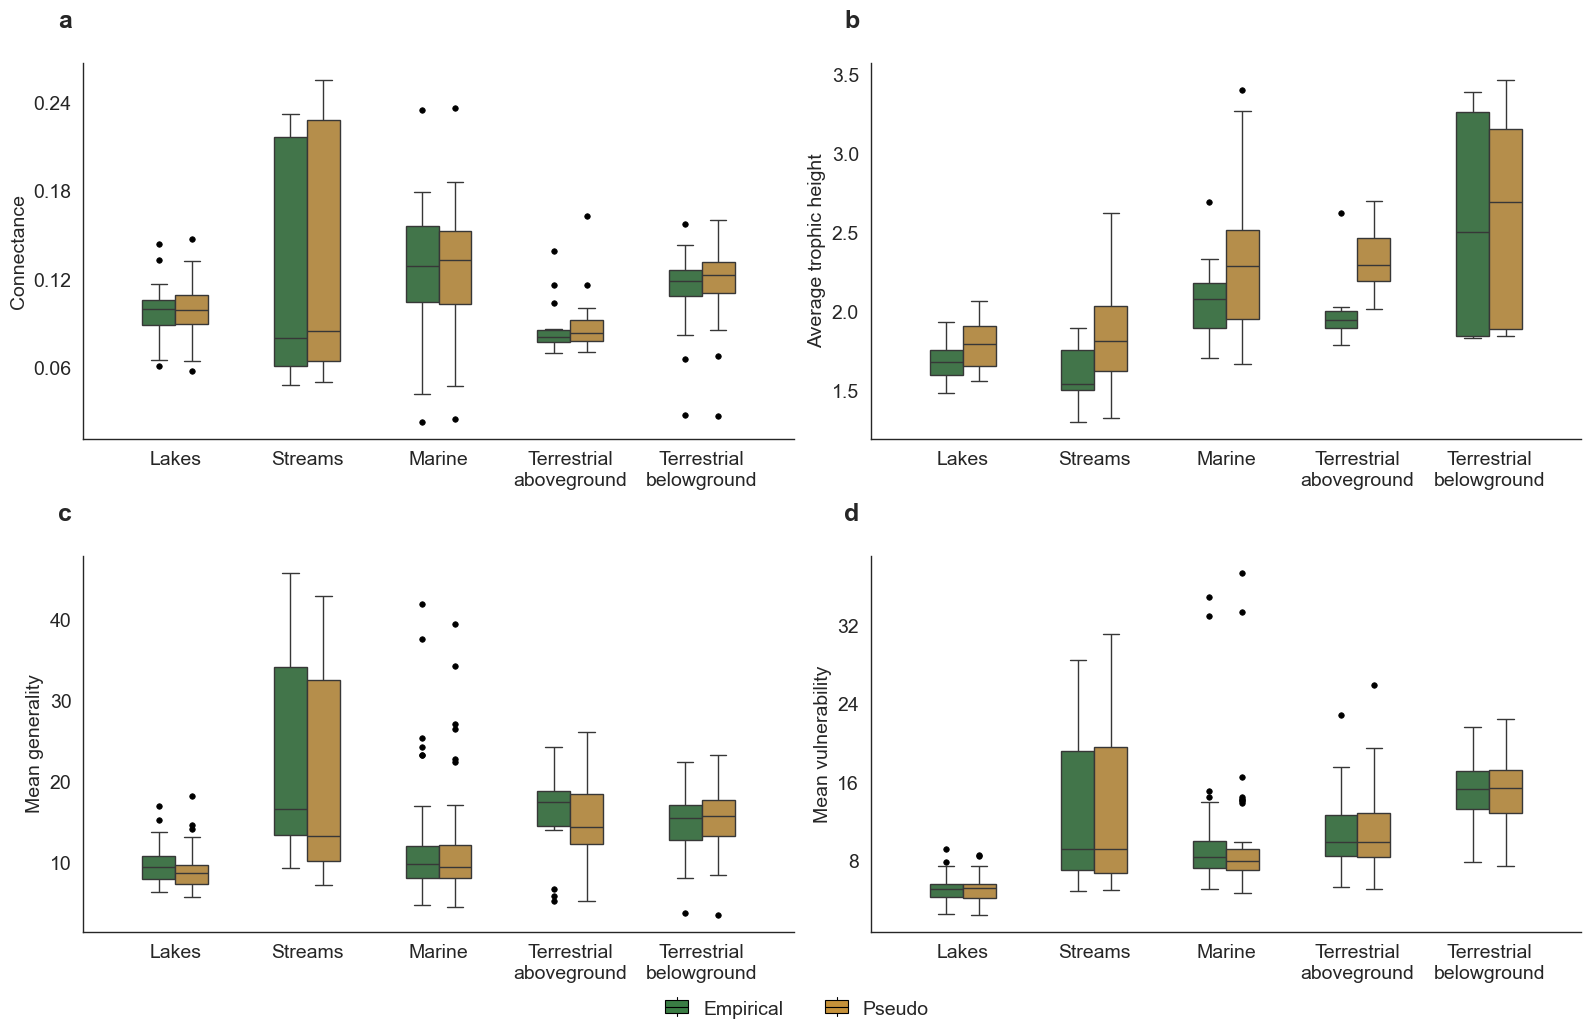

In [13]:
import glob
import math
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib.legend_handler import HandlerBase

sns.set_theme(context="paper", style="white")

# ============================================================
# CONFIG
# ============================================================
RESULTS_DIR = Path("../../../src/matlab/data/result_wlnm_dir_neg_pseudo_properties_k60_evaluate_unseen-false/prediction_scores_logs")
ECOSYSTEM_CSV = Path("../../../src/matlab/data/foodwebs_mat/foodweb_metrics_ecosystem.csv")

NODES_THRESHOLD = 40
AGGREGATE_PER_FOODWEB = True
TROPHIC_LEVEL_MIN = 1.0
TROPHIC_LEVEL_MAX = 4.0
LINKS_Q_LOW = 0.00
LINKS_Q_HIGH = 0.98

base_ecosystem_order = [
    "lakes",
    "streams",
    "marine",
    "terrestrial aboveground",
    "terrestrial belowground",
]

ecosystem_labels = {
    "lakes": "Lakes",
    "streams": "Streams",
    "marine": "Marine",
    "terrestrial aboveground": "Terrestrial\naboveground",
    "terrestrial belowground": "Terrestrial\nbelowground",
}

def format_ecosystem_label(eco: str) -> str:
    eco_clean = str(eco).strip().lower()
    return ecosystem_labels.get(eco_clean, str(eco).strip().capitalize())

panel_letters = list("abcdefghijklmnopqrstuvwxyz")

paired_specs = [
    ("EmpiricalConnectance",       "PseudoConnectance",       "Connectance"),
    ("EmpiricalMeanTrophicLevel",  "PseudoMeanTrophicLevel",  "Average trophic height"),
    ("EmpiricalMeanGenerality",    "PseudoMeanGenerality",    "Mean generality"),
    ("EmpiricalMeanVulnerability", "PseudoMeanVulnerability", "Mean vulnerability"),
]

type_palette = {
    "Empirical": "#3A7D44",
    "Pseudo": "#C6923A",
}

type_offset = {
    "Empirical": -0.41,
    "Pseudo": 0.41,
}

# ============================================================
# HELPERS
# ============================================================
def extract_foodweb_name(filepath: str) -> str:
    return Path(filepath).name.split("_results_")[0]

def find_col(df: pd.DataFrame, candidates):
    lower_map = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand.lower() in lower_map:
            return lower_map[cand.lower()]
    raise KeyError(f"Could not find any of these columns: {candidates}")

def normalize_fw_label(name: str) -> str:
    name = str(name).strip()
    name = Path(name).stem
    name = name.replace(" ", "_")
    for token in [
        "_results_", "_result_", "_results",
        "_random", "_tax_mass", "_tax", "_mass"
    ]:
        name = name.replace(token, "_")
    return "_".join(part for part in name.split("_") if part)

def load_all_results(results_dir: Path) -> pd.DataFrame:
    files = sorted(glob.glob(str(results_dir / "*_results_*.csv")))
    if not files:
        raise FileNotFoundError(f"No results CSVs found in: {results_dir}")

    dfs = []
    for fp in files:
        try:
            df = pd.read_csv(fp)
            df["Foodweb"] = extract_foodweb_name(fp)
            dfs.append(df)
        except Exception as e:
            print(f"[WARN] Skipping {fp}: {e}")

    if not dfs:
        raise RuntimeError("No readable result CSVs were loaded.")

    return pd.concat(dfs, ignore_index=True)

def load_ecosystem_metadata(ecosystem_csv: Path) -> pd.DataFrame:
    meta = pd.read_csv(ecosystem_csv)

    foodweb_col = find_col(meta, ["Foodweb", "foodweb"])
    eco_col = find_col(meta, ["Ecosystem", "ecosystem", "EcosystemType", "ecosystem_type"])
    nodes_col = find_col(meta, ["Nodes", "nodes"])

    meta = meta.rename(columns={
        foodweb_col: "Foodweb",
        eco_col: "Ecosystem",
        nodes_col: "Nodes"
    })

    meta["Foodweb"] = meta["Foodweb"].astype(str)
    meta["Ecosystem"] = meta["Ecosystem"].astype(str)
    meta["Nodes"] = pd.to_numeric(meta["Nodes"], errors="coerce")
    meta["FW_KEY"] = meta["Foodweb"].apply(normalize_fw_label)

    return meta[["Foodweb", "Ecosystem", "Nodes", "FW_KEY"]].drop_duplicates()

def safe_numeric_filter(df: pd.DataFrame) -> pd.DataFrame:
    for c in ["K", "TrainRatio"]:
        if c in df.columns:
            df = df[pd.notna(df[c])]
    return df

def aggregate_foodweb_runs(df: pd.DataFrame) -> pd.DataFrame:
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    grouped = df.groupby("Foodweb", as_index=False)[numeric_cols].mean()

    eco_map = df[["Foodweb", "Ecosystem"]].drop_duplicates()
    grouped = grouped.merge(eco_map, on="Foodweb", how="left")

    cols = ["Foodweb", "Ecosystem"] + [c for c in grouped.columns if c not in ("Foodweb", "Ecosystem")]
    return grouped[cols]

# ============================================================
# LOAD + PREPARE DATA
# ============================================================
results = load_all_results(RESULTS_DIR)
meta = load_ecosystem_metadata(ECOSYSTEM_CSV)

results = safe_numeric_filter(results)
results["FW_KEY"] = results["Foodweb"].apply(normalize_fw_label)

allowed_fw_keys = set(meta.loc[meta["Nodes"] >= NODES_THRESHOLD, "FW_KEY"].dropna().unique())
results = results[results["FW_KEY"].isin(allowed_fw_keys)].copy()

if results.empty:
    raise ValueError(f"No foodwebs left after filtering Nodes >= {NODES_THRESHOLD}.")

required_plot_cols = sorted(
    {"Ecosystem"} | {c for spec in paired_specs for c in spec[:2]}
)
existing_required = [c for c in required_plot_cols if c in results.columns]
results = results.dropna(subset=existing_required)

results = results.merge(
    meta[["FW_KEY", "Ecosystem"]].drop_duplicates(),
    on="FW_KEY",
    how="left",
    suffixes=("", "_meta")
)

if "Ecosystem_meta" in results.columns:
    results["Ecosystem"] = results["Ecosystem"].fillna(results["Ecosystem_meta"])
    results = results.drop(columns=["Ecosystem_meta"])

plot_df = aggregate_foodweb_runs(results) if AGGREGATE_PER_FOODWEB else results.copy()

class HandlerMiniBoxplot(HandlerBase):
    def create_artists(
        self, legend, orig_handle,
        xdescent, ydescent, width, height, fontsize, trans
    ):
        facecolor = orig_handle["facecolor"]
        edgecolor = orig_handle.get("edgecolor", "black")
        linewidth = orig_handle.get("linewidth", 0.6)

        y_shift = -0.06 * height

        cx = xdescent + 0.5 * width
        cy = ydescent + 0.5 * height + y_shift

        box_w = 0.8 * width
        box_h = 0.8 * height
        box_x = cx - box_w / 2
        box_y = cy - box_h / 2

        whisk_top_y = box_y + box_h + 0.18 * height
        whisk_bot_y = box_y - 0.18 * height

        box = Rectangle(
            (box_x, box_y),
            box_w,
            box_h,
            facecolor=facecolor,
            edgecolor=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        median = Line2D(
            [box_x, box_x + box_w],
            [cy, cy],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        whisker_top = Line2D(
            [cx, cx],
            [box_y + box_h, whisk_top_y],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        whisker_bottom = Line2D(
            [cx, cx],
            [whisk_bot_y, box_y],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        return [box, median, whisker_top, whisker_bottom]

# ============================================================
# PLOT
# ============================================================
n_panels = len(paired_specs)
n_cols = 2
n_rows = math.ceil(n_panels / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 10), sharey=False)
axes = np.array(axes).reshape(-1)

legend_handles = [
    {"facecolor": type_palette["Empirical"], "edgecolor": "black", "linewidth": 0.8},
    {"facecolor": type_palette["Pseudo"], "edgecolor": "black", "linewidth": 0.8},
]
legend_labels = ["Empirical", "Pseudo"]

for idx, (ax, (emp_col, pseudo_col, title)) in enumerate(zip(axes, paired_specs)):
    panel_df = plot_df.dropna(subset=[emp_col, pseudo_col, "Ecosystem"]).copy()

    if panel_df.empty:
        ax.set_visible(False)
        continue

    # Keep the trophic-level filter if needed
    if title == "Average trophic height":
        panel_df = panel_df[
            np.isfinite(panel_df[emp_col]) &
            np.isfinite(panel_df[pseudo_col]) &
            panel_df[emp_col].between(TROPHIC_LEVEL_MIN, TROPHIC_LEVEL_MAX) &
            panel_df[pseudo_col].between(TROPHIC_LEVEL_MIN, TROPHIC_LEVEL_MAX)
        ].copy()

    if panel_df.empty:
        ax.set_visible(False)
        continue

    present_ecosystems = [eco for eco in base_ecosystem_order if eco in panel_df["Ecosystem"].unique()]
    extra_ecosystems = [eco for eco in panel_df["Ecosystem"].unique() if eco not in base_ecosystem_order]
    eco_order = present_ecosystems + extra_ecosystems

    long_df = panel_df.melt(
        id_vars=["Ecosystem"],
        value_vars=[emp_col, pseudo_col],
        var_name="NetworkType",
        value_name="Value",
    )

    long_df["NetworkType"] = long_df["NetworkType"].map({
        emp_col: "Empirical",
        pseudo_col: "Pseudo",
    })

    sns.boxplot(
        data=long_df,
        x="Ecosystem",
        y="Value",
        hue="NetworkType",
        order=eco_order,
        hue_order=["Empirical", "Pseudo"],
        palette=type_palette,
        ax=ax,
        width=0.5,
        dodge=True,
        flierprops={
            "marker": "o",
            "markersize": 4,
            "markerfacecolor": "black",
            "markeredgecolor": "black",
            "markeredgewidth": 0.5,
            "linestyle": "none",
        },
    )

    if ax.get_legend() is not None:
        ax.get_legend().remove()

    ax.set_title("")
    ax.set_ylabel(title, fontsize=14)
    ax.set_xlabel("")
    ax.tick_params(axis="both", labelsize=14)

    ax.set_xlim(-0.7, len(eco_order) - 1 + 0.7)

    # Independent y-axis zoom per panel
    panel_vals = long_df["Value"].dropna().values
    if panel_vals.size:
        local_min = np.nanmin(panel_vals)
        local_max = np.nanmax(panel_vals)
        pad = 0.05 * (local_max - local_min) if local_max > local_min else 0.05

        # Only force non-negative lower bound; do NOT cap upper bound at 1.0
        local_min = max(0.0, local_min - pad)
        local_max = local_max + pad

        if np.isclose(local_min, local_max):
            local_min = max(0.0, local_min - 0.02)
            local_max = local_max + 0.02

        ax.set_ylim(local_min, local_max)
        ax.yaxis.set_major_locator(plt.MaxNLocator(5))

    ax.set_xticks(range(len(eco_order)))
    ax.set_xticklabels(
        [format_ecosystem_label(eco) for eco in eco_order],
        rotation=0,
        fontsize=14,
    )

    ax.grid(False, axis="x")
    ax.grid(False, axis="y")
    sns.despine(ax=ax)

    ax.annotate(
        panel_letters[idx],
        xy=(0, 1.05),
        xycoords="axes fraction",
        xytext=(-8, 8),
        textcoords="offset points",
        ha="right",
        va="bottom",
        fontsize=18,
        fontweight="bold",
        annotation_clip=False,
    )

for j in range(len(paired_specs), len(axes)):
    axes[j].set_visible(False)

fig.legend(
    handles=legend_handles,
    labels=legend_labels,
    handler_map={dict: HandlerMiniBoxplot()},
    loc="upper center",
    ncol=2,
    frameon=False,
    fontsize=14,
    bbox_to_anchor=(0.5, 0.01),
    handlelength=1.5,
    handleheight=0.9,
    handletextpad=0.6,
    borderpad=0.2,
    labelspacing=0.45,
)

fig.tight_layout()
plt.show()

Found 290 CSV files matching pattern in ../../../src/matlab/data/result_kfold_cross-validation_pseudo_properties/prediction_scores_logs

Foodweb count per CvK:
CvK
3     290
5     290
10    290
Name: Foodweb, dtype: int64


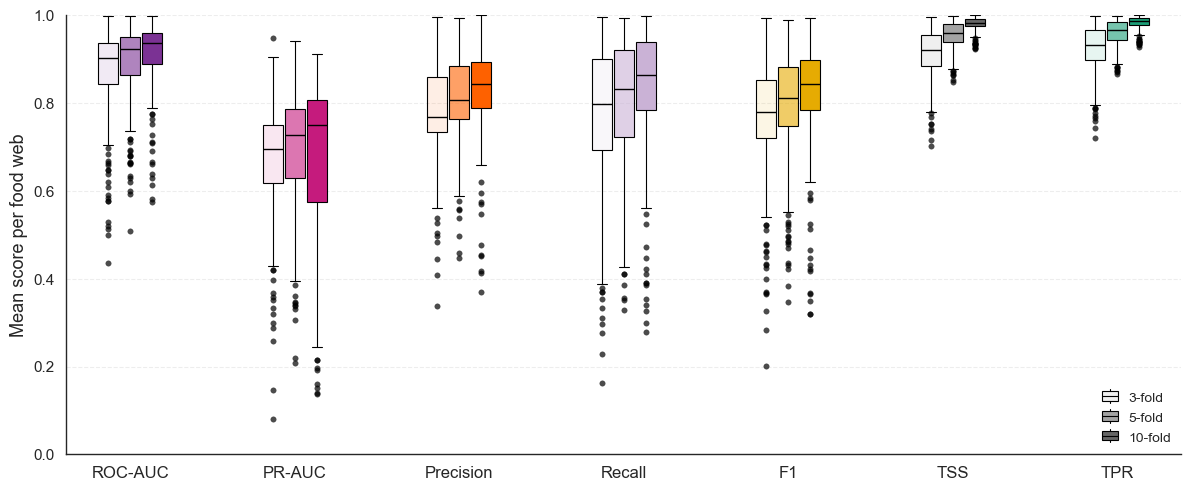

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import to_rgba
from matplotlib.patches import Rectangle
from matplotlib.legend_handler import HandlerBase

# =========================
# Style (match old snippet)
# =========================
sns.set_context("paper")
sns.set_style("white")

# -----------------------------
# Config
# -----------------------------
LOG_DIR = "../../../src/matlab/data/result_kfold_cross-validation_pseudo_properties/prediction_scores_logs"
PATTERN = "*tax_mass_results_random_wlnm_dir_neg_kfold.csv"

K_TARGET = 10
cvk_order = [3, 5, 10]
METRICS = ["ROC_AUC", "PR_AUC", "Precision", "Recall", "F1Score", "PseudoTSS", "PseudoTPR"]

# -----------------------------
# Helpers
# -----------------------------
def cvk_label(k: int) -> str:
    return f"{k}-fold"

def foodweb_name_from_path(p: str) -> str:
    return os.path.basename(p).replace("_tax_mass_results_random_wlnm_dir_neg_kfold.csv", "")

def collect_foodweb_means(log_dir: str, pattern: str) -> pd.DataFrame:
    required_cols = {"CvK", *METRICS}

    rows = []
    csv_files = sorted(glob.glob(os.path.join(log_dir, pattern)))
    print(f"Found {len(csv_files)} CSV files matching pattern in {log_dir}")

    for csv_path in csv_files:
        try:
            df = pd.read_csv(csv_path)
        except Exception as e:
            print(f"[SKIP] {os.path.basename(csv_path)} read error: {e}")
            continue

        missing = required_cols - set(df.columns)
        if missing:
            print(f"[SKIP] {os.path.basename(csv_path)} missing columns: {sorted(missing)}")
            continue

        # Filter by K if present
        if "K" in df.columns:
            df = df[df["K"] == K_TARGET].copy()

        # Keep only desired CV regimes
        df = df[df["CvK"].isin(cvk_order)].copy()
        if df.empty:
            print(f"[SKIP] {os.path.basename(csv_path)} no rows after K/CvK filtering.")
            continue

        df["CvK"] = pd.to_numeric(df["CvK"], errors="coerce").astype("Int64")

        # Mean across ALL fold-level rows for each CvK (per food web)
        agg = (
            df.groupby("CvK", as_index=False)[METRICS]
              .mean()
        )

        fw = foodweb_name_from_path(csv_path)
        agg["Foodweb"] = fw

        rows.append(agg)

    if not rows:
        return pd.DataFrame()

    out = pd.concat(rows, ignore_index=True)

    cvk_to_label = {k: cvk_label(k) for k in cvk_order}
    out["CvK_label"] = out["CvK"].map(cvk_to_label)

    return out

class HandlerMiniBoxplot(HandlerBase):
    def create_artists(
        self, legend, orig_handle,
        xdescent, ydescent, width, height, fontsize, trans
    ):
        facecolor = orig_handle["facecolor"]
        edgecolor = orig_handle.get("edgecolor", "black")
        linewidth = orig_handle.get("linewidth", 0.6)

        y_shift = -0.06 * height

        cx = xdescent + 0.5 * width
        cy = ydescent + 0.5 * height + y_shift

        box_w = 0.8 * width
        box_h = 0.8 * height
        box_x = cx - box_w / 2
        box_y = cy - box_h / 2

        whisk_top_y = box_y + box_h + 0.18 * height
        whisk_bot_y = box_y - 0.18 * height

        box = Rectangle(
            (box_x, box_y),
            box_w,
            box_h,
            facecolor=facecolor,
            edgecolor=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        median = Line2D(
            [box_x, box_x + box_w],
            [cy, cy],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        whisker_top = Line2D(
            [cx, cx],
            [box_y + box_h, whisk_top_y],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        whisker_bottom = Line2D(
            [cx, cx],
            [whisk_bot_y, box_y],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        return [box, median, whisker_top, whisker_bottom]


def plot_foodweb_means_1x4(df_means: pd.DataFrame) -> None:
    if df_means.empty:
        print("No data to plot.")
        return

    present_cvks = [k for k in cvk_order if k in df_means["CvK"].dropna().unique()]
    if len(present_cvks) < 2:
        print("Not enough CV regimes present to plot.")
        return

    plot_metrics = [
        ("ROC_AUC", "ROC-AUC"),
        ("PR_AUC", "PR-AUC"),
        ("Precision", "Precision"),
        ("Recall", "Recall"),
        ("F1Score", "F1"),
        ("PseudoTSS", "TSS"),
        ("PseudoTPR", "TPR"),
    ]

    metric_palette = {
        "ROC_AUC": "#7B3294",    # ROC-AUC purple
        "PR_AUC": "#C51B7D",     # magenta
        "Precision": "#FE6100",  # orange
        "Recall": "#CAB2D6",     # violet
        "F1Score": "#E6AB02",    # mustard
        "PseudoTSS": "#666666",  # dark gray
        "PseudoTPR": "#1B9E77",  # teal-green
    }

    alpha_map = {
        3: 0.1,
        5: 0.6,
        10: 1,
    }

    label_map = {
        3: "3-fold",
        5: "5-fold",
        10: "10-fold",
    }

    fig, ax = plt.subplots(figsize=(12, 5))

    group_gap = 1.8
    group_centers = 1.0 + np.arange(len(plot_metrics)) * group_gap

    offsets = np.array([-0.24, 0.0, 0.24])
    box_width = 0.22

    for j, cvk in enumerate(present_cvks):
        data_for_cvk = []
        positions_for_cvk = []
        metrics_for_boxes = []

        for i, (metric, _) in enumerate(plot_metrics):
            vals = (
                df_means.loc[df_means["CvK"] == cvk, metric]
                .dropna()
                .values
            )

            if len(vals) == 0:
                continue

            data_for_cvk.append(vals)
            positions_for_cvk.append(group_centers[i] + offsets[j])
            metrics_for_boxes.append(metric)

        bp = ax.boxplot(
            data_for_cvk,
            positions=positions_for_cvk,
            widths=box_width,
            patch_artist=True,
            manage_ticks=False,
            showfliers=True,
            boxprops=dict(
                edgecolor="black",
                linewidth=0.8,
            ),
            medianprops=dict(color="black", linewidth=1.0),
            whiskerprops=dict(color="black", linewidth=0.8),
            capprops=dict(color="black", linewidth=0.8),
            flierprops=dict(
                marker="o",
                markersize=4,
                markerfacecolor="black",
                markeredgecolor="black",
                markeredgewidth=0.2,
                alpha=0.7,
            ),
        )

        for box, metric in zip(bp["boxes"], metrics_for_boxes):
            box.set_facecolor(to_rgba(metric_palette[metric], alpha=alpha_map[cvk]))

    legend_handles = [
        {
            "facecolor": to_rgba("#666666", alpha=alpha_map[k]),
            "edgecolor": "black",
            "linewidth": 0.8,
        }
        for k in present_cvks
    ]

    ax.set_xlim(group_centers[0] - 0.7, group_centers[-1] + 0.7)
    ax.set_ylim(0, 1.0)

    ax.set_xticks(group_centers)
    ax.set_xticklabels([label for _, label in plot_metrics], ha="center", fontsize=12)

    ax.set_ylabel("Mean score per food web", fontsize=13)
    ax.set_xlabel("")

    ax.tick_params(axis="y", labelsize=11)
    ax.yaxis.set_major_locator(plt.MaxNLocator(6))
    ax.grid(True, axis="y", linestyle="--", alpha=0.35)
    sns.despine(ax=ax)

    ax.legend(
        handles=legend_handles,
        labels=[label_map[k] for k in present_cvks],
        handler_map={dict: HandlerMiniBoxplot()},
        loc="lower right",
        frameon=False,
        fontsize=10,
        handlelength=1.5,
        handleheight=0.9,
        handletextpad=0.6,
        borderpad=0.2,
        labelspacing=0.45,
    )

    plt.tight_layout()
    plt.show()

# -----------------------------
# Run
# -----------------------------
df_means = collect_foodweb_means(LOG_DIR, PATTERN)

print("\nFoodweb count per CvK:")
print(df_means.groupby("CvK")["Foodweb"].nunique())

plot_foodweb_means_1x4(df_means)

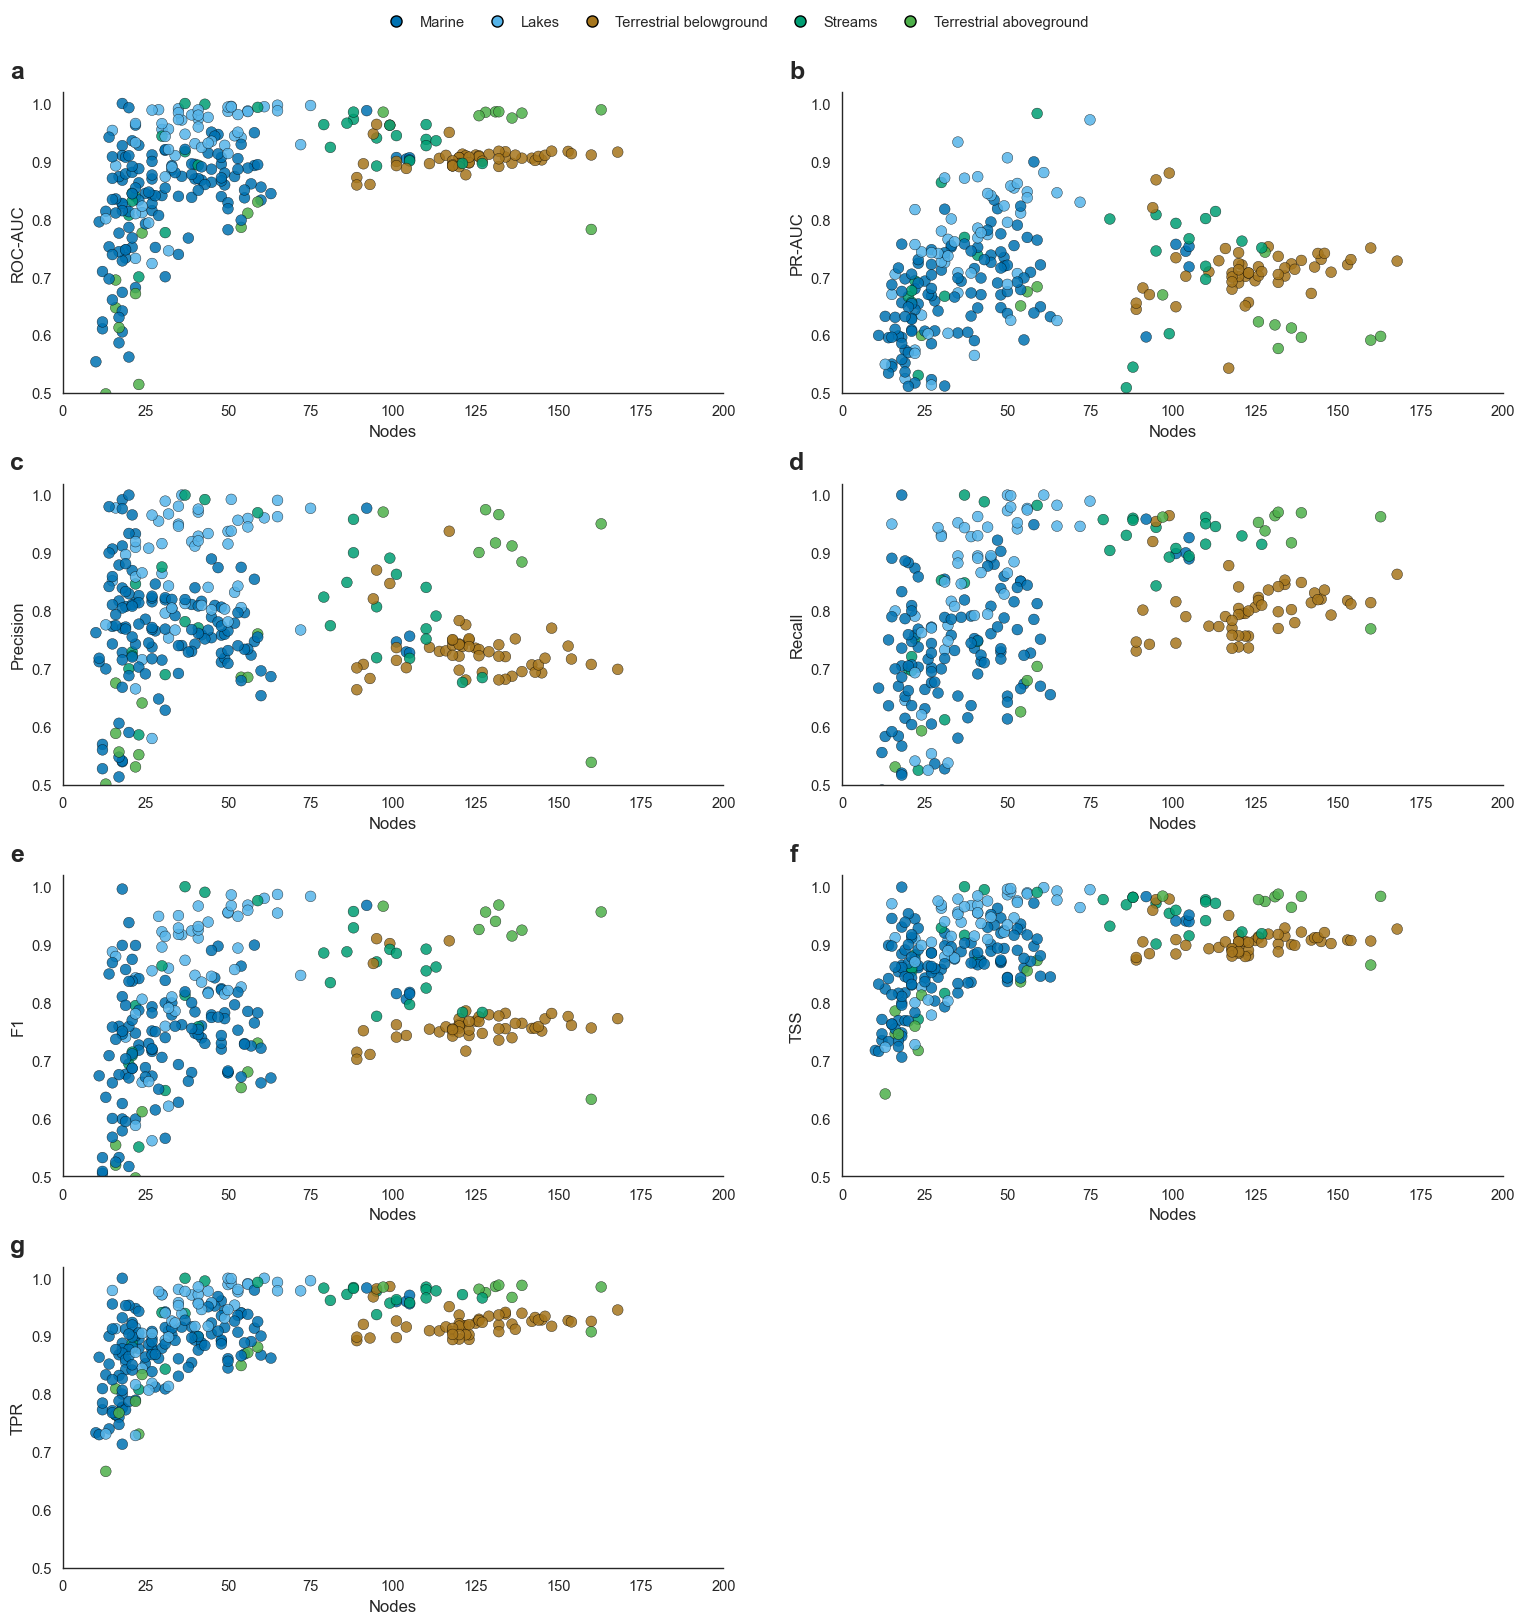

In [3]:
import glob
import math
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

sns.set_theme(style="white", context="paper", font_scale=1.2)

# ============================================================
# Week-15 palettes
# ============================================================
ecosystem_palette = {
    "Lakes": "#56B4E9",
    "Streams": "#009E73",
    "Marine": "#0072B2",
    "Terrestrial aboveground": "#4DAF4A",
    "Terrestrial belowground": "#A6761D",
}

metric_palette = {
    "ROC-AUC": "#7B3294",   # purple
    "PR-AUC": "#C51B7D",    # magenta
    "Precision": "#FE6100", # orange
    "Recall": "#CAB2D6",    # violet
    "F1": "#E6AB02",        # mustard
    "TSS": "#666666",       # dark gray
    "TPR": "#1B9E77",       # teal-green
}

version_palette = {
    "Original": "#7570B3",
    "Directed": "#1F78B4",
    "Directed-Negative": "#1B9E77",
}

network_type_palette = {
    "Empirical": "#3A7D44",
    "Pseudo": "#C6923A",
}

# ============================================================
# Config
# ============================================================
RESULTS_DIR = Path("../../../src/matlab/data/result_wlnm_dir_neg_pseudo_properties_k60_evaluate_unseen-false/prediction_scores_logs")
ECOSYSTEM_FILE = Path("../../../src/matlab/data/foodwebs_mat/foodweb_metrics_ecosystem.csv")
RESULTS_PATTERN = "*_tax_mass_results_random_wlnm_dir_neg.csv"

TARGET_RATIO = 60.0

METRIC_SPECS = [
    ("ROC_AUC", "ROC-AUC"),
    ("PR_AUC", "PR-AUC"),
    ("Precision", "Precision"),
    ("Recall", "Recall"),
    ("F1Score", "F1"),
    ("PseudoTSS", "TSS"),
    ("PseudoTPR", "TPR"),
]

Y_MIN, Y_MAX = 0.5, 1.0
Y_PAD_TOP = 0.02   # small padding so top points are not visually cut
X_MAX = 200
N_COLS = 2

# ============================================================
# Helpers
# ============================================================
def normalize_colname(s: str) -> str:
    return (
        str(s).strip().lower()
        .replace(" ", "")
        .replace(".", "")
        .replace("-", "")
        .replace("_", "")
    )

def find_column(df: pd.DataFrame, candidates):
    norm_map = {normalize_colname(c): c for c in df.columns}
    for cand in candidates:
        if cand in norm_map:
            return norm_map[cand]
    raise KeyError(f"Could not find any of these columns: {candidates}")

def extract_foodweb_name(filepath: str) -> str:
    return Path(filepath).name.split("_results_")[0]

def format_ecosystem_label(name: str) -> str:
    name = str(name).strip().lower()
    label_map = {
        "lakes": "Lakes",
        "streams": "Streams",
        "marine": "Marine",
        "terrestrial aboveground": "Terrestrial aboveground",
        "terrestrial belowground": "Terrestrial belowground",
    }
    return label_map.get(name, str(name).strip().capitalize())

# ============================================================
# Load ecosystem metadata
# ============================================================
df_ecosystem = pd.read_csv(ECOSYSTEM_FILE)

foodweb_col = find_column(df_ecosystem, ["foodweb"])
ecosystem_col = find_column(df_ecosystem, ["ecosystemtype", "ecosystem", "ecosystem_type"])
nodes_col = find_column(df_ecosystem, ["nodes", "n_nodes", "num_nodes", "nodecount", "s"])

df_ecosystem = df_ecosystem.rename(columns={
    foodweb_col: "Foodweb",
    ecosystem_col: "EcosystemType",
    nodes_col: "Nodes",
})

df_ecosystem["Foodweb"] = df_ecosystem["Foodweb"].astype(str)
df_ecosystem["EcosystemType"] = df_ecosystem["EcosystemType"].astype(str).str.strip()
df_ecosystem["Nodes"] = pd.to_numeric(df_ecosystem["Nodes"], errors="coerce")

# ============================================================
# Load results
# ============================================================
csv_files = sorted(glob.glob(str(RESULTS_DIR / RESULTS_PATTERN)))
if not csv_files:
    raise RuntimeError(f"No result CSV found in {RESULTS_DIR} matching {RESULTS_PATTERN}")

dfs = []
for file in csv_files:
    df = pd.read_csv(file)
    df["Foodweb"] = extract_foodweb_name(file)
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)

# Backward compatibility if some files still use AUC instead of ROC_AUC
if "ROC_AUC" not in df_all.columns and "AUC" in df_all.columns:
    df_all = df_all.rename(columns={"AUC": "ROC_AUC"})

missing_metrics = [m for m, _ in METRIC_SPECS if m not in df_all.columns]
if missing_metrics:
    raise RuntimeError(f"Missing required metric columns: {missing_metrics}")

# ============================================================
# Merge + filter to TrainRatio = 60
# ============================================================
df_merged = pd.merge(
    df_all,
    df_ecosystem[["Foodweb", "EcosystemType", "Nodes"]],
    on="Foodweb",
    how="left"
)

df_tr = df_merged[pd.to_numeric(df_merged["TrainRatio"], errors="coerce") == TARGET_RATIO].copy()
if df_tr.empty:
    raise RuntimeError(f"No rows for TrainRatio = {TARGET_RATIO}. Check TrainRatio values.")

# Mean per food web
agg_dict = {metric_col: "mean" for metric_col, _ in METRIC_SPECS}
df_scatter = (
    df_tr
    .groupby(["Foodweb", "EcosystemType", "Nodes"], as_index=False)
    .agg(agg_dict)
)

if df_scatter.empty:
    raise RuntimeError("No data left after grouping by food web.")

# ============================================================
# Ecosystem order + palette
# ============================================================
eco_order = df_scatter["EcosystemType"].value_counts().index.tolist()
df_scatter["EcosystemType"] = pd.Categorical(
    df_scatter["EcosystemType"],
    categories=eco_order,
    ordered=True
)

eco_palette = {
    eco: ecosystem_palette.get(format_ecosystem_label(eco), "#999999")
    for eco in eco_order
}

# ============================================================
# Plot
# ============================================================
n_panels = len(METRIC_SPECS)
n_rows = math.ceil(n_panels / N_COLS)

fig, axes = plt.subplots(
    n_rows, N_COLS,
    figsize=(16, 4.5 * n_rows),
    sharex=False,
    sharey=False
)

axes = np.array(axes).reshape(-1)
panel_letters = list("abcdefghijklmnopqrstuvwxyz")

for i, ((metric_col, metric_label), ax) in enumerate(zip(METRIC_SPECS, axes)):
    sns.scatterplot(
        data=df_scatter,
        x="Nodes",
        y=metric_col,
        hue="EcosystemType",
        palette=eco_palette,
        alpha=0.85,
        edgecolor="black",
        linewidth=0.3,
        s=60,
        legend=False,
        ax=ax,
    )

    ax.set_ylabel(metric_label, fontsize=12)
    ax.set_xlabel("Nodes", fontsize=12)
    ax.tick_params(axis="x", labelbottom=True)
    ax.tick_params(axis="y", labelleft=True)

    ax.set_xlim(0, X_MAX)
    ax.set_ylim(Y_MIN, Y_MAX + Y_PAD_TOP)
    ax.yaxis.set_major_locator(plt.MaxNLocator(6))
    sns.despine(ax=ax)

    ax.text(
        -0.08, 1.03, panel_letters[i],
        transform=ax.transAxes,
        fontsize=18,
        fontweight="bold",
        va="bottom",
        ha="left",
        clip_on=False,
    )

# Hide unused axes
for j in range(n_panels, len(axes)):
    axes[j].set_axis_off()

# Figure-level legend
legend_handles = [
    Line2D(
        [0], [0],
        marker="o",
        linestyle="",
        markersize=8,
        markerfacecolor=eco_palette[name],
        markeredgecolor="black",
        label=format_ecosystem_label(name),
    )
    for name in eco_order
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.95),
    ncol=min(len(eco_order), 5),
    frameon=False,
    columnspacing=1.2,
    handletextpad=0.6,
)

# fig.suptitle(f"Performance versus node count (TrainRatio = {int(TARGET_RATIO)}%)", y=0.995, fontsize=14)
fig.subplots_adjust(top=0.90, hspace=0.30, wspace=0.18, left=0.08, right=0.98, bottom=0.08)

plt.show()

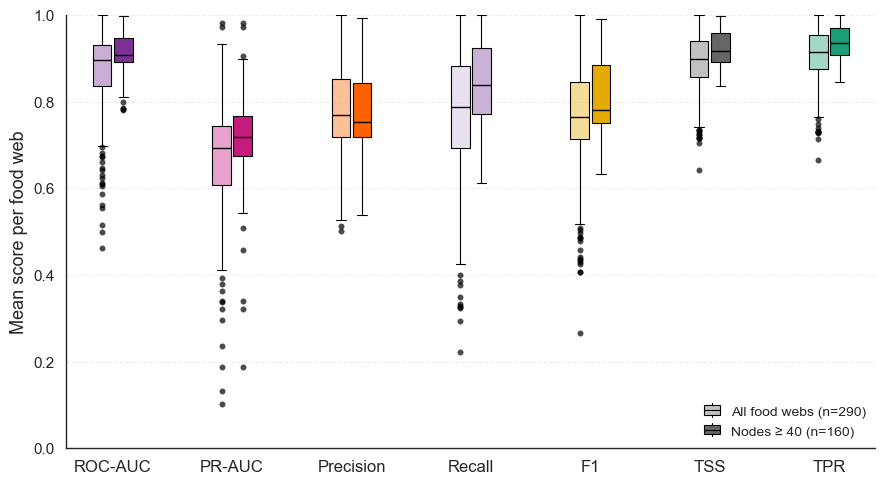

In [12]:
import glob
import os
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib.legend_handler import HandlerBase


# ============================================================
# Style
# ============================================================
sns.set_theme(style="white", context="paper", font_scale=1.2)


# ============================================================
# Week-15 palettes
# ============================================================
metric_palette = {
    "ROC-AUC": "#7B3294",   # purple
    "PR-AUC": "#C51B7D",    # magenta
    "Precision": "#FE6100", # orange
    "Recall": "#CAB2D6",    # violet
    "F1": "#E6AB02",        # mustard
    "TSS": "#666666",       # dark gray
    "TPR": "#1B9E77",       # teal-green
}


# ============================================================
# Config
# ============================================================
RESULTS_DIR = Path("../../../src/matlab/data/result_wlnm_dir_neg_pseudo_properties_k60_evaluate_unseen-false/prediction_scores_logs")
ECOSYSTEM_FILE = Path("../../../src/matlab/data/foodwebs_mat/foodweb_metrics_ecosystem.csv")
RESULTS_PATTERN = "*_tax_mass_results_random_wlnm_dir_neg.csv"

TARGET_RATIO = 60.0
NODES_THRESHOLD = 40

PLOT_METRICS = [
    ("ROC_AUC", "ROC-AUC"),
    ("PR_AUC", "PR-AUC"),
    ("Precision", "Precision"),
    ("Recall", "Recall"),
    ("F1Score", "F1"),
    ("PseudoTSS", "TSS"),
    ("PseudoTPR", "TPR"),
]

GROUP_ORDER = ["All food webs", f"Nodes ≥ {NODES_THRESHOLD}"]

# Same metric color, different opacity for the comparison
group_alpha = {
    "All food webs": 0.40,
    f"Nodes ≥ {NODES_THRESHOLD}": 1,
}


# ============================================================
# Helpers
# ============================================================
def normalize_colname(s: str) -> str:
    return (
        str(s).strip().lower()
        .replace(" ", "")
        .replace(".", "")
        .replace("-", "")
        .replace("_", "")
    )

def extract_foodweb_name(filepath: str) -> str:
    return Path(filepath).name.split("_results_")[0]

def find_column(df: pd.DataFrame, candidates):
    norm_map = {normalize_colname(c): c for c in df.columns}
    for cand in candidates:
        if cand in norm_map:
            return norm_map[cand]
    raise KeyError(f"Could not find any of these columns: {candidates}")

class HandlerMiniBoxplot(HandlerBase):
    def create_artists(
        self, legend, orig_handle,
        xdescent, ydescent, width, height, fontsize, trans
    ):
        facecolor = orig_handle["facecolor"]
        edgecolor = orig_handle.get("edgecolor", "black")
        linewidth = orig_handle.get("linewidth", 0.6)

        y_shift = -0.06 * height

        cx = xdescent + 0.5 * width
        cy = ydescent + 0.5 * height + y_shift

        box_w = 0.8 * width
        box_h = 0.8 * height
        box_x = cx - box_w / 2
        box_y = cy - box_h / 2

        whisk_top_y = box_y + box_h + 0.18 * height
        whisk_bot_y = box_y - 0.18 * height

        box = Rectangle(
            (box_x, box_y),
            box_w,
            box_h,
            facecolor=facecolor,
            edgecolor=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        median = Line2D(
            [box_x, box_x + box_w],
            [cy, cy],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        whisker_top = Line2D(
            [cx, cx],
            [box_y + box_h, whisk_top_y],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        whisker_bottom = Line2D(
            [cx, cx],
            [whisk_bot_y, box_y],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        return [box, median, whisker_top, whisker_bottom]


# ============================================================
# Load metadata
# ============================================================
df_ecosystem = pd.read_csv(ECOSYSTEM_FILE)

foodweb_col = find_column(df_ecosystem, ["foodweb"])
nodes_col = find_column(df_ecosystem, ["nodes", "n_nodes", "num_nodes", "nodecount", "s"])

df_ecosystem = df_ecosystem.rename(columns={
    foodweb_col: "Foodweb",
    nodes_col: "Nodes",
})

df_ecosystem["Foodweb"] = df_ecosystem["Foodweb"].astype(str)
df_ecosystem["Nodes"] = pd.to_numeric(df_ecosystem["Nodes"], errors="coerce")


# ============================================================
# Load results
# ============================================================
csv_files = sorted(glob.glob(str(RESULTS_DIR / RESULTS_PATTERN)))
if not csv_files:
    raise RuntimeError(f"No result CSV found in {RESULTS_DIR} matching {RESULTS_PATTERN}")

dfs = []
for file in csv_files:
    df = pd.read_csv(file)
    df["Foodweb"] = extract_foodweb_name(file)
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)

# Backward compatibility if the file still uses AUC instead of ROC_AUC
if "ROC_AUC" not in df_all.columns and "AUC" in df_all.columns:
    df_all = df_all.rename(columns={"AUC": "ROC_AUC"})


# ============================================================
# Merge + filter
# ============================================================
df_merged = pd.merge(
    df_all,
    df_ecosystem[["Foodweb", "Nodes"]],
    on="Foodweb",
    how="left"
)

df_tr = df_merged[pd.to_numeric(df_merged["TrainRatio"], errors="coerce") == TARGET_RATIO].copy()
if df_tr.empty:
    raise RuntimeError(f"No rows for TrainRatio = {TARGET_RATIO}. Check TrainRatio values.")

required_metric_cols = [col for col, _ in PLOT_METRICS if col in df_tr.columns]
if not required_metric_cols:
    raise RuntimeError("None of the requested metrics were found in the results files.")

# Keep only metrics that actually exist
PLOT_METRICS = [(col, label) for col, label in PLOT_METRICS if col in df_tr.columns]


# ============================================================
# Mean per food web
# ============================================================
agg_dict = {metric_col: "mean" for metric_col, _ in PLOT_METRICS}

df_web = (
    df_tr
    .groupby(["Foodweb", "Nodes"], as_index=False)
    .agg(agg_dict)
)

# Comparison groups:
# 1) all food webs
# 2) same results after excluding <= 40 nodes
df_all_group = df_web.copy()
df_all_group["FilterGroup"] = "All food webs"

df_ge40_group = df_web[df_web["Nodes"] >= NODES_THRESHOLD].copy()
df_ge40_group["FilterGroup"] = f"Nodes ≥ {NODES_THRESHOLD}"

df_compare = pd.concat([df_all_group, df_ge40_group], ignore_index=True)
if df_compare.empty:
    raise RuntimeError("No data left after building the comparison groups.")


# ============================================================
# Long format
# ============================================================
df_long = pd.concat(
    [
        df_compare[["Foodweb", "FilterGroup", metric_col]]
        .rename(columns={metric_col: "Value"})
        .assign(Metric=metric_label)
        for metric_col, metric_label in PLOT_METRICS
    ],
    ignore_index=True,
)

df_long = df_long.dropna(subset=["Value"]).copy()
if df_long.empty:
    raise RuntimeError("No data left to plot after dropping missing metric values.")


# ============================================================
# Legend labels
# ============================================================
group_counts = df_compare.groupby("FilterGroup")["Foodweb"].nunique().to_dict()

group_display_labels = {
    g: f"{g} (n={group_counts.get(g, 0)})"
    for g in GROUP_ORDER
}


# ============================================================
# Plot
# ============================================================
fig, ax = plt.subplots(figsize=(9.0, 5.0))

group_centers = 1.0 + np.arange(len(PLOT_METRICS)) * 1.8
offsets = np.array([-0.16, 0.16])
box_width = 0.28

for j, group_name in enumerate(GROUP_ORDER):
    data_for_group = []
    positions_for_group = []
    metric_labels_for_boxes = []

    for i, (_, metric_label) in enumerate(PLOT_METRICS):
        vals = (
            df_long.loc[
                (df_long["FilterGroup"] == group_name) &
                (df_long["Metric"] == metric_label),
                "Value"
            ]
            .dropna()
            .values
        )

        if len(vals) == 0:
            continue

        data_for_group.append(vals)
        positions_for_group.append(group_centers[i] + offsets[j])
        metric_labels_for_boxes.append(metric_label)

    bp = ax.boxplot(
        data_for_group,
        positions=positions_for_group,
        widths=box_width,
        patch_artist=True,
        manage_ticks=False,
        showfliers=True,
        boxprops=dict(
            edgecolor="black",
            linewidth=0.8,
        ),
        medianprops=dict(color="black", linewidth=1.0),
        whiskerprops=dict(color="black", linewidth=0.8),
        capprops=dict(color="black", linewidth=0.8),
        flierprops=dict(
            marker="o",
            markersize=4,
            markerfacecolor="black",
            markeredgecolor="black",
            markeredgewidth=0.2,
            alpha=0.7,
        ),
    )

    for box, metric_label in zip(bp["boxes"], metric_labels_for_boxes):
        box.set_facecolor(to_rgba(metric_palette[metric_label], alpha=group_alpha[group_name]))

legend_handles = [
    {
        "facecolor": to_rgba("#666666", alpha=group_alpha[g]),
        "edgecolor": "black",
        "linewidth": 0.8,
    }
    for g in GROUP_ORDER
]

ax.set_xlim(group_centers[0] - 0.7, group_centers[-1] + 0.7)
ax.set_ylim(0, 1.0)

ax.set_xticks(group_centers)
ax.set_xticklabels(
    [metric_label for _, metric_label in PLOT_METRICS],
    ha="center",
    fontsize=12,
)

ax.set_ylabel("Mean score per food web", fontsize=13)
ax.set_xlabel("")

ax.tick_params(axis="y", labelsize=11)
ax.yaxis.set_major_locator(plt.MaxNLocator(6))
ax.grid(True, axis="y", linestyle="--", alpha=0.35)
sns.despine(ax=ax)

ax.legend(
    handles=legend_handles,
    labels=[group_display_labels[g] for g in GROUP_ORDER],
    handler_map={dict: HandlerMiniBoxplot()},
    loc="lower right",
    frameon=False,
    fontsize=10,
    handlelength=1.5,
    handleheight=0.9,
    handletextpad=0.6,
    borderpad=0.2,
    labelspacing=0.45,
)

plt.tight_layout()
plt.show()

[INFO] Foodwebs with Nodes >= 40: 160
[INFO] Foodwebs in results before filter: 290
[INFO] Foodwebs in results after filter: 160


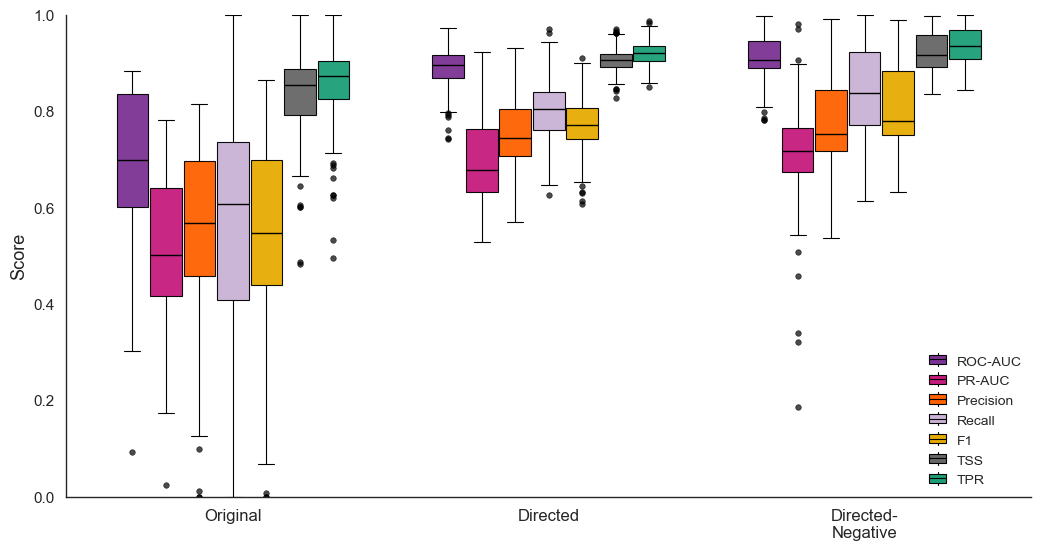

In [14]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib.legend_handler import HandlerBase


# =========================
# Style
# =========================
sns.set_theme(context="paper", style="white")


# =========================
# Week-15 palettes
# =========================
metric_palette = {
    "ROC_AUC": "#7B3294",    # ROC-AUC purple
    "PR_AUC": "#C51B7D",     # PR-AUC magenta
    "Precision": "#FE6100",  # orange
    "Recall": "#CAB2D6",     # violet
    "F1Score": "#E6AB02",    # mustard
    "PseudoTSS": "#666666",  # dark gray
    "PseudoTPR": "#1B9E77",  # teal-green
}

version_palette = {
    "original": "#7570B3",
    "directed": "#1F78B4",
    "dir_neg": "#1B9E77",
}


# =========================
# Config
# =========================
RESULTS_DIR_ORIGINAL = Path("../../../src/matlab/data/result_wlnm_original_pseudo_properties_k60_evaluate_unseen-false/prediction_scores_logs")
RESULTS_DIR_DIRECTED = Path("../../../src/matlab/data/result_wlnm_directed_pseudo_properties_k60_evaluate_unseen-false/prediction_scores_logs")
RESULTS_DIR_DIR_NEG  = Path("../../../src/matlab/data/result_wlnm_dir_neg_pseudo_properties_k60_evaluate_unseen-false/prediction_scores_logs")

FOODWEB_CSV = Path("../../../src/matlab/data/foodwebs_mat/foodweb_metrics_ecosystem.csv")

METRICS_TO_PLOT = ["ROC_AUC", "PR_AUC", "Precision", "Recall", "F1Score", "PseudoTSS", "PseudoTPR"]
METRIC_LABELS = {
    "ROC_AUC": "ROC-AUC",
    "PR_AUC": "PR-AUC",
    "Precision": "Precision",
    "Recall": "Recall",
    "F1Score": "F1",
    "PseudoTSS": "TSS",
    "PseudoTPR": "TPR",
}

K_TARGET = None
K_COL = "K"
NODES_THRESHOLD = 40

GLOB_PATTERN_ORIGINAL = "*_tax_mass_results_random_wlnm_original.csv"
GLOB_PATTERN_DIRECTED = "*_tax_mass_results_random_wlnm_directed.csv"
GLOB_PATTERN_DIR_NEG  = "*_tax_mass_results_random_wlnm_dir_neg.csv"

Y_PADDING = 0.02
Y_MIN_FLOOR = 0
Y_MAX_CAP = 1.0


# =========================
# Helpers
# =========================
def normalize_fw_label(name: str) -> str:
    name = str(name).strip()
    name, _ = os.path.splitext(name)
    name = name.replace(" ", "_")
    for token in [
        "_results_", "_result_", "_results",
        "_random", "_tax_mass", "_tax", "_mass"
    ]:
        name = name.replace(token, "_")
    return "_".join(part for part in name.split("_") if part)


def parse_foodweb_from_name(fname: str) -> str:
    base = Path(fname).name
    if "_results_" in base:
        return base.split("_results_")[0]
    return Path(fname).stem


def coerce_numeric(df: pd.DataFrame, cols) -> pd.DataFrame:
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df


def load_one_csv(csv_path: Path, version: str):
    df = pd.read_csv(csv_path)

    present_metrics = [m for m in METRICS_TO_PLOT if m in df.columns]
    if not present_metrics:
        print(f"[SKIP] Missing all target metrics in: {csv_path.name}")
        return None

    df = coerce_numeric(df, METRICS_TO_PLOT + [K_COL])

    if K_TARGET is not None and K_COL in df.columns:
        df = df[df[K_COL] == K_TARGET].copy()
        if df.empty:
            return None

    out = {
        "Foodweb": parse_foodweb_from_name(csv_path.name),
        "Version": version,
        "n_rows": int(len(df)),
        "file": csv_path.name,
        "folder": str(csv_path.parent),
    }

    valid_any = False
    for metric in METRICS_TO_PLOT:
        if metric in df.columns:
            vals = df[metric].dropna().values
            out[f"{metric}_mean"] = float(np.mean(vals)) if vals.size else np.nan
            if vals.size:
                valid_any = True
        else:
            out[f"{metric}_mean"] = np.nan

    if not valid_any:
        return None

    return out


def load_folder(folder: Path, pattern: str, version: str):
    csv_files = sorted(folder.glob(pattern))
    if not csv_files:
        raise FileNotFoundError(
            f"No files found in {folder.resolve()} matching: {pattern}"
        )

    rows = []
    for p in csv_files:
        rec = load_one_csv(p, version=version)
        if rec is not None:
            rows.append(rec)

    return rows


class HandlerMiniBoxplot(HandlerBase):
    def create_artists(
        self, legend, orig_handle,
        xdescent, ydescent, width, height, fontsize, trans
    ):
        facecolor = orig_handle["facecolor"]
        edgecolor = orig_handle.get("edgecolor", "black")
        linewidth = orig_handle.get("linewidth", 0.6)

        y_shift = -0.06 * height
        cx = xdescent + 0.5 * width
        cy = ydescent + 0.5 * height + y_shift

        box_w = 0.8 * width
        box_h = 0.8 * height
        box_x = cx - box_w / 2
        box_y = cy - box_h / 2

        whisk_top_y = box_y + box_h + 0.18 * height
        whisk_bot_y = box_y - 0.18 * height

        box = Rectangle(
            (box_x, box_y),
            box_w,
            box_h,
            facecolor=facecolor,
            edgecolor=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        median = Line2D(
            [box_x, box_x + box_w],
            [cy, cy],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        whisker_top = Line2D(
            [cx, cx],
            [box_y + box_h, whisk_top_y],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        whisker_bottom = Line2D(
            [cx, cx],
            [whisk_bot_y, box_y],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        return [box, median, whisker_top, whisker_bottom]


# =========================
# Load metadata once
# =========================
meta = pd.read_csv(FOODWEB_CSV)
meta.columns = [c.strip() for c in meta.columns]

fw_col = next((c for c in meta.columns if c.lower() == "foodweb"), None)
nodes_col = next((c for c in meta.columns if c.lower() == "nodes"), None)

if fw_col is None or nodes_col is None:
    raise ValueError("Could not find 'Foodweb' and 'Nodes' columns in FOODWEB_CSV.")

meta["FW_KEY"] = meta[fw_col].apply(normalize_fw_label)

meta_filtered = meta.loc[
    meta[nodes_col] >= NODES_THRESHOLD,
    ["FW_KEY", nodes_col]
].copy()

allowed_fw_keys = set(meta_filtered["FW_KEY"].unique())
print(f"[INFO] Foodwebs with Nodes >= {NODES_THRESHOLD}: {len(allowed_fw_keys)}")


# =========================
# Load all CSVs (all versions)
# =========================
rows = []
rows += load_folder(RESULTS_DIR_ORIGINAL, GLOB_PATTERN_ORIGINAL, version="original")
rows += load_folder(RESULTS_DIR_DIRECTED, GLOB_PATTERN_DIRECTED, version="directed")
rows += load_folder(RESULTS_DIR_DIR_NEG,  GLOB_PATTERN_DIR_NEG,  version="dir_neg")

df_all = pd.DataFrame(rows)

if df_all.empty:
    raise RuntimeError("No valid rows after loading folders. Check file patterns or CSV columns.")

df_all["FW_KEY"] = df_all["Foodweb"].apply(normalize_fw_label)

print(f"[INFO] Foodwebs in results before filter: {df_all['FW_KEY'].nunique()}")

df_all = df_all[df_all["FW_KEY"].isin(allowed_fw_keys)].copy()

print(f"[INFO] Foodwebs in results after filter: {df_all['Foodweb'].nunique()}")

if df_all.empty:
    raise ValueError(f"No foodwebs left after filtering Nodes > {NODES_THRESHOLD}.")


# =========================
# One row per Foodweb per Version
# =========================
mean_cols = [f"{metric}_mean" for metric in METRICS_TO_PLOT]
df_all = (
    df_all
    .groupby(["FW_KEY", "Foodweb", "Version"], as_index=False)[mean_cols]
    .mean()
)

# =========================
# Plot: single-panel grouped boxplot by VERSION
# =========================
version_order = ["original", "directed", "dir_neg"]
version_labels = {
    "original": "Original",
    "directed": "Directed",
    "dir_neg": "Directed-\nNegative",
}

plot_metrics = [(metric, METRIC_LABELS[metric]) for metric in METRICS_TO_PLOT]

fig, ax = plt.subplots(figsize=(10.5, 5.6))

# Base x positions for version groups
group_gap = 2.2
group_centers = 1.0 + np.arange(len(version_order)) * group_gap

# 7 metrics inside each version group
offsets = np.linspace(-0.7, 0.7, len(plot_metrics))
box_width = 0.22

for j, (metric_col, metric_label) in enumerate(plot_metrics):
    data_for_metric = []
    positions_for_metric = []

    ycol = f"{metric_col}_mean"

    for i, version in enumerate(version_order):
        vals = (
            pd.to_numeric(
                df_all.loc[df_all["Version"] == version, ycol],
                errors="coerce"
            )
            .dropna()
            .to_numpy()
            .ravel()
        )

        if vals.size == 0:
            continue

        data_for_metric.append(vals)
        positions_for_metric.append(float(group_centers[i] + offsets[j]))

    if not data_for_metric:
        continue

    if len(data_for_metric) != len(positions_for_metric):
        print(
            f"[SKIP] {metric_col}: "
            f"{len(data_for_metric)=} != {len(positions_for_metric)=}"
        )
        continue

    ax.boxplot(
        data_for_metric,
        positions=positions_for_metric,
        widths=box_width,
        patch_artist=True,
        manage_ticks=False,
        showfliers=True,
        boxprops=dict(
            facecolor=metric_palette[metric_col],
            edgecolor="black",
            linewidth=0.8,
            alpha=0.95,
        ),
        medianprops=dict(color="black", linewidth=1.0),
        whiskerprops=dict(color="black", linewidth=0.8),
        capprops=dict(color="black", linewidth=0.8),
        flierprops=dict(
            marker="o",
            markersize=4,
            markerfacecolor="black",
            markeredgecolor="black",
            markeredgewidth=0.5,
            alpha=0.7,
        ),
    )

legend_handles = [
    {
        "facecolor": metric_palette[m],
        "edgecolor": "black",
        "linewidth": 0.8,
    }
    for m in METRICS_TO_PLOT
]

# Add extra horizontal padding so outer boxplots do not touch the borders
x_padding = 0.35
left_edge = group_centers[0] + offsets.min() - box_width / 2
right_edge = group_centers[-1] + offsets.max() + box_width / 2
ax.set_xlim(left_edge - x_padding, right_edge + x_padding)

panel_vals = pd.concat([df_all[c] for c in mean_cols], ignore_index=True).dropna()
local_min = max(Y_MIN_FLOOR, panel_vals.min() - Y_PADDING)
local_max = min(Y_MAX_CAP, panel_vals.max() + Y_PADDING)

if np.isclose(local_min, local_max):
    local_min = max(Y_MIN_FLOOR, local_min - 0.02)
    local_max = min(Y_MAX_CAP, local_max + 0.02)

ax.set_ylim(local_min, local_max)

ax.set_xticks(group_centers)
ax.set_xticklabels(
    [version_labels[v] for v in version_order],
    rotation=0,
    fontsize=12,
)

ax.set_ylabel("Score", fontsize=13)
ax.set_xlabel("")

ax.tick_params(axis="y", labelsize=11)
ax.grid(False, axis="x")
sns.despine(ax=ax)

ax.legend(
    handles=legend_handles,
    labels=[METRIC_LABELS[m] for m in METRICS_TO_PLOT],
    handler_map={dict: HandlerMiniBoxplot()},
    loc="lower right",
    frameon=False,
    fontsize=10,
    handlelength=1.5,
    handleheight=0.9,
    handletextpad=0.6,
    borderpad=0.2,
    labelspacing=0.45,
)

plt.tight_layout()
plt.show()

[INFO] Foodwebs with Nodes >= 40: 160

[INFO] Generating figure for metric: ROC_AUC
[INFO] Foodwebs in results before filter: 290
[INFO] Foodwebs in results after filter: 160


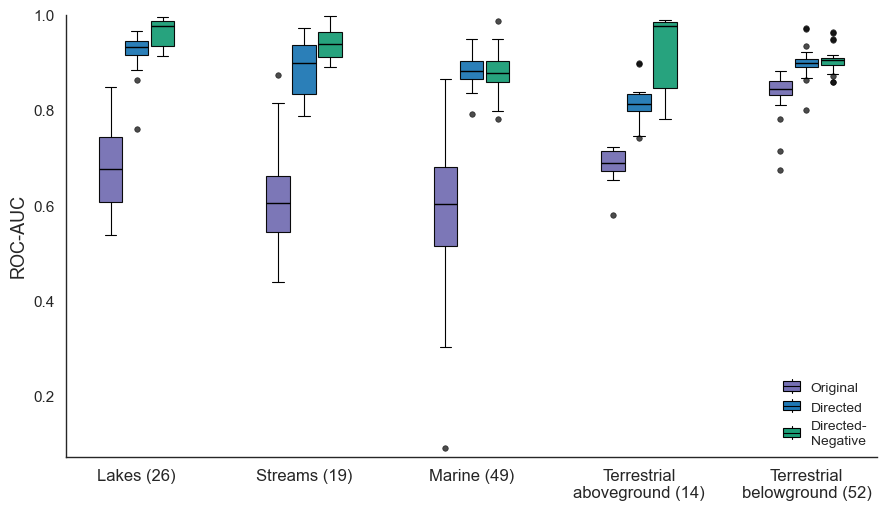


[INFO] Generating figure for metric: PR_AUC
[INFO] Foodwebs in results before filter: 290
[INFO] Foodwebs in results after filter: 160


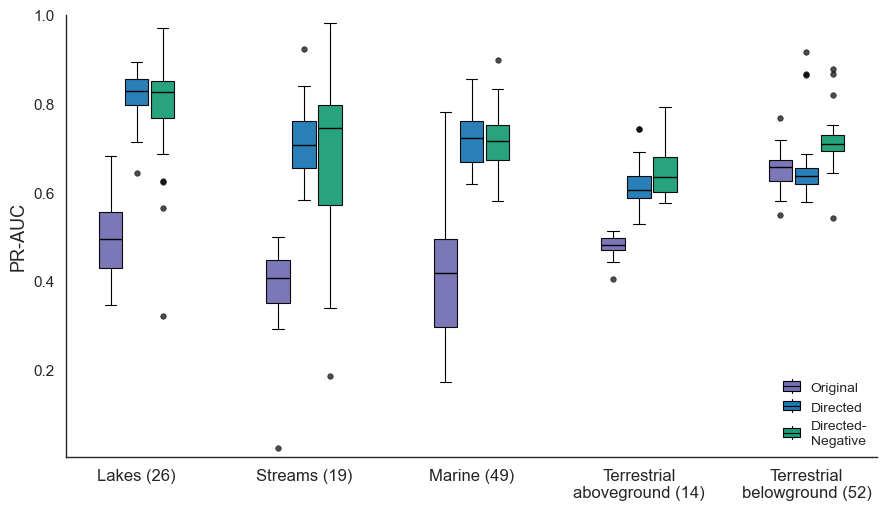


[INFO] Generating figure for metric: Precision
[INFO] Foodwebs in results before filter: 290
[INFO] Foodwebs in results after filter: 160


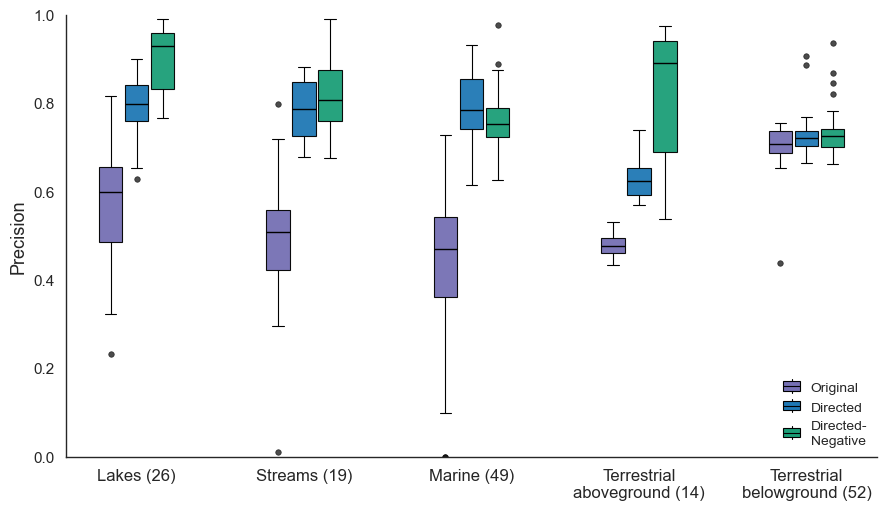


[INFO] Generating figure for metric: Recall
[INFO] Foodwebs in results before filter: 290
[INFO] Foodwebs in results after filter: 160


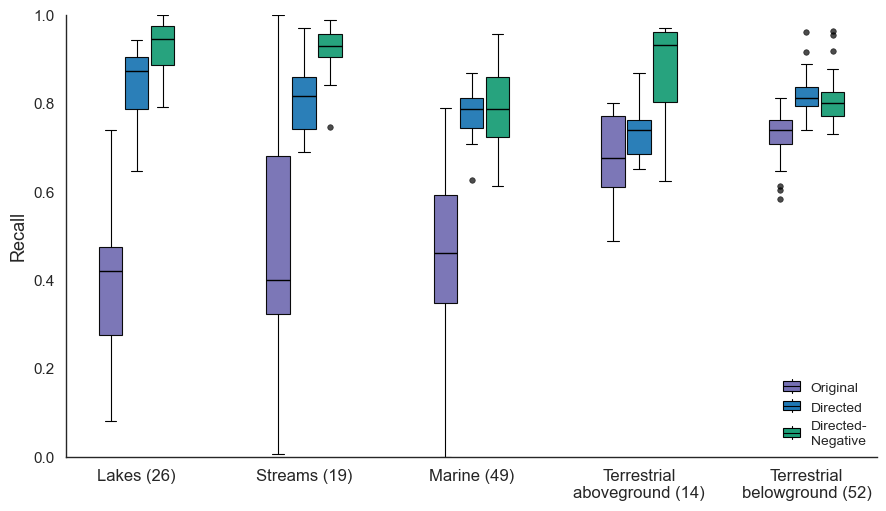


[INFO] Generating figure for metric: F1Score
[INFO] Foodwebs in results before filter: 290
[INFO] Foodwebs in results after filter: 160


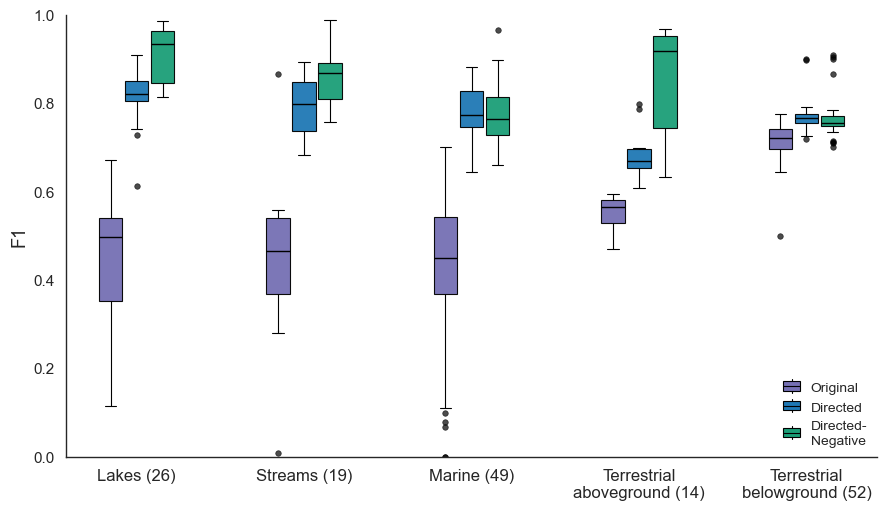


[INFO] Generating figure for metric: PseudoTSS
[INFO] Foodwebs in results before filter: 290
[INFO] Foodwebs in results after filter: 160


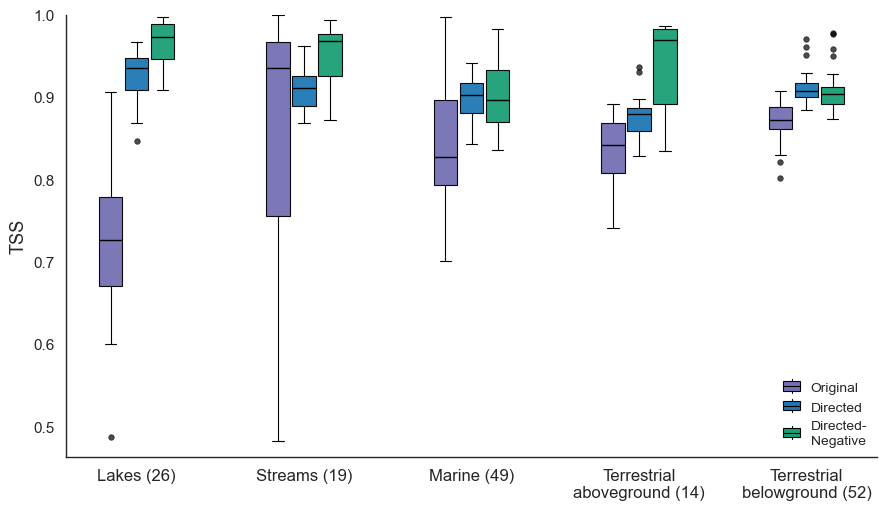


[INFO] Generating figure for metric: PseudoTPR
[INFO] Foodwebs in results before filter: 290
[INFO] Foodwebs in results after filter: 160


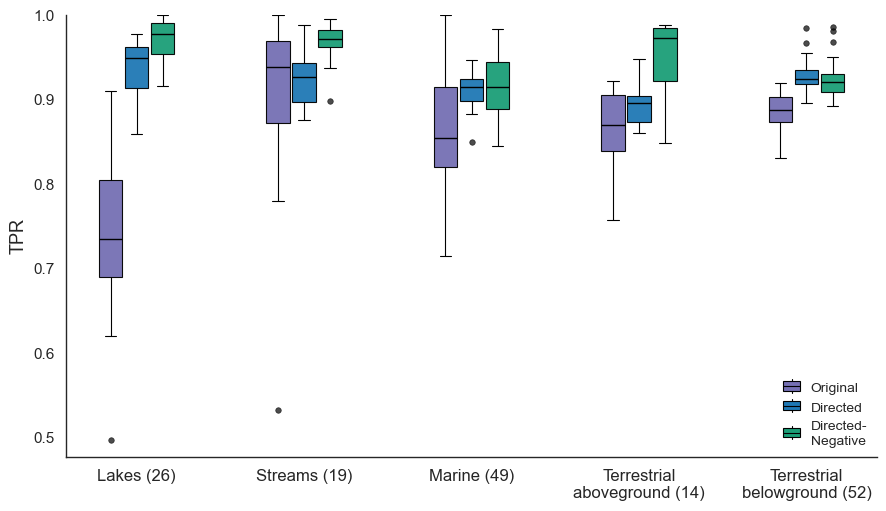

In [15]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib.legend_handler import HandlerBase


# =========================
# Style (match old snippet)
# =========================
sns.set_theme(context="paper", style="white")


# =========================
# Week-15 palettes
# =========================
ecosystem_palette = {
    "Lakes": "#56B4E9",
    "Streams": "#009E73",
    "Marine": "#0072B2",
    "Terrestrial aboveground": "#4DAF4A",
    "Terrestrial belowground": "#A6761D",
}

metric_palette = {
    "ROC-AUC": "#7B3294",
    "PR-AUC": "#C51B7D",
    "Precision": "#FE6100",
    "Recall": "#CAB2D6",
    "F1": "#E6AB02",
    "TSS": "#666666",
    "TPR": "#1B9E77",
}

version_palette = {
    "original": "#7570B3",
    "directed": "#1F78B4",
    "dir_neg": "#1B9E77",
}


# =========================
# Config
# =========================
RESULTS_DIR_ORIGINAL = Path("../../../src/matlab/data/result_wlnm_original_pseudo_properties_k60_evaluate_unseen-false/prediction_scores_logs")
RESULTS_DIR_DIRECTED = Path("../../../src/matlab/data/result_wlnm_directed_pseudo_properties_k60_evaluate_unseen-false/prediction_scores_logs")
RESULTS_DIR_DIR_NEG  = Path("../../../src/matlab/data/result_wlnm_dir_neg_pseudo_properties_k60_evaluate_unseen-false/prediction_scores_logs")

FOODWEB_CSV = Path("../../../src/matlab/data/foodwebs_mat/foodweb_metrics_ecosystem.csv")

METRICS_TO_PLOT = ["ROC_AUC", "PR_AUC", "Precision", "Recall", "F1Score", "PseudoTSS", "PseudoTPR"]
METRIC_LABELS = {
    "ROC_AUC": "ROC-AUC",
    "PR_AUC": "PR-AUC",
    "Precision": "Precision",
    "Recall": "Recall",
    "F1Score": "F1",
    "PseudoTSS": "TSS",
    "PseudoTPR": "TPR",
}

K_TARGET = None
K_COL = "K"
NODES_THRESHOLD = 40

GLOB_PATTERN_ORIGINAL = "*_tax_mass_results_random_wlnm_original.csv"
GLOB_PATTERN_DIRECTED = "*_tax_mass_results_random_wlnm_directed.csv"
GLOB_PATTERN_DIR_NEG  = "*_tax_mass_results_random_wlnm_dir_neg.csv"

Y_PADDING = 0.02
Y_MIN_FLOOR = 0.0
Y_MAX_CAP = 1.0

# This variable is used by load_one_csv()
METRIC = None


# =========================
# Helpers
# =========================
def normalize_fw_label(name: str) -> str:
    name = str(name).strip()
    name, _ = os.path.splitext(name)
    name = name.replace(" ", "_")
    for token in [
        "_results_", "_result_", "_results",
        "_random", "_tax_mass", "_tax", "_mass"
    ]:
        name = name.replace(token, "_")
    return "_".join(part for part in name.split("_") if part)


def parse_foodweb_from_name(fname: str) -> str:
    base = Path(fname).name
    if "_results_" in base:
        return base.split("_results_")[0]
    return Path(fname).stem


def coerce_numeric(df: pd.DataFrame, cols) -> pd.DataFrame:
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df


def format_ecosystem_label(eco: str) -> str:
    eco_clean = str(eco).strip().lower()
    custom_labels = {
        "lakes": "Lakes",
        "streams": "Streams",
        "marine": "Marine",
        "terrestrial aboveground": "Terrestrial\naboveground",
        "terrestrial belowground": "Terrestrial\nbelowground",
    }
    return custom_labels.get(eco_clean, str(eco).strip().capitalize())


def load_one_csv(csv_path: Path, version: str):
    df = pd.read_csv(csv_path)

    if METRIC not in df.columns:
        print(f"[SKIP] Missing metric '{METRIC}': {csv_path.name}")
        return None

    df = coerce_numeric(df, [METRIC, K_COL])

    if K_TARGET is not None and K_COL in df.columns:
        df = df[df[K_COL] == K_TARGET].copy()
        if df.empty:
            return None

    vals = df[METRIC].dropna().values
    if vals.size == 0:
        return None

    out = {
        "Foodweb": parse_foodweb_from_name(csv_path.name),
        "Version": version,
        "n_rows": int(len(df)),
        "file": csv_path.name,
        "folder": str(csv_path.parent),
        f"{METRIC}_mean": float(np.mean(vals)),
    }

    return out


def load_folder(folder: Path, pattern: str, version: str):
    csv_files = sorted(folder.glob(pattern))
    if not csv_files:
        raise FileNotFoundError(
            f"No files found in {folder.resolve()} matching: {pattern}"
        )

    rows = []
    for p in csv_files:
        rec = load_one_csv(p, version=version)
        if rec is not None:
            rows.append(rec)

    return rows


class HandlerMiniBoxplot(HandlerBase):
    def create_artists(
        self, legend, orig_handle,
        xdescent, ydescent, width, height, fontsize, trans
    ):
        facecolor = orig_handle["facecolor"]
        edgecolor = orig_handle.get("edgecolor", "black")
        linewidth = orig_handle.get("linewidth", 0.6)

        y_shift = -0.06 * height
        cx = xdescent + 0.5 * width
        cy = ydescent + 0.5 * height + y_shift

        box_w = 0.8 * width
        box_h = 0.8 * height
        box_x = cx - box_w / 2
        box_y = cy - box_h / 2

        whisk_top_y = box_y + box_h + 0.18 * height
        whisk_bot_y = box_y - 0.18 * height

        box = Rectangle(
            (box_x, box_y),
            box_w,
            box_h,
            facecolor=facecolor,
            edgecolor=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        median = Line2D(
            [box_x, box_x + box_w],
            [cy, cy],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        whisker_top = Line2D(
            [cx, cx],
            [box_y + box_h, whisk_top_y],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        whisker_bottom = Line2D(
            [cx, cx],
            [whisk_bot_y, box_y],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        return [box, median, whisker_top, whisker_bottom]


# =========================
# Load metadata once
# =========================
meta = pd.read_csv(FOODWEB_CSV)
meta.columns = [c.strip() for c in meta.columns]

fw_col = next((c for c in meta.columns if c.lower() == "foodweb"), None)
nodes_col = next((c for c in meta.columns if c.lower() == "nodes"), None)
eco_col = next(
    (c for c in meta.columns if c.lower() in ["ecosystemtype", "ecosystem", "ecosystem_type"]),
    None
)

if fw_col is None or nodes_col is None or eco_col is None:
    raise ValueError("Could not find 'Foodweb', 'Nodes', and 'EcosystemType' columns in FOODWEB_CSV.")

meta["FW_KEY"] = meta[fw_col].apply(normalize_fw_label)

meta_filtered = meta.loc[
    meta[nodes_col] >= NODES_THRESHOLD,
    ["FW_KEY", eco_col, nodes_col]
].copy()
meta_filtered = meta_filtered.rename(columns={eco_col: "EcosystemType"})
meta_filtered["EcosystemType"] = meta_filtered["EcosystemType"].astype(str).str.strip()

allowed_fw_keys = set(meta_filtered["FW_KEY"].unique())
print(f"[INFO] Foodwebs with Nodes >= {NODES_THRESHOLD}: {len(allowed_fw_keys)}")


# =========================
# Generate one figure per metric
# =========================
for METRIC in METRICS_TO_PLOT:
    print(f"\n[INFO] Generating figure for metric: {METRIC}")

    # =========================
    # Load all CSVs (three folders)
    # =========================
    rows = []
    rows += load_folder(RESULTS_DIR_ORIGINAL, GLOB_PATTERN_ORIGINAL, version="original")
    rows += load_folder(RESULTS_DIR_DIRECTED, GLOB_PATTERN_DIRECTED, version="directed")
    rows += load_folder(RESULTS_DIR_DIR_NEG,  GLOB_PATTERN_DIR_NEG,  version="dir_neg")

    df_all = pd.DataFrame(rows)

    if df_all.empty:
        print(f"[WARNING] No valid rows for metric {METRIC}. Skipping.")
        continue

    # =========================
    # Apply NODE_THRESHOLD + EcosystemType logic
    # =========================
    df_all["FW_KEY"] = df_all["Foodweb"].apply(normalize_fw_label)

    print(f"[INFO] Foodwebs in results before filter: {df_all['FW_KEY'].nunique()}")

    df_all = df_all[df_all["FW_KEY"].isin(allowed_fw_keys)].copy()

    print(f"[INFO] Foodwebs in results after filter: {df_all['Foodweb'].nunique()}")

    if df_all.empty:
        print(f"[WARNING] No foodwebs left after filtering for metric {METRIC}. Skipping.")
        continue

    # Merge ecosystem type into results
    df_all = df_all.merge(
        meta_filtered[["FW_KEY", "EcosystemType"]].drop_duplicates(),
        on="FW_KEY",
        how="left"
    )

    if df_all["EcosystemType"].isna().all():
        print(f"[WARNING] EcosystemType merge failed for metric {METRIC}. Skipping.")
        continue

    # =========================
    # One row per Foodweb per Version
    # =========================
    ycol = f"{METRIC}_mean"
    df_all = (
        df_all
        .groupby(["FW_KEY", "Foodweb", "Version", "EcosystemType"], as_index=False)[[ycol]]
        .mean()
    )

    # =========================
    # Ecosystem order + labels
    # =========================
    preferred_ecosystem_order = [
        "lakes",
        "streams",
        "marine",
        "terrestrial aboveground",
        "terrestrial belowground",
    ]

    ecosystems_present = (
        df_all["EcosystemType"]
        .dropna()
        .astype(str)
        .str.strip()
        .drop_duplicates()
        .tolist()
    )

    eco_lookup = {eco.lower(): eco for eco in ecosystems_present}

    ecosystem_order = [
        eco_lookup[eco]
        for eco in preferred_ecosystem_order
        if eco in eco_lookup
    ]

    ecosystem_order += [
        eco for eco in ecosystems_present
        if eco.lower() not in set(preferred_ecosystem_order)
    ]

    labels_map = (
        df_all[["FW_KEY", "EcosystemType"]]
        .drop_duplicates()
        .groupby("EcosystemType")["FW_KEY"]
        .nunique()
        .to_dict()
    )
    labels_map = {
        eco: f"{format_ecosystem_label(eco)} ({n})"
        for eco, n in labels_map.items()
    }

    # =========================
    # Plot: single-panel grouped boxplot by ecosystem
    # =========================
    version_order = ["original", "directed", "dir_neg"]
    version_labels = {
        "original": "Original",
        "directed": "Directed",
        "dir_neg": "Directed-\nNegative",
    }

    fig, ax = plt.subplots(figsize=(9, 5.2))

    # Base x positions for ecosystem groups
    group_gap = 1.8
    group_centers = 1.0 + np.arange(len(ecosystem_order)) * group_gap

    # 3 versions inside each ecosystem group
    offsets = np.linspace(-0.28, 0.28, len(version_order))
    box_width = 0.25

    for j, version in enumerate(version_order):
        data_for_version = []
        positions_for_version = []

        for i, eco in enumerate(ecosystem_order):
            vals = (
                pd.to_numeric(
                    df_all.loc[
                        (df_all["EcosystemType"] == eco) &
                        (df_all["Version"] == version),
                        ycol
                    ],
                    errors="coerce"
                )
                .dropna()
                .to_numpy()
                .ravel()
            )

            if vals.size == 0:
                continue

            data_for_version.append(vals)
            positions_for_version.append(float(group_centers[i] + offsets[j]))

        if not data_for_version:
            continue

        if len(data_for_version) != len(positions_for_version):
            print(
                f"[SKIP] {version}: "
                f"{len(data_for_version)=} != {len(positions_for_version)=}"
            )
            continue

        ax.boxplot(
            data_for_version,
            positions=positions_for_version,
            widths=box_width,
            patch_artist=True,
            manage_ticks=False,
            showfliers=True,
            boxprops=dict(
                facecolor=version_palette[version],
                edgecolor="black",
                linewidth=0.8,
                alpha=0.95,
            ),
            medianprops=dict(color="black", linewidth=1.0),
            whiskerprops=dict(color="black", linewidth=0.8),
            capprops=dict(color="black", linewidth=0.8),
            flierprops=dict(
                marker="o",
                markersize=4,
                markerfacecolor="black",
                markeredgecolor="black",
                markeredgewidth=0.5,
                alpha=0.7,
            ),
        )

    legend_handles = [
        {
            "facecolor": version_palette[v],
            "edgecolor": "black",
            "linewidth": 0.8,
        }
        for v in version_order
    ]

    # Add horizontal padding so outer boxplots do not touch borders
    x_padding = 0.35
    left_edge = group_centers[0] + offsets.min() - box_width / 2
    right_edge = group_centers[-1] + offsets.max() + box_width / 2
    ax.set_xlim(left_edge - x_padding, right_edge + x_padding)

    panel_vals = pd.to_numeric(df_all[ycol], errors="coerce").dropna()
    local_min = max(Y_MIN_FLOOR, panel_vals.min() - Y_PADDING)
    local_max = min(Y_MAX_CAP, panel_vals.max() + Y_PADDING)

    if np.isclose(local_min, local_max):
        local_min = max(Y_MIN_FLOOR, local_min - 0.02)
        local_max = min(Y_MAX_CAP, local_max + 0.02)

    ax.set_ylim(local_min, local_max)

    ax.set_xticks(group_centers)
    ax.set_xticklabels(
        [labels_map.get(eco, format_ecosystem_label(eco)) for eco in ecosystem_order],
        rotation=0,
        fontsize=12,
    )

    ax.set_ylabel(METRIC_LABELS.get(METRIC, METRIC), fontsize=13)
    ax.set_xlabel("")
    ax.tick_params(axis="y", labelsize=11)

    ax.grid(False, axis="x")
    sns.despine(ax=ax)

    ax.legend(
        handles=legend_handles,
        labels=[version_labels[v] for v in version_order],
        handler_map={dict: HandlerMiniBoxplot()},
        loc="lower right",
        frameon=False,
        fontsize=10,
        handlelength=1.5,
        handleheight=0.9,
        handletextpad=0.6,
        borderpad=0.2,
        labelspacing=0.45,
    )

    plt.tight_layout()
    plt.show()

[INFO] Foodwebs with Nodes >= 40: 160
[INFO] Foodwebs in results before filter: 290
[INFO] Foodwebs in results after filter: 160
[INFO] Ecosystems detected: ['lakes', 'marine', 'streams', 'terrestrial aboveground', 'terrestrial belowground']


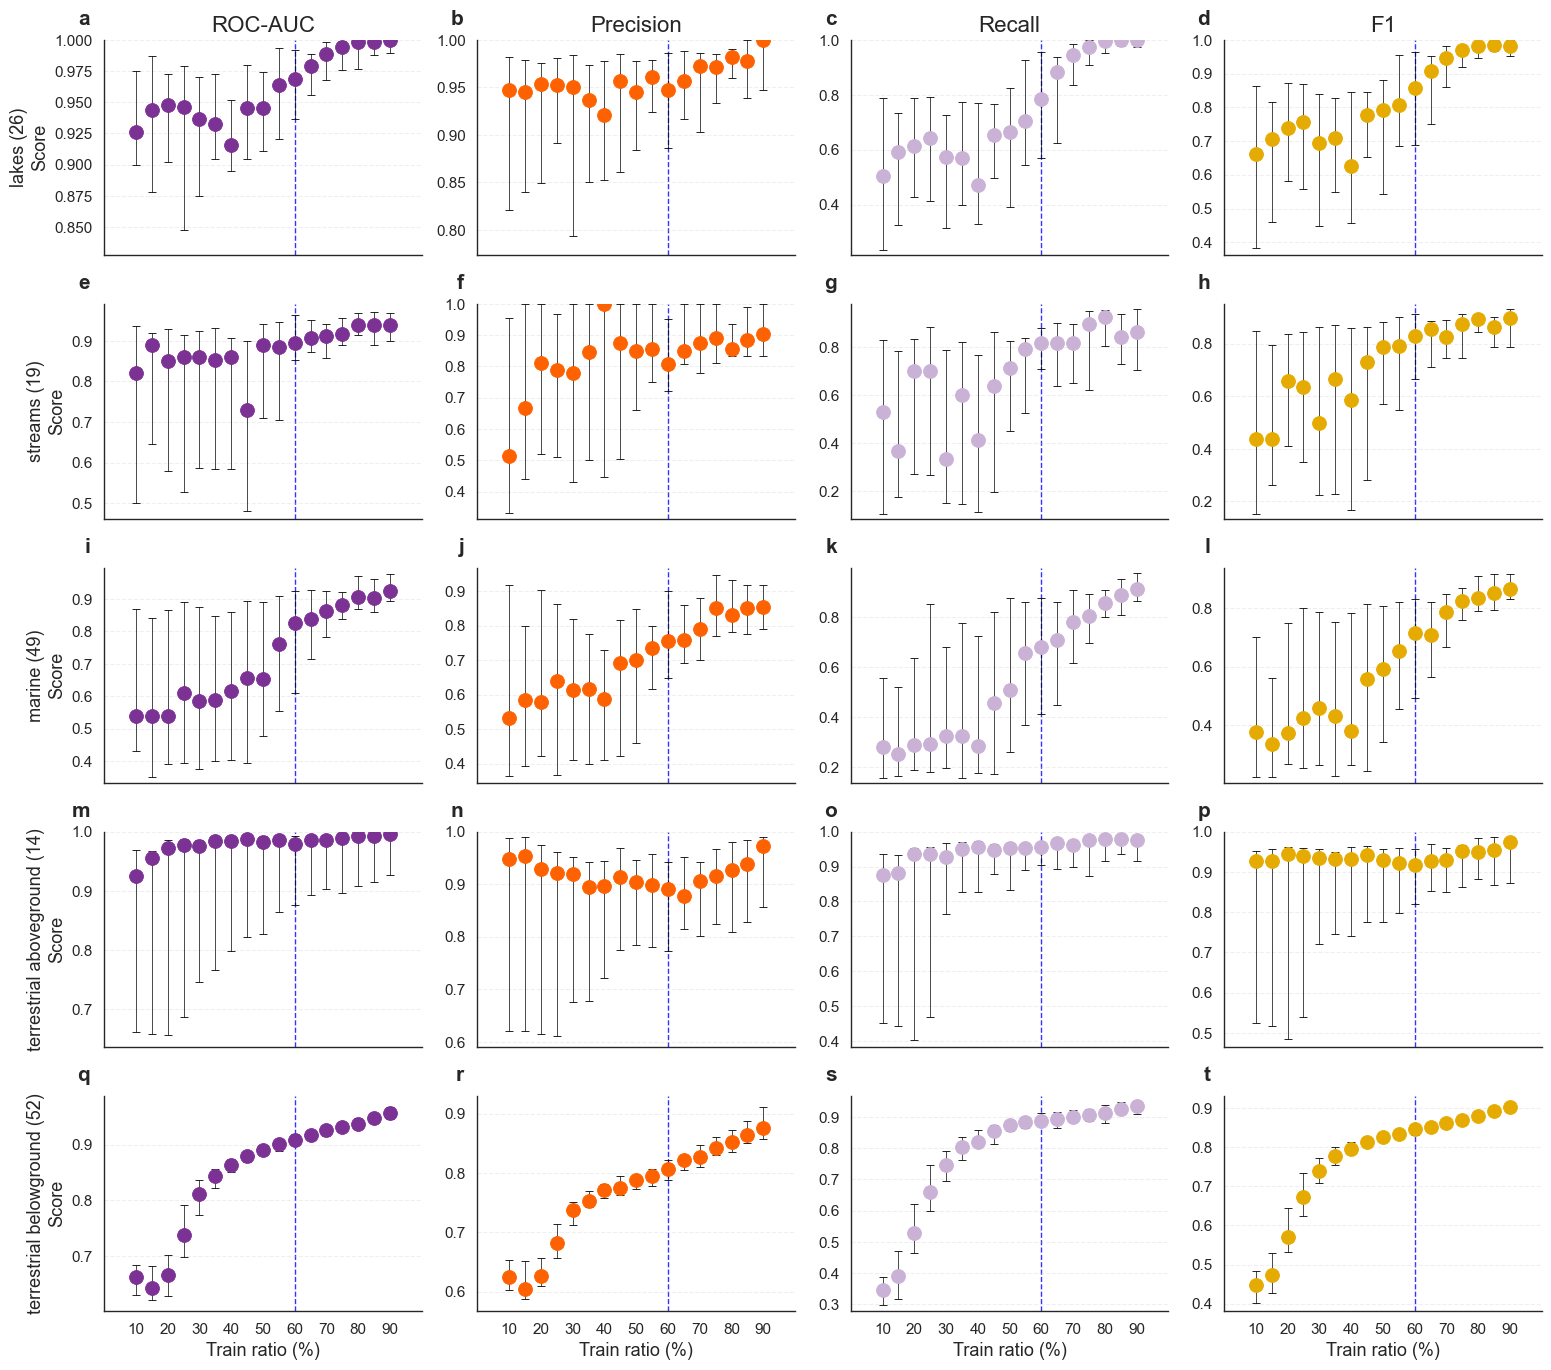

In [ ]:
import os
import glob
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_context("paper")
sns.set_style("white")

# =========================
# Configuration
# =========================
RESULTS_DIR = "../../../src/matlab/data/result_sweep_train_ratios_10-90/prediction_scores_logs/"
FOODWEB_CSV = "../../../src/matlab/data/foodwebs_mat/foodweb_metrics_ecosystem.csv"
SINGLE_FILE = None
METRICS = ["AUC", "Precision", "Recall", "F1Score"]

# Display labels only
METRIC_LABELS = {
    "AUC": "ROC-AUC",
    "Precision": "Precision",
    "Recall": "Recall",
    "F1Score": "F1",
}

MAX_PLOTS = None
NODES_THRESHOLD = 40
SHOW_GRID = True
Y_MIN = 0

# New: independent y-axis zoom
INDEPENDENT_Y = True
Y_PADDING = 0.02
Y_MAX_CAP = 1.0

# =========================
# Helpers
# =========================
def normalize_fw_label(name: str) -> str:
    name = str(name).strip()
    name, _ = os.path.splitext(name)
    name = name.replace(" ", "_")
    for token in ["_results_", "_result_", "_results", "_random", "_tax_mass", "_tax", "_mass"]:
        name = name.replace(token, "_")
    return "_".join(part for part in name.split("_") if part)


def derive_foodweb_from_filename(path: str) -> str:
    return normalize_fw_label(os.path.basename(path))


def load_results(results_dir=None, single_file=None, max_plots=None) -> pd.DataFrame:
    paths = []

    if results_dir and os.path.isdir(results_dir):
        paths.extend(sorted(glob.glob(os.path.join(results_dir, "*.csv"))))

    if single_file and os.path.isfile(single_file):
        paths.append(single_file)

    if not paths:
        raise FileNotFoundError("No CSV files found. Check RESULTS_DIR or SINGLE_FILE.")

    if max_plots is not None:
        paths = paths[:max_plots]
        print(f"[INFO] Limiting to first {len(paths)} CSV files.")

    frames = []
    for path in paths:
        try:
            df = pd.read_csv(path)
        except Exception as e:
            print(f"[WARNING] Skipping {path}: {e}")
            continue

        df.columns = [c.strip() for c in df.columns]
        df = df.rename(columns={c: c.upper() for c in df.columns})

        if "FOODWEB" not in df.columns:
            df["FOODWEB"] = derive_foodweb_from_filename(path)

        frames.append(df)

    if not frames:
        raise ValueError("No valid results loaded.")

    return pd.concat(frames, ignore_index=True)


def get_trainratio_column(columns):
    candidates = [c for c in columns if c.lower() in ["trainratio", "ratiotrain", "train_ratio"]]
    if not candidates:
        raise ValueError("No TrainRatio column found.")
    return candidates[0]


def set_trainratio_ticks(ax, train_ratios):
    ax.set_xticks(train_ratios)
    ax.set_xticklabels([str(t) if t % 10 == 0 else "" for t in train_ratios])


# =========================
# Load and filter data
# =========================
df = load_results(
    results_dir=RESULTS_DIR,
    single_file=SINGLE_FILE,
    max_plots=MAX_PLOTS,
)

meta = pd.read_csv(FOODWEB_CSV)
meta.columns = [c.strip() for c in meta.columns]

fw_col = next((c for c in meta.columns if c.lower() == "foodweb"), None)
nodes_col = next((c for c in meta.columns if c.lower() == "nodes"), None)

ecosystem_col = next(
    (c for c in meta.columns if c.lower() in ["ecosystem", "ecosystemtype", "ecosystem_type"]),
    None
)

if fw_col is None or nodes_col is None or ecosystem_col is None:
    raise ValueError(
        "Could not find 'Foodweb', 'Nodes', and ecosystem columns in FOODWEB_CSV."
    )

meta["FW_KEY"] = meta[fw_col].apply(normalize_fw_label)
df["FW_KEY"] = df["FOODWEB"].apply(normalize_fw_label)

meta_filtered = meta.loc[meta[nodes_col] > NODES_THRESHOLD, ["FW_KEY", ecosystem_col]].copy()
meta_filtered = meta_filtered.rename(columns={ecosystem_col: "ECOSYSTEM"})
meta_filtered["ECOSYSTEM"] = meta_filtered["ECOSYSTEM"].astype(str).str.strip()

allowed_fw_keys = set(meta_filtered["FW_KEY"].unique())

print(f"[INFO] Foodwebs with Nodes > {NODES_THRESHOLD}: {len(allowed_fw_keys)}")
print(f"[INFO] Foodwebs in results before filter: {df['FW_KEY'].nunique()}")

df = df[df["FW_KEY"].isin(allowed_fw_keys)].copy()

# Merge ecosystem into results
df = df.merge(meta_filtered, on="FW_KEY", how="left")

print(f"[INFO] Foodwebs in results after filter: {df['FOODWEB'].nunique()}")
print(f"[INFO] Ecosystems detected: {sorted(df['ECOSYSTEM'].dropna().unique().tolist())}")

if df.empty:
    raise ValueError(f"No foodwebs left after filtering Nodes > {NODES_THRESHOLD}.")

# =========================
# Normalize TRAINRATIO
# =========================
trainratio_col = get_trainratio_column(df.columns)
df["TRAINRATIO"] = pd.to_numeric(df[trainratio_col], errors="coerce")
df = df.dropna(subset=["TRAINRATIO"]).copy()

if df["TRAINRATIO"].between(0, 1).all():
    df["TRAINRATIO"] = (df["TRAINRATIO"] * 100).round().astype(int)
else:
    df["TRAINRATIO"] = df["TRAINRATIO"].astype(int)

# =========================
# Long format
# =========================
metrics_present = [m for m in METRICS if m.upper() in df.columns]
if not metrics_present:
    raise ValueError("None of the requested metrics were found.")

df_long = pd.concat(
    [
        df[["FOODWEB", "ECOSYSTEM", "TRAINRATIO", metric.upper()]]
        .rename(columns={metric.upper(): "Value"})
        .assign(Metric=metric)
        for metric in metrics_present
    ],
    ignore_index=True,
)

# Mean per food web, ecosystem, train ratio, and metric
df_web_means = (
    df_long
    .groupby(["FOODWEB", "ECOSYSTEM", "TRAINRATIO", "Metric"], as_index=False)["Value"]
    .mean()
)

# =========================
# Summary for plotting
# =========================
summary = (
    df_web_means
    .groupby(["ECOSYSTEM", "TRAINRATIO", "Metric"])["Value"]
    .agg(
        median="median",
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
        n_webs="count",
    )
    .reset_index()
)

train_ratios = sorted(df_web_means["TRAINRATIO"].unique().tolist())
n_webs = df_web_means["FOODWEB"].nunique()

# Define preferred order for ecosystems
preferred_ecosystem_order = [
    "lakes",
    "streams",
    "marine",
    "terrestrial aboveground",
    "terrestrial belowground",
]

ecosystems_present = summary["ECOSYSTEM"].dropna().unique().tolist()

ecosystem_order = [e for e in preferred_ecosystem_order if e in ecosystems_present]

# fallback: append any unmatched ecosystem names
ecosystem_order += [e for e in ecosystems_present if e not in ecosystem_order]

metric_colors = {
    "AUC": "#7B3294",        # ROC-AUC
    "Precision": "#FE6100",  # Precision
    "Recall": "#CAB2D6",     # Recall
    "F1Score": "#E6AB02",    # F1
}

ecosystem_display_labels = {
    "lakes": "Lakes",
    "streams": "Streams",
    "marine": "Marine",
    "terrestrial aboveground": "Terrestrial aboveground",
    "terrestrial belowground": "Terrestrial belowground",
}

# =========================
# Final plot: ecosystems x metrics
# Rows = ecosystems, Columns = metrics
# =========================
n_rows = len(ecosystem_order)
n_cols = len(metrics_present)

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(16, 14),
    sharex=True,
    sharey=not INDEPENDENT_Y
)

# Make axes always 2D
if n_rows == 1:
    axes = np.array([axes])
if n_cols == 1:
    axes = axes[:, np.newaxis]

panel_letters = list("abcdefghijklmnopqrst")
letter_idx = 0

for r, ecosystem in enumerate(ecosystem_order):
    for c, metric in enumerate(metrics_present):
        ax = axes[r, c]

        sub = summary[
            (summary["ECOSYSTEM"] == ecosystem) &
            (summary["Metric"] == metric)
        ].sort_values("TRAINRATIO")

        if sub.empty:
            ax.set_axis_off()
            continue

        x = sub["TRAINRATIO"].to_numpy()
        y = sub["median"].to_numpy()
        yerr = np.vstack([
            (sub["median"] - sub["q25"]).to_numpy(),
            (sub["q75"] - sub["median"]).to_numpy(),
        ])

        color = metric_colors[metric]

        ax.errorbar(
            x,
            y,
            yerr=yerr,
            fmt="o",
            linestyle="none",
            color=color,
            ecolor="black",
            markersize=10,
            linewidth=1.2,
            elinewidth=0.5,
            capsize=3,
            capthick=0.8,
            markerfacecolor=color,
            markeredgecolor=color,
            markeredgewidth=0.6,
        )

        # Vertical reference line at train ratio = 60
        ax.axvline(
            x=60,
            color="blue",
            linestyle="--",
            linewidth=1.0,
            alpha=0.8,
            zorder=0,
        )

        # Independent y zoom per panel
        if INDEPENDENT_Y:
            local_min = max(Y_MIN, sub["q25"].min() - Y_PADDING)
            local_max = min(Y_MAX_CAP, sub["q75"].max() + Y_PADDING)

            if np.isclose(local_min, local_max):
                local_min = max(Y_MIN, local_min - 0.02)
                local_max = min(Y_MAX_CAP, local_max + 0.02)

            ax.set_ylim(local_min, local_max)
        else:
            ax.set_ylim(Y_MIN, 1.0)

        if SHOW_GRID:
            ax.grid(True, axis="y", linestyle="--", alpha=0.30)
        else:
            ax.grid(False)

        set_trainratio_ticks(ax, train_ratios)
        sns.despine(ax=ax)

        # Column titles only on first row
        if r == 0:
            ax.set_title(METRIC_LABELS.get(metric, metric), fontsize=16)

        # Row labels only on first column
        if c == 0:
            n_ecosystem_webs = df_web_means.loc[
                df_web_means["ECOSYSTEM"] == ecosystem, "FOODWEB"
            ].nunique()
            display_ecosystem = ecosystem_display_labels.get(ecosystem, ecosystem)
            ax.set_ylabel(f"{display_ecosystem} ({n_ecosystem_webs})\nScore", fontsize=13)

        # x label only on bottom row
        if r == n_rows - 1:
            ax.set_xlabel("Train ratio (%)", fontsize=13)

        # Panel letters
        if letter_idx < len(panel_letters):
            ax.annotate(
                panel_letters[letter_idx],
                xy=(0, 1),
                xycoords="axes fraction",
                xytext=(-10, 8),
                textcoords="offset points",
                ha="right",
                va="bottom",
                fontsize=15,
                fontweight="bold",
                annotation_clip=False,
            )
            letter_idx += 1

        ax.tick_params(axis="both", labelsize=11)
        ax.set_xlim(min(train_ratios) - 10, max(train_ratios) + 10)

fig.tight_layout(rect=[0.03, 0, 1, 0.985])
plt.show()

[INFO] Foodwebs with Nodes >= 40: 160
[INFO] Foodwebs in results before filter: 290
[INFO] Foodwebs in results after filter: 160
[INFO] Ecosystems detected: ['lakes', 'marine', 'streams', 'terrestrial aboveground', 'terrestrial belowground']
[INFO] Foodwebs used in final plot: 160


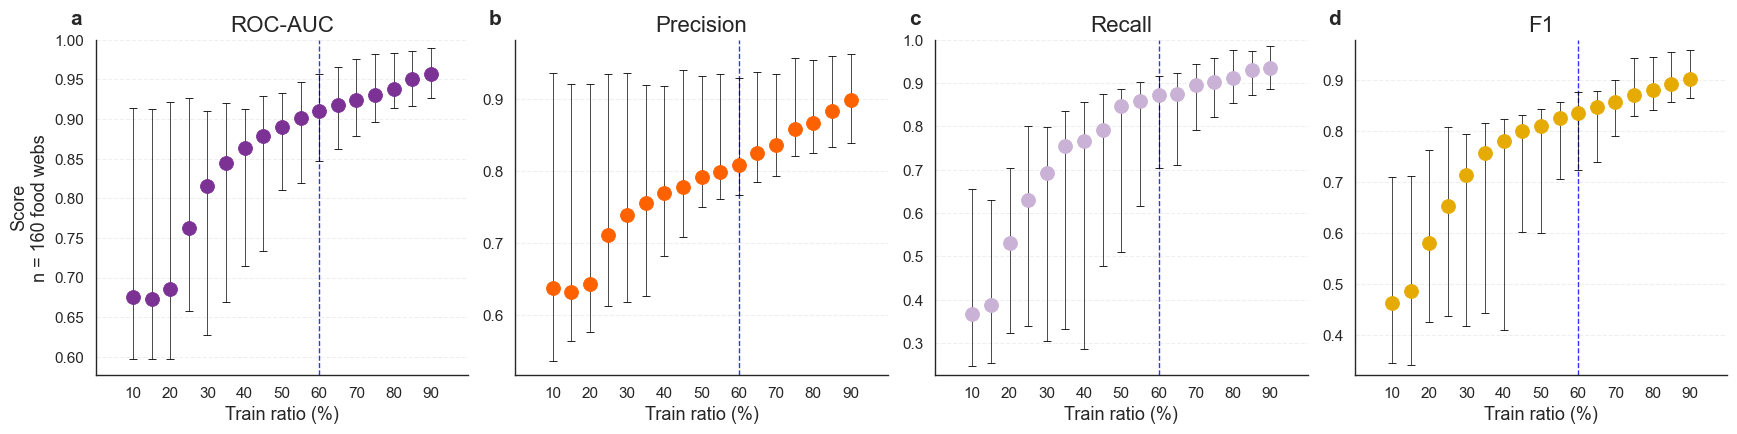

In [11]:
import os
import glob
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_context("paper")
sns.set_style("white")

# =========================
# Configuration
# =========================
RESULTS_DIR = "../../../src/matlab/data/result_sweep_train_ratios_10-90/prediction_scores_logs/"
FOODWEB_CSV = "../../../src/matlab/data/foodwebs_mat/foodweb_metrics_ecosystem.csv"
SINGLE_FILE = None
METRICS = ["AUC", "Precision", "Recall", "F1Score"]

# Display labels only
METRIC_LABELS = {
    "AUC": "ROC-AUC",
    "Precision": "Precision",
    "Recall": "Recall",
    "F1Score": "F1",
}

MAX_PLOTS = None
NODES_THRESHOLD = 40
SHOW_GRID = True
Y_MIN = 0

# New: independent y-axis zoom
INDEPENDENT_Y = True
Y_PADDING = 0.02
Y_MAX_CAP = 1.0

metric_palette = {
    "ROC-AUC": "#7B3294",   # purple
    "PR-AUC": "#C51B7D",    # magenta
    "Precision": "#FE6100", # orange
    "Recall": "#CAB2D6",    # violet
    "F1": "#E6AB02",        # mustard
    "TSS": "#666666",       # dark gray
    "TPR": "#1B9E77",       # teal-green
}

# =========================
# Helpers
# =========================
def normalize_fw_label(name: str) -> str:
    name = str(name).strip()
    name, _ = os.path.splitext(name)
    name = name.replace(" ", "_")
    for token in ["_results_", "_result_", "_results", "_random", "_tax_mass", "_tax", "_mass"]:
        name = name.replace(token, "_")
    return "_".join(part for part in name.split("_") if part)


def derive_foodweb_from_filename(path: str) -> str:
    return normalize_fw_label(os.path.basename(path))


def load_results(results_dir=None, single_file=None, max_plots=None) -> pd.DataFrame:
    paths = []

    if results_dir and os.path.isdir(results_dir):
        paths.extend(sorted(glob.glob(os.path.join(results_dir, "*.csv"))))

    if single_file and os.path.isfile(single_file):
        paths.append(single_file)

    if not paths:
        raise FileNotFoundError("No CSV files found. Check RESULTS_DIR or SINGLE_FILE.")

    if max_plots is not None:
        paths = paths[:max_plots]
        print(f"[INFO] Limiting to first {len(paths)} CSV files.")

    frames = []
    for path in paths:
        try:
            df = pd.read_csv(path)
        except Exception as e:
            print(f"[WARNING] Skipping {path}: {e}")
            continue

        df.columns = [c.strip() for c in df.columns]
        df = df.rename(columns={c: c.upper() for c in df.columns})

        if "FOODWEB" not in df.columns:
            df["FOODWEB"] = derive_foodweb_from_filename(path)

        frames.append(df)

    if not frames:
        raise ValueError("No valid results loaded.")

    return pd.concat(frames, ignore_index=True)


def get_trainratio_column(columns):
    candidates = [c for c in columns if c.lower() in ["trainratio", "ratiotrain", "train_ratio"]]
    if not candidates:
        raise ValueError("No TrainRatio column found.")
    return candidates[0]


def set_trainratio_ticks(ax, train_ratios):
    ax.set_xticks(train_ratios)
    ax.set_xticklabels([str(t) if t % 10 == 0 else "" for t in train_ratios])


# =========================
# Load and filter data
# =========================
df = load_results(
    results_dir=RESULTS_DIR,
    single_file=SINGLE_FILE,
    max_plots=MAX_PLOTS,
)

meta = pd.read_csv(FOODWEB_CSV)
meta.columns = [c.strip() for c in meta.columns]

fw_col = next((c for c in meta.columns if c.lower() == "foodweb"), None)
nodes_col = next((c for c in meta.columns if c.lower() == "nodes"), None)

ecosystem_col = next(
    (c for c in meta.columns if c.lower() in ["ecosystem", "ecosystemtype", "ecosystem_type"]),
    None
)

if fw_col is None or nodes_col is None or ecosystem_col is None:
    raise ValueError(
        "Could not find 'Foodweb', 'Nodes', and ecosystem columns in FOODWEB_CSV."
    )

meta["FW_KEY"] = meta[fw_col].apply(normalize_fw_label)
df["FW_KEY"] = df["FOODWEB"].apply(normalize_fw_label)

meta_filtered = meta.loc[meta[nodes_col] >= NODES_THRESHOLD, ["FW_KEY", ecosystem_col]].copy()
meta_filtered = meta_filtered.rename(columns={ecosystem_col: "ECOSYSTEM"})
meta_filtered["ECOSYSTEM"] = meta_filtered["ECOSYSTEM"].astype(str).str.strip()

allowed_fw_keys = set(meta_filtered["FW_KEY"].unique())

print(f"[INFO] Foodwebs with Nodes >= {NODES_THRESHOLD}: {len(allowed_fw_keys)}")
print(f"[INFO] Foodwebs in results before filter: {df['FW_KEY'].nunique()}")

df = df[df["FW_KEY"].isin(allowed_fw_keys)].copy()

# Merge ecosystem into results
df = df.merge(meta_filtered, on="FW_KEY", how="left")

print(f"[INFO] Foodwebs in results after filter: {df['FOODWEB'].nunique()}")
print(f"[INFO] Ecosystems detected: {sorted(df['ECOSYSTEM'].dropna().unique().tolist())}")

if df.empty:
    raise ValueError(f"No foodwebs left after filtering Nodes >= {NODES_THRESHOLD}.")

# =========================
# Normalize TRAINRATIO
# =========================
trainratio_col = get_trainratio_column(df.columns)
df["TRAINRATIO"] = pd.to_numeric(df[trainratio_col], errors="coerce")
df = df.dropna(subset=["TRAINRATIO"]).copy()

if df["TRAINRATIO"].between(0, 1).all():
    df["TRAINRATIO"] = (df["TRAINRATIO"] * 100).round().astype(int)
else:
    df["TRAINRATIO"] = df["TRAINRATIO"].astype(int)

# =========================
# Long format
# =========================
metrics_present = [m for m in METRICS if m.upper() in df.columns]
if not metrics_present:
    raise ValueError("None of the requested metrics were found.")

df_long = pd.concat(
    [
        df[["FOODWEB", "ECOSYSTEM", "TRAINRATIO", metric.upper()]]
        .rename(columns={metric.upper(): "Value"})
        .assign(Metric=metric)
        for metric in metrics_present
    ],
    ignore_index=True,
)

# Mean per food web, train ratio, and metric
# No ecosystem split: each food web contributes one mean value per train ratio and metric
df_web_means = (
    df_long
    .groupby(["FOODWEB", "TRAINRATIO", "Metric"], as_index=False)["Value"]
    .mean()
)

# =========================
# Summary for plotting
# =========================
summary = (
    df_web_means
    .groupby(["TRAINRATIO", "Metric"])["Value"]
    .agg(
        median="median",
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
        n_webs="count",
    )
    .reset_index()
)

train_ratios = sorted(df_web_means["TRAINRATIO"].unique().tolist())
n_webs = df_web_means["FOODWEB"].nunique()

print(f"[INFO] Foodwebs used in final plot: {n_webs}")

# Consistent metric colors
metric_colors = {
    metric: metric_palette[METRIC_LABELS.get(metric, metric)]
    for metric in metrics_present
}

# =========================
# Final plot: 1 row x 4 metric panels
# Columns = metrics
# =========================
n_cols = len(metrics_present)

fig, axes = plt.subplots(
    1, n_cols,
    figsize=(18, 4.5),
    sharex=True,
    sharey=not INDEPENDENT_Y
)

# Make axes always iterable
if n_cols == 1:
    axes = np.array([axes])

panel_letters = list("abcd")

for c, metric in enumerate(metrics_present):
    ax = axes[c]

    sub = summary[
        summary["Metric"] == metric
    ].sort_values("TRAINRATIO")

    if sub.empty:
        ax.set_axis_off()
        continue

    x = sub["TRAINRATIO"].to_numpy()
    y = sub["median"].to_numpy()
    yerr = np.vstack([
        (sub["median"] - sub["q25"]).to_numpy(),
        (sub["q75"] - sub["median"]).to_numpy(),
    ])

    color = metric_colors[metric]

    ax.errorbar(
        x,
        y,
        yerr=yerr,
        fmt="o",
        linestyle="none",
        color=color,
        ecolor="black",
        markersize=10,
        linewidth=1.2,
        elinewidth=0.5,
        capsize=3,
        capthick=0.8,
        markerfacecolor=color,
        markeredgecolor=color,
        markeredgewidth=0.6,
    )

    # Vertical reference line at train ratio = 60
    ax.axvline(
        x=60,
        color="blue",
        linestyle="--",
        linewidth=1.0,
        alpha=0.8,
        zorder=0,
    )

    # Independent y zoom per panel
    if INDEPENDENT_Y:
        local_min = max(Y_MIN, sub["q25"].min() - Y_PADDING)
        local_max = min(Y_MAX_CAP, sub["q75"].max() + Y_PADDING)

        if np.isclose(local_min, local_max):
            local_min = max(Y_MIN, local_min - 0.02)
            local_max = min(Y_MAX_CAP, local_max + 0.02)

        ax.set_ylim(local_min, local_max)
    else:
        ax.set_ylim(Y_MIN, 1.0)

    if SHOW_GRID:
        ax.grid(True, axis="y", linestyle="--", alpha=0.30)
    else:
        ax.grid(False)

    set_trainratio_ticks(ax, train_ratios)
    sns.despine(ax=ax)

    ax.set_title(METRIC_LABELS.get(metric, metric), fontsize=16)
    ax.set_xlabel("Train ratio (%)", fontsize=13)

    if c == 0:
        ax.set_ylabel(f"Score\nn = {n_webs} food webs", fontsize=13)
    else:
        ax.set_ylabel("")

    # Panel letters
    if c < len(panel_letters):
        ax.annotate(
            panel_letters[c],
            xy=(0, 1),
            xycoords="axes fraction",
            xytext=(-10, 8),
            textcoords="offset points",
            ha="right",
            va="bottom",
            fontsize=15,
            fontweight="bold",
            annotation_clip=False,
        )

    ax.tick_params(axis="both", labelsize=11)
    ax.set_xlim(min(train_ratios) - 10, max(train_ratios) + 10)

fig.tight_layout(rect=[0.03, 0, 1, 0.985])
plt.show()

[INFO] Foodwebs with Nodes >= 40: 160
[INFO] Foodwebs in results before filter: 290
[INFO] Foodwebs in results after filter: 160
[INFO] Ecosystems detected: ['lakes', 'marine', 'streams', 'terrestrial aboveground', 'terrestrial belowground']
[INFO] Foodwebs used in final plot: 160


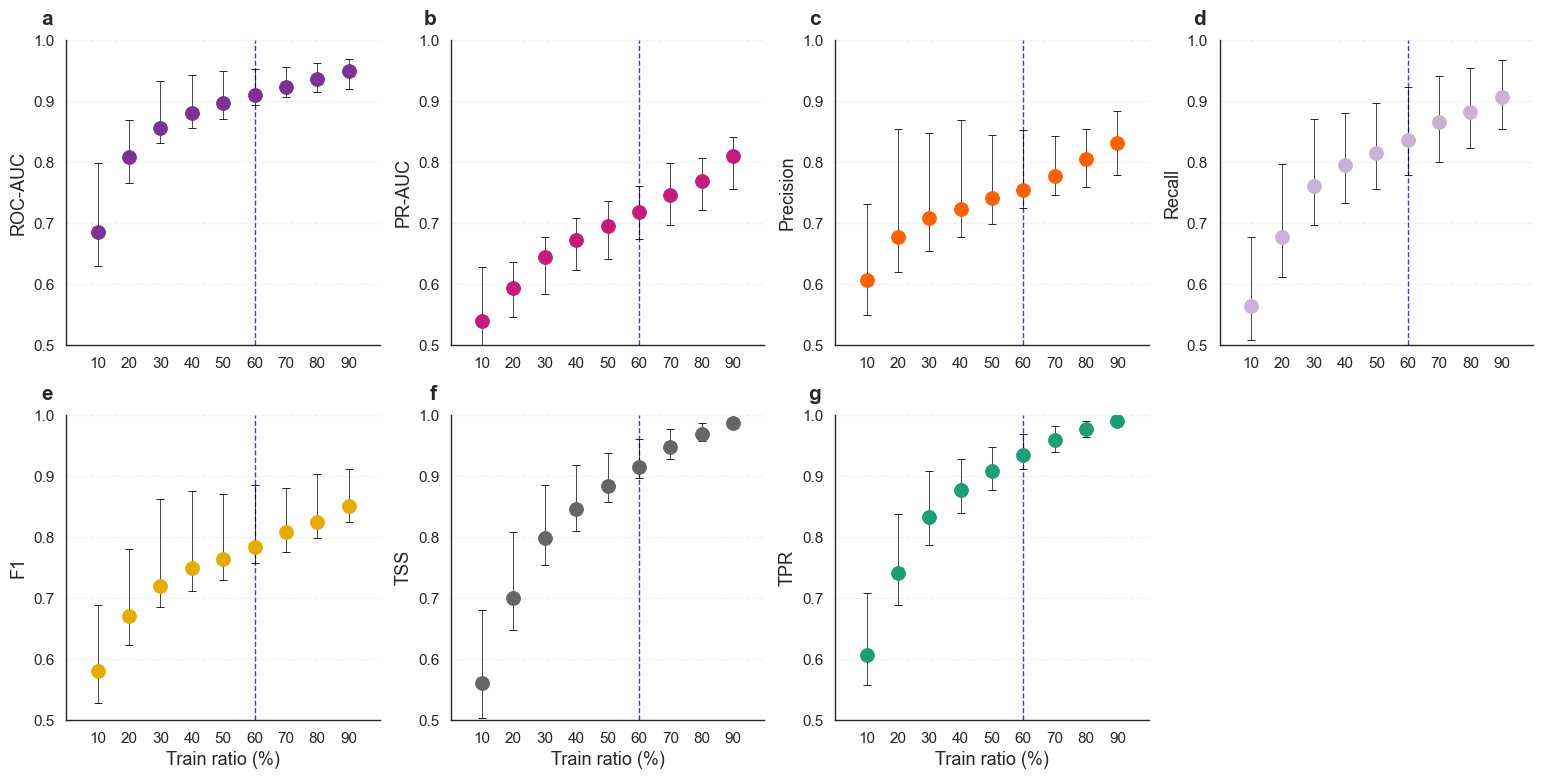

In [10]:
import os
import glob
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_context("paper")
sns.set_style("white")

# =========================
# Configuration
# =========================
RESULTS_DIR = "../../../src/matlab/data/result_sweep_train_ratios_10-90_pseudo_properties/prediction_scores_logs/"
FOODWEB_CSV = "../../../src/matlab/data/foodwebs_mat/foodweb_metrics_ecosystem.csv"
SINGLE_FILE = None
METRICS = ["ROC_AUC", "PR_AUC", "Precision", "Recall", "F1Score", "PseudoTSS", "PseudoTPR"]

# Display labels only
METRIC_LABELS = {
    "ROC_AUC": "ROC-AUC",
    "PR_AUC": "PR-AUC",
    "Precision": "Precision",
    "Recall": "Recall",
    "F1Score": "F1",
    "PseudoTSS": "TSS",
    "PseudoTPR": "TPR",
}

MAX_PLOTS = None
NODES_THRESHOLD = 40
SHOW_GRID = True
Y_MIN = 0.50

# Static y-axis for all panels
INDEPENDENT_Y = False
Y_PADDING = 0.02
Y_MAX_CAP = 1.0

metric_palette = {
    "ROC-AUC": "#7B3294",   # purple
    "PR-AUC": "#C51B7D",    # magenta
    "Precision": "#FE6100", # orange
    "Recall": "#CAB2D6",    # violet
    "F1": "#E6AB02",        # mustard
    "TSS": "#666666",       # dark gray
    "TPR": "#1B9E77",       # teal-green
}

# =========================
# Helpers
# =========================
def normalize_fw_label(name: str) -> str:
    name = str(name).strip()
    name, _ = os.path.splitext(name)
    name = name.replace(" ", "_")
    for token in ["_tax_mass_results_random_wlnm_dir_neg", "_result_", "_results", "_random", "_tax_mass", "_tax", "_mass"]:
        name = name.replace(token, "_")
    return "_".join(part for part in name.split("_") if part)


def derive_foodweb_from_filename(path: str) -> str:
    return normalize_fw_label(os.path.basename(path))


def load_results(results_dir=None, single_file=None, max_plots=None) -> pd.DataFrame:
    paths = []

    if results_dir and os.path.isdir(results_dir):
        paths.extend(sorted(glob.glob(os.path.join(results_dir, "*.csv"))))

    if single_file and os.path.isfile(single_file):
        paths.append(single_file)

    if not paths:
        raise FileNotFoundError("No CSV files found. Check RESULTS_DIR or SINGLE_FILE.")

    if max_plots is not None:
        paths = paths[:max_plots]
        print(f"[INFO] Limiting to first {len(paths)} CSV files.")

    frames = []
    for path in paths:
        try:
            df = pd.read_csv(path)
        except Exception as e:
            print(f"[WARNING] Skipping {path}: {e}")
            continue

        df.columns = [c.strip() for c in df.columns]
        df = df.rename(columns={c: c.upper() for c in df.columns})

        if "FOODWEB" not in df.columns:
            df["FOODWEB"] = derive_foodweb_from_filename(path)

        frames.append(df)

    if not frames:
        raise ValueError("No valid results loaded.")

    return pd.concat(frames, ignore_index=True)


def get_trainratio_column(columns):
    candidates = [c for c in columns if c.lower() in ["trainratio", "ratiotrain", "train_ratio"]]
    if not candidates:
        raise ValueError("No TrainRatio column found.")
    return candidates[0]


def set_trainratio_ticks(ax, train_ratios):
    ax.set_xticks(train_ratios)
    ax.set_xticklabels([str(t) if t % 10 == 0 else "" for t in train_ratios])


# =========================
# Load and filter data
# =========================
df = load_results(
    results_dir=RESULTS_DIR,
    single_file=SINGLE_FILE,
    max_plots=MAX_PLOTS,
)

meta = pd.read_csv(FOODWEB_CSV)
meta.columns = [c.strip() for c in meta.columns]

fw_col = next((c for c in meta.columns if c.lower() == "foodweb"), None)
nodes_col = next((c for c in meta.columns if c.lower() == "nodes"), None)

ecosystem_col = next(
    (c for c in meta.columns if c.lower() in ["ecosystem", "ecosystemtype", "ecosystem_type"]),
    None
)

if fw_col is None or nodes_col is None or ecosystem_col is None:
    raise ValueError(
        "Could not find 'Foodweb', 'Nodes', and ecosystem columns in FOODWEB_CSV."
    )

meta["FW_KEY"] = meta[fw_col].apply(normalize_fw_label)
df["FW_KEY"] = df["FOODWEB"].apply(normalize_fw_label)

meta_filtered = meta.loc[meta[nodes_col] >= NODES_THRESHOLD, ["FW_KEY", ecosystem_col]].copy()
meta_filtered = meta_filtered.rename(columns={ecosystem_col: "ECOSYSTEM"})
meta_filtered["ECOSYSTEM"] = meta_filtered["ECOSYSTEM"].astype(str).str.strip()

allowed_fw_keys = set(meta_filtered["FW_KEY"].unique())

print(f"[INFO] Foodwebs with Nodes >= {NODES_THRESHOLD}: {len(allowed_fw_keys)}")
print(f"[INFO] Foodwebs in results before filter: {df['FW_KEY'].nunique()}")

df = df[df["FW_KEY"].isin(allowed_fw_keys)].copy()

# Merge ecosystem into results
df = df.merge(meta_filtered, on="FW_KEY", how="left")

print(f"[INFO] Foodwebs in results after filter: {df['FOODWEB'].nunique()}")
print(f"[INFO] Ecosystems detected: {sorted(df['ECOSYSTEM'].dropna().unique().tolist())}")

if df.empty:
    raise ValueError(f"No foodwebs left after filtering Nodes >= {NODES_THRESHOLD}.")

# =========================
# Normalize TRAINRATIO
# =========================
trainratio_col = get_trainratio_column(df.columns)
df["TRAINRATIO"] = pd.to_numeric(df[trainratio_col], errors="coerce")
df = df.dropna(subset=["TRAINRATIO"]).copy()

if df["TRAINRATIO"].between(0, 1).all():
    df["TRAINRATIO"] = (df["TRAINRATIO"] * 100).round().astype(int)
else:
    df["TRAINRATIO"] = df["TRAINRATIO"].astype(int)

# =========================
# Long format
# =========================
metrics_present = [m for m in METRICS if m.upper() in df.columns]
if not metrics_present:
    raise ValueError("None of the requested metrics were found.")

df_long = pd.concat(
    [
        df[["FOODWEB", "ECOSYSTEM", "TRAINRATIO", metric.upper()]]
        .rename(columns={metric.upper(): "Value"})
        .assign(Metric=metric)
        for metric in metrics_present
    ],
    ignore_index=True,
)

# Mean per food web, train ratio, and metric
# No ecosystem split: each food web contributes one mean value per train ratio and metric
df_web_means = (
    df_long
    .groupby(["FOODWEB", "TRAINRATIO", "Metric"], as_index=False)["Value"]
    .mean()
)

# =========================
# Summary for plotting
# =========================
summary = (
    df_web_means
    .groupby(["TRAINRATIO", "Metric"])["Value"]
    .agg(
        median="median",
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
        n_webs="count",
    )
    .reset_index()
)

train_ratios = sorted(df_web_means["TRAINRATIO"].unique().tolist())
n_webs = df_web_means["FOODWEB"].nunique()

print(f"[INFO] Foodwebs used in final plot: {n_webs}")

# Consistent metric colors
metric_colors = {
    metric: metric_palette[METRIC_LABELS.get(metric, metric)]
    for metric in metrics_present
}
# =========================
# Final plot: 2 rows for metric panels
# =========================
n_metrics = len(metrics_present)
n_rows = 2
n_cols = int(np.ceil(n_metrics / n_rows))

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(4 * n_cols, 8.0),
    sharex=False,
    sharey=False
)

# Make axes always 2D, then flatten for easy indexing
if n_rows == 1 and n_cols == 1:
    axes = np.array([[axes]])
elif n_rows == 1:
    axes = np.array([axes])
elif n_cols == 1:
    axes = axes[:, np.newaxis]

axes_flat = axes.flatten()

panel_letters = list("abcdefghijklmnopqrstuvwxyz")

for i, metric in enumerate(metrics_present):
    ax = axes_flat[i]

    sub = summary[
        summary["Metric"] == metric
    ].sort_values("TRAINRATIO")

    if sub.empty:
        ax.set_axis_off()
        continue

    x = sub["TRAINRATIO"].to_numpy()
    y = sub["median"].to_numpy()
    yerr = np.vstack([
        (sub["median"] - sub["q25"]).to_numpy(),
        (sub["q75"] - sub["median"]).to_numpy(),
    ])

    color = metric_colors[metric]

    ax.errorbar(
        x,
        y,
        yerr=yerr,
        fmt="o",
        linestyle="none",
        color=color,
        ecolor="black",
        markersize=10,
        linewidth=1.2,
        elinewidth=0.5,
        capsize=3,
        capthick=0.8,
        markerfacecolor=color,
        markeredgecolor=color,
        markeredgewidth=0.6,
    )

    # Vertical reference line at train ratio = 60
    ax.axvline(
        x=60,
        color="blue",
        linestyle="--",
        linewidth=1.0,
        alpha=0.8,
        zorder=0,
    )

    # Independent y zoom per panel
    if INDEPENDENT_Y:
        local_min = max(Y_MIN, sub["q25"].min() - Y_PADDING)
        local_max = min(Y_MAX_CAP, sub["q75"].max() + Y_PADDING)

        if np.isclose(local_min, local_max):
            local_min = max(Y_MIN, local_min - 0.02)
            local_max = min(Y_MAX_CAP, local_max + 0.02)

        ax.set_ylim(local_min, local_max)
    else:
        ax.set_ylim(Y_MIN, 1.0)

    if SHOW_GRID:
        ax.grid(True, axis="y", linestyle="--", alpha=0.30)
    else:
        ax.grid(False)

    set_trainratio_ticks(ax, train_ratios)
    sns.despine(ax=ax)

    # No panel title; use the metric name as the y-axis title for each panel
    ax.set_title("")

    row_idx = i // n_cols
    col_idx = i % n_cols

    # x-label only on bottom row
    if row_idx == n_rows - 1:
        ax.set_xlabel("Train ratio (%)", fontsize=13)
    else:
        ax.set_xlabel("")

    # y-axis title for each panel
    ax.set_ylabel(METRIC_LABELS.get(metric, metric), fontsize=13)

    # Panel letters
    if i < len(panel_letters):
        ax.annotate(
            panel_letters[i],
            xy=(0, 1),
            xycoords="axes fraction",
            xytext=(-10, 8),
            textcoords="offset points",
            ha="right",
            va="bottom",
            fontsize=15,
            fontweight="bold",
            annotation_clip=False,
        )

    ax.tick_params(axis="both", labelsize=11)
    ax.set_xlim(min(train_ratios) - 10, max(train_ratios) + 10)

# Hide any unused subplot(s)
for j in range(n_metrics, len(axes_flat)):
    axes_flat[j].set_axis_off()

fig.tight_layout(rect=[0.03, 0, 1, 0.985])
plt.show()

[INFO] Foodwebs with Nodes >= 40: 160
[INFO] Foodwebs in results before filter: 290
[INFO] Foodwebs in results after filter: 160
[INFO] Ecosystems detected: ['lakes', 'marine', 'streams', 'terrestrial aboveground', 'terrestrial belowground']
[INFO] Foodwebs used in final plot: 160
[INFO] Train ratios detected: [10, 20, 30, 40, 50, 60, 70, 80, 90]


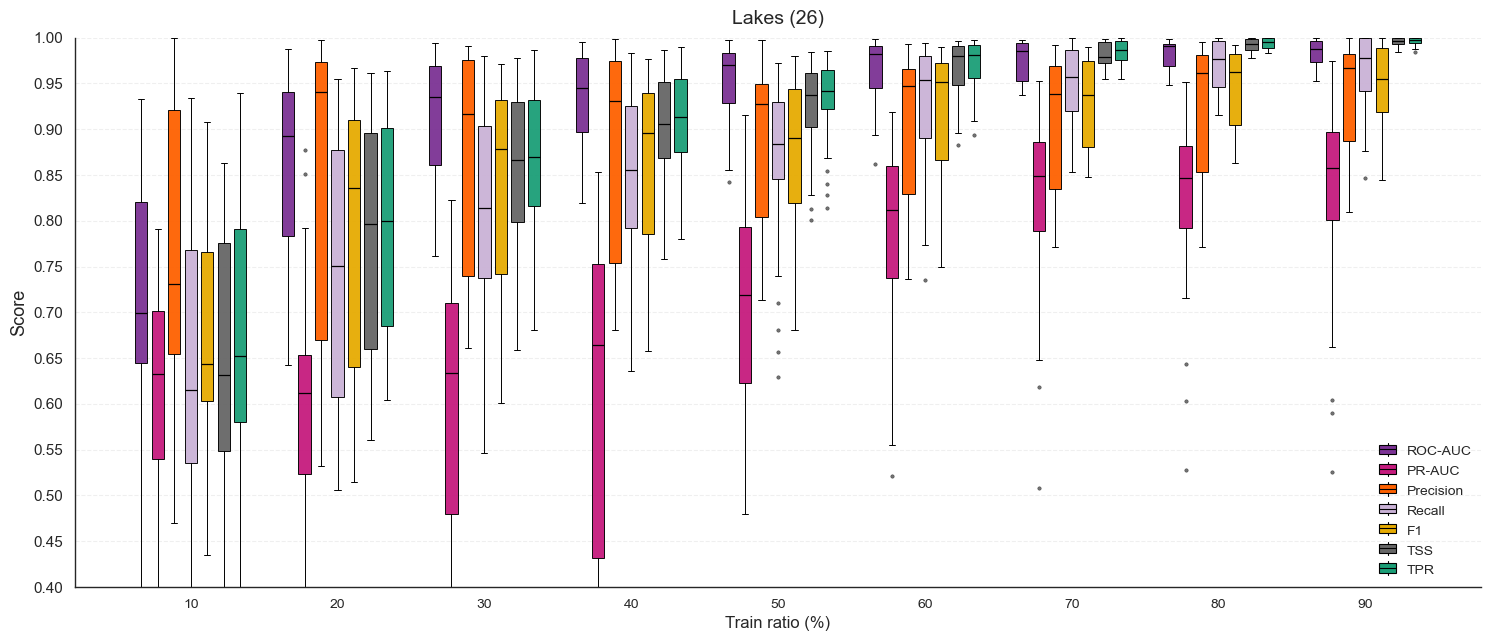

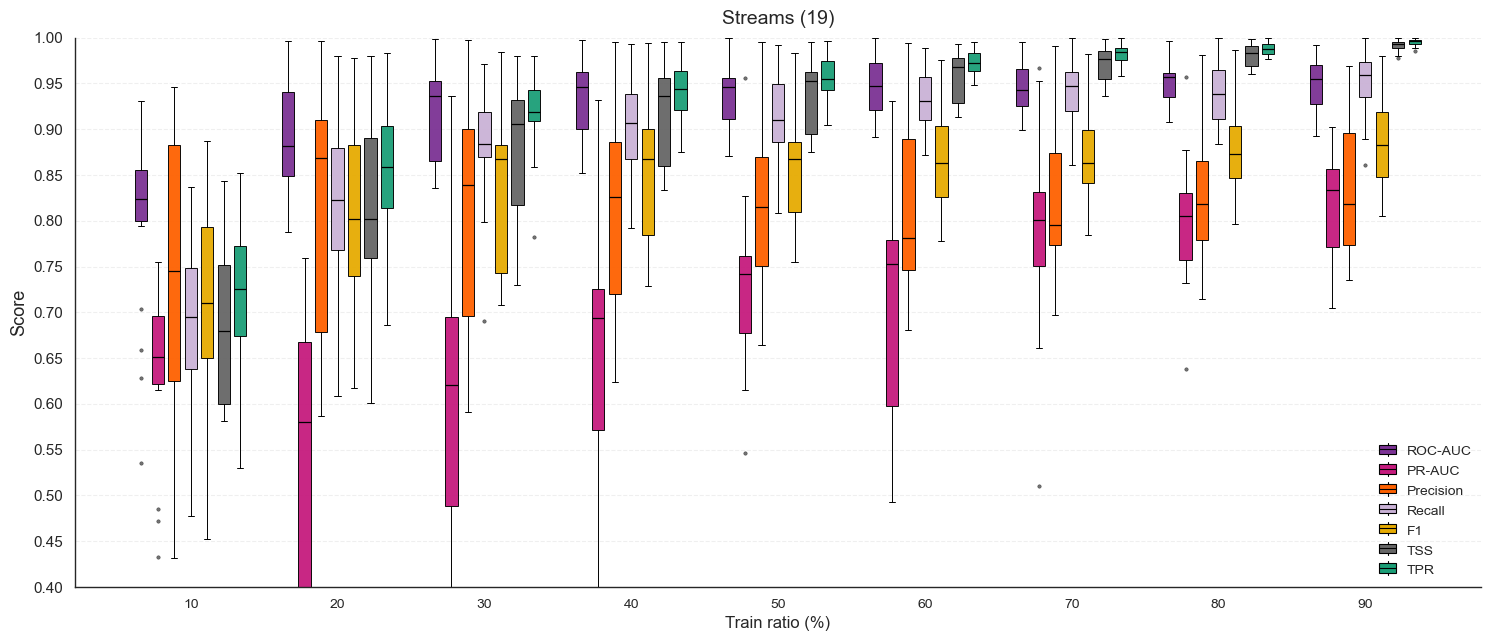

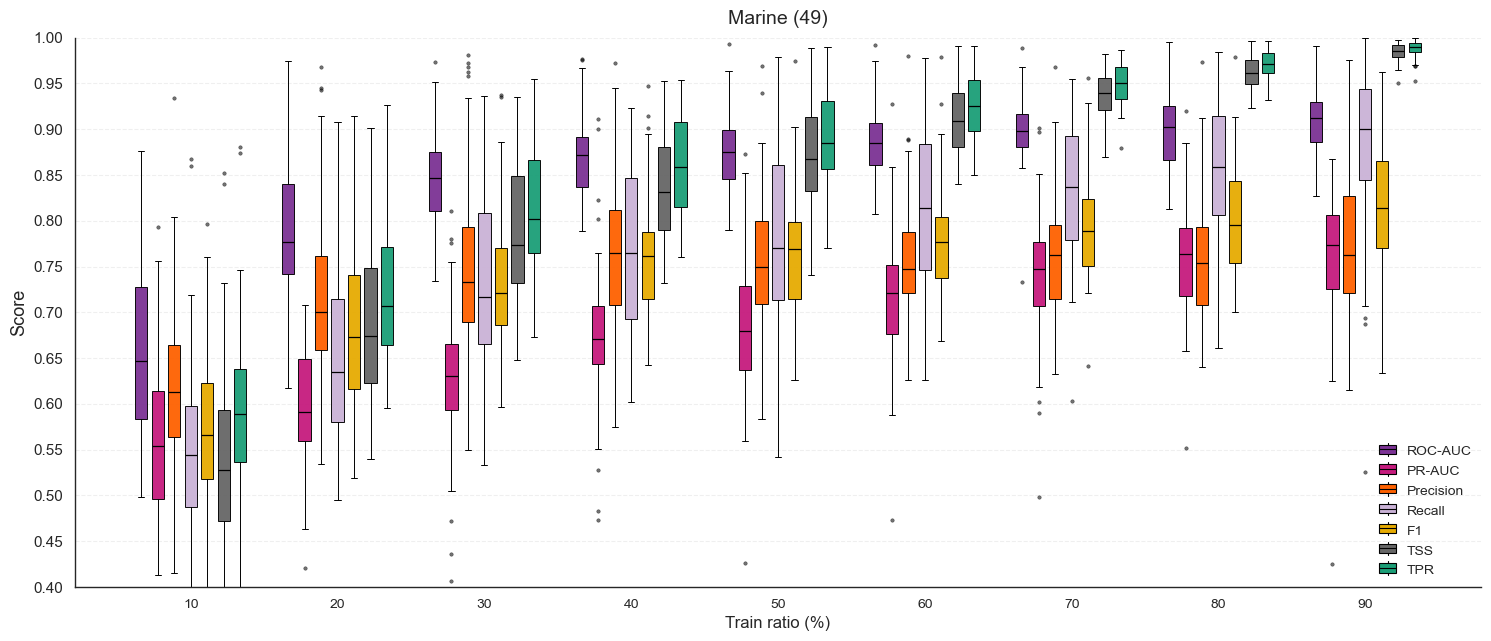

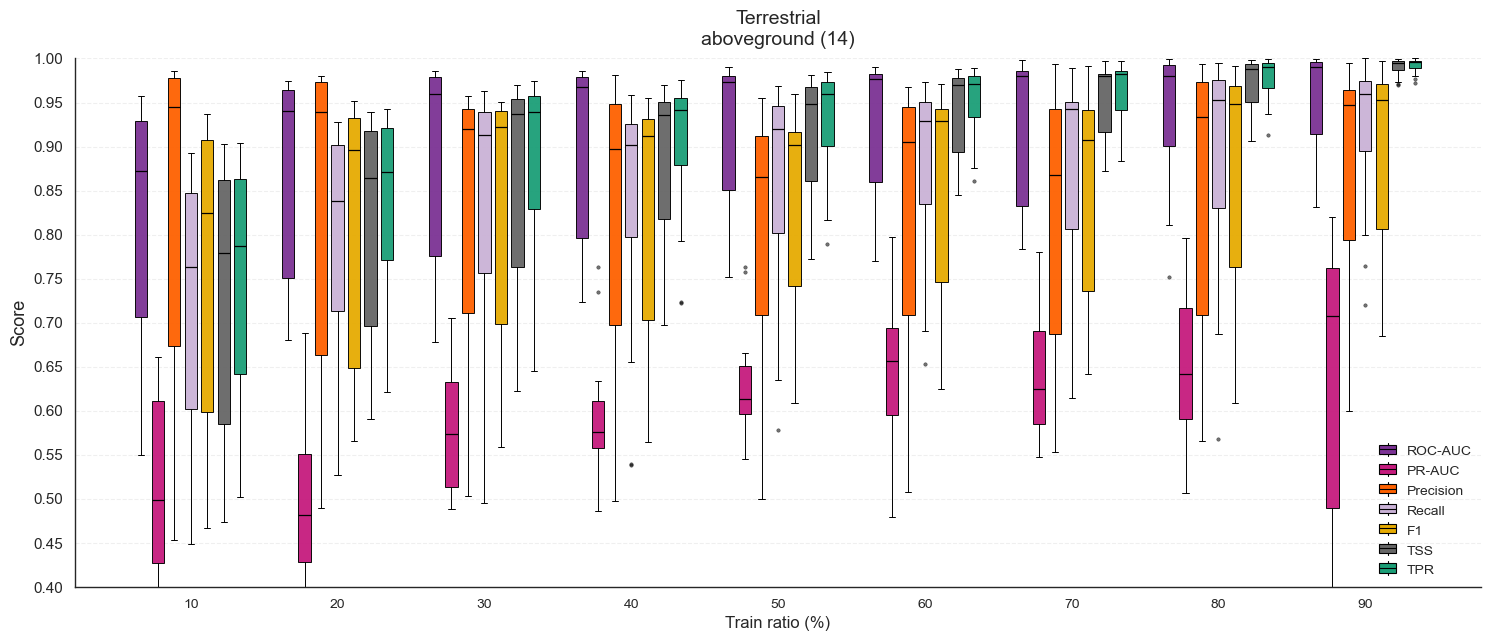

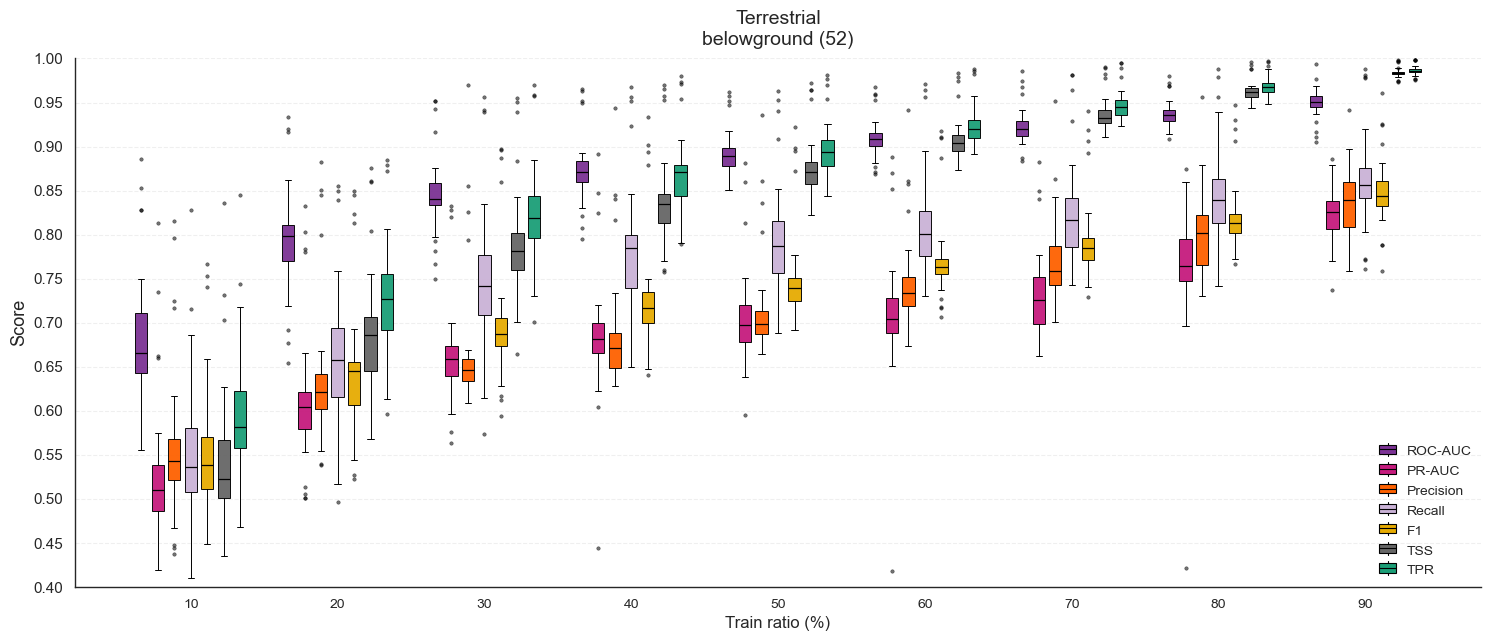

In [16]:
import os
import glob
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib.legend_handler import HandlerBase

sns.set_context("paper")
sns.set_style("white")

# =========================
# Configuration
# =========================
RESULTS_DIR = "../../../src/matlab/data/result_sweep_train_ratios_10-90_pseudo_properties/prediction_scores_logs/"
FOODWEB_CSV = "../../../src/matlab/data/foodwebs_mat/foodweb_metrics_ecosystem.csv"
SINGLE_FILE = None
METRICS = ["ROC_AUC", "PR_AUC", "Precision", "Recall", "F1Score", "PseudoTSS", "PseudoTPR"]

# Display labels only
METRIC_LABELS = {
    "ROC_AUC": "ROC-AUC",
    "PR_AUC": "PR-AUC",
    "Precision": "Precision",
    "Recall": "Recall",
    "F1Score": "F1",
    "PseudoTSS": "TSS",
    "PseudoTPR": "TPR",
}

MAX_PLOTS = None
NODES_THRESHOLD = 40
SHOW_GRID = True
Y_MIN = 0.40
Y_MAX_CAP = 1.0

metric_palette = {
    "ROC-AUC": "#7B3294",   # purple
    "PR-AUC": "#C51B7D",    # magenta
    "Precision": "#FE6100", # orange
    "Recall": "#CAB2D6",    # violet
    "F1": "#E6AB02",        # mustard
    "TSS": "#666666",       # dark gray
    "TPR": "#1B9E77",       # teal-green
}

preferred_ecosystem_order = [
    "lakes",
    "streams",
    "marine",
    "terrestrial aboveground",
    "terrestrial belowground",
]


# =========================
# Helpers
# =========================
def normalize_fw_label(name: str) -> str:
    name = str(name).strip()
    name, _ = os.path.splitext(name)
    name = name.replace(" ", "_")
    for token in [
        "_tax_mass_results_random_wlnm_dir_neg",
        "_result_",
        "_results",
        "_random",
        "_tax_mass",
        "_tax",
        "_mass",
    ]:
        name = name.replace(token, "_")
    return "_".join(part for part in name.split("_") if part)


def derive_foodweb_from_filename(path: str) -> str:
    return normalize_fw_label(os.path.basename(path))


def load_results(results_dir=None, single_file=None, max_plots=None) -> pd.DataFrame:
    paths = []

    if results_dir and os.path.isdir(results_dir):
        paths.extend(sorted(glob.glob(os.path.join(results_dir, "*.csv"))))

    if single_file and os.path.isfile(single_file):
        paths.append(single_file)

    if not paths:
        raise FileNotFoundError("No CSV files found. Check RESULTS_DIR or SINGLE_FILE.")

    if max_plots is not None:
        paths = paths[:max_plots]
        print(f"[INFO] Limiting to first {len(paths)} CSV files.")

    frames = []
    for path in paths:
        try:
            df = pd.read_csv(path)
        except Exception as e:
            print(f"[WARNING] Skipping {path}: {e}")
            continue

        df.columns = [c.strip() for c in df.columns]
        df = df.rename(columns={c: c.upper() for c in df.columns})

        if "FOODWEB" not in df.columns:
            df["FOODWEB"] = derive_foodweb_from_filename(path)

        frames.append(df)

    if not frames:
        raise ValueError("No valid results loaded.")

    return pd.concat(frames, ignore_index=True)


def get_trainratio_column(columns):
    candidates = [c for c in columns if c.lower() in ["trainratio", "ratiotrain", "train_ratio"]]
    if not candidates:
        raise ValueError("No TrainRatio column found.")
    return candidates[0]


def format_ecosystem_label(eco: str, n: int) -> str:
    eco_clean = str(eco).strip().lower()

    custom_labels = {
        "terrestrial aboveground": "Terrestrial\naboveground",
        "terrestrial belowground": "Terrestrial\nbelowground",
        "lakes": "Lakes",
        "streams": "Streams",
        "marine": "Marine",
    }

    label = custom_labels.get(eco_clean, str(eco).strip().capitalize())
    return f"{label} ({n})"


class HandlerMiniBoxplot(HandlerBase):
    def create_artists(
        self, legend, orig_handle,
        xdescent, ydescent, width, height, fontsize, trans
    ):
        facecolor = orig_handle["facecolor"]
        edgecolor = orig_handle.get("edgecolor", "black")
        linewidth = orig_handle.get("linewidth", 0.6)

        y_shift = -0.06 * height

        cx = xdescent + 0.5 * width
        cy = ydescent + 0.5 * height + y_shift

        box_w = 0.8 * width
        box_h = 0.8 * height
        box_x = cx - box_w / 2
        box_y = cy - box_h / 2

        whisk_top_y = box_y + box_h + 0.18 * height
        whisk_bot_y = box_y - 0.18 * height

        box = Rectangle(
            (box_x, box_y),
            box_w,
            box_h,
            facecolor=facecolor,
            edgecolor=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        median = Line2D(
            [box_x, box_x + box_w],
            [cy, cy],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        whisker_top = Line2D(
            [cx, cx],
            [box_y + box_h, whisk_top_y],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        whisker_bottom = Line2D(
            [cx, cx],
            [whisk_bot_y, box_y],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        return [box, median, whisker_top, whisker_bottom]


# =========================
# Load and filter data
# =========================
df = load_results(
    results_dir=RESULTS_DIR,
    single_file=SINGLE_FILE,
    max_plots=MAX_PLOTS,
)

meta = pd.read_csv(FOODWEB_CSV)
meta.columns = [c.strip() for c in meta.columns]

fw_col = next((c for c in meta.columns if c.lower() == "foodweb"), None)
nodes_col = next((c for c in meta.columns if c.lower() == "nodes"), None)

ecosystem_col = next(
    (c for c in meta.columns if c.lower() in ["ecosystem", "ecosystemtype", "ecosystem_type"]),
    None
)

if fw_col is None or nodes_col is None or ecosystem_col is None:
    raise ValueError(
        "Could not find 'Foodweb', 'Nodes', and ecosystem columns in FOODWEB_CSV."
    )

meta[nodes_col] = pd.to_numeric(meta[nodes_col], errors="coerce")

meta["FW_KEY"] = meta[fw_col].apply(normalize_fw_label)
df["FW_KEY"] = df["FOODWEB"].apply(normalize_fw_label)

meta_filtered = meta.loc[
    meta[nodes_col] >= NODES_THRESHOLD,
    ["FW_KEY", ecosystem_col]
].copy()

meta_filtered = meta_filtered.rename(columns={ecosystem_col: "ECOSYSTEM"})
meta_filtered["ECOSYSTEM"] = meta_filtered["ECOSYSTEM"].astype(str).str.strip()
meta_filtered = meta_filtered.drop_duplicates(subset=["FW_KEY"])

allowed_fw_keys = set(meta_filtered["FW_KEY"].unique())

print(f"[INFO] Foodwebs with Nodes >= {NODES_THRESHOLD}: {len(allowed_fw_keys)}")
print(f"[INFO] Foodwebs in results before filter: {df['FW_KEY'].nunique()}")

df = df[df["FW_KEY"].isin(allowed_fw_keys)].copy()

# Merge ecosystem into results
df = df.merge(meta_filtered, on="FW_KEY", how="left")

print(f"[INFO] Foodwebs in results after filter: {df['FOODWEB'].nunique()}")
print(f"[INFO] Ecosystems detected: {sorted(df['ECOSYSTEM'].dropna().unique().tolist())}")

if df.empty:
    raise ValueError(f"No foodwebs left after filtering Nodes >= {NODES_THRESHOLD}.")


# =========================
# Normalize TRAINRATIO
# =========================
trainratio_col = get_trainratio_column(df.columns)
df["TRAINRATIO"] = pd.to_numeric(df[trainratio_col], errors="coerce")
df = df.dropna(subset=["TRAINRATIO"]).copy()

if df["TRAINRATIO"].between(0, 1).all():
    df["TRAINRATIO"] = (df["TRAINRATIO"] * 100).round().astype(int)
else:
    df["TRAINRATIO"] = df["TRAINRATIO"].astype(int)


# =========================
# Long format
# =========================
metrics_present = [m for m in METRICS if m.upper() in df.columns]
if not metrics_present:
    raise ValueError("None of the requested metrics were found.")

df_long = pd.concat(
    [
        df[["FOODWEB", "ECOSYSTEM", "TRAINRATIO", metric.upper()]]
        .rename(columns={metric.upper(): "Value"})
        .assign(Metric=metric)
        for metric in metrics_present
    ],
    ignore_index=True,
)

df_long["Value"] = pd.to_numeric(df_long["Value"], errors="coerce")
df_long = df_long.dropna(subset=["Value", "ECOSYSTEM", "TRAINRATIO"]).copy()


# =========================
# Mean per food web, ecosystem, train ratio, and metric
# =========================
df_web_means = (
    df_long
    .groupby(["FOODWEB", "ECOSYSTEM", "TRAINRATIO", "Metric"], as_index=False)["Value"]
    .mean()
)


# =========================
# Ecosystem order and labels
# =========================
ecosystems_present = (
    df_web_means["ECOSYSTEM"]
    .dropna()
    .astype(str)
    .str.strip()
    .drop_duplicates()
    .tolist()
)

eco_lookup = {eco.lower(): eco for eco in ecosystems_present}

ecosystem_order = [
    eco_lookup[eco]
    for eco in preferred_ecosystem_order
    if eco in eco_lookup
]

ecosystem_order += [
    eco for eco in ecosystems_present
    if eco.lower() not in set(preferred_ecosystem_order)
]

labels_map = (
    df_web_means[["FOODWEB", "ECOSYSTEM"]]
    .drop_duplicates()
    .groupby("ECOSYSTEM")["FOODWEB"]
    .nunique()
    .to_dict()
)

labels_map = {
    eco: format_ecosystem_label(eco, n)
    for eco, n in labels_map.items()
}

train_ratios = sorted(df_web_means["TRAINRATIO"].dropna().unique().tolist())
metric_order = metrics_present

n_webs = df_web_means["FOODWEB"].nunique()
print(f"[INFO] Foodwebs used in final plot: {n_webs}")
print(f"[INFO] Train ratios detected: {train_ratios}")

# =========================
# Final plots: one independent figure per ecosystem type
# Each figure: one panel, train-ratio sweep, 7 metrics coloured
# =========================

# Layout control
trainratio_gap = 0.95
metric_offsets = np.linspace(-0.32, 0.32, len(metric_order))
box_width = 0.08

for eco in ecosystem_order:
    fig, ax = plt.subplots(figsize=(15, 6.5))

    # X positions for train ratios within this ecosystem
    x_positions = {
        tr: 1.0 + i * trainratio_gap
        for i, tr in enumerate(train_ratios)
    }

    # Boxplots: 7 metrics across train-ratio sweep
    for metric_idx, metric in enumerate(metric_order):
        data_for_metric = []
        positions_for_metric = []

        for tr in train_ratios:
            vals = (
                df_web_means.loc[
                    (df_web_means["ECOSYSTEM"] == eco)
                    & (df_web_means["TRAINRATIO"] == tr)
                    & (df_web_means["Metric"] == metric),
                    "Value"
                ]
                .dropna()
                .values
            )

            if len(vals) == 0:
                continue

            base_x = x_positions[tr]
            data_for_metric.append(vals)
            positions_for_metric.append(base_x + metric_offsets[metric_idx])

        if not data_for_metric:
            continue

        metric_label = METRIC_LABELS.get(metric, metric)
        color = metric_palette[metric_label]

        ax.boxplot(
            data_for_metric,
            positions=positions_for_metric,
            widths=box_width,
            patch_artist=True,
            manage_ticks=False,
            showfliers=True,
            boxprops=dict(
                facecolor=color,
                edgecolor="black",
                linewidth=0.7,
                alpha=0.95,
            ),
            medianprops=dict(color="black", linewidth=0.9),
            whiskerprops=dict(color="black", linewidth=0.7),
            capprops=dict(color="black", linewidth=0.7),
            flierprops=dict(
                marker="o",
                markersize=2.5,
                markerfacecolor="black",
                markeredgecolor="black",
                markeredgewidth=0.4,
                alpha=0.55,
            ),
        )

    # X-axis: train ratio sweep
    ax.set_xticks([x_positions[tr] for tr in train_ratios])
    ax.set_xticklabels([str(int(tr)) for tr in train_ratios], rotation=0, fontsize=9)

    ax.set_xlim(
        min(x_positions.values()) - 0.75,
        max(x_positions.values()) + 0.75
    )

    ax.set_ylim(Y_MIN, Y_MAX_CAP)
    ax.set_yticks(np.arange(Y_MIN, Y_MAX_CAP + 0.001, 0.05))

    ax.set_title(
        labels_map.get(eco, str(eco).strip().capitalize()),
        fontsize=14,
        pad=10
    )

    ax.set_ylabel("Score", fontsize=13)
    ax.set_xlabel("Train ratio (%)", fontsize=12)

    if SHOW_GRID:
        ax.grid(True, axis="y", linestyle="--", alpha=0.30)
    else:
        ax.grid(False)

    ax.grid(False, axis="x")
    ax.tick_params(axis="y", labelsize=11)
    ax.tick_params(axis="x", labelsize=10)

    # Legend
    legend_handles = [
        {
            "facecolor": metric_palette[METRIC_LABELS.get(m, m)],
            "edgecolor": "black",
            "linewidth": 0.8,
        }
        for m in metric_order
    ]

    ax.legend(
        handles=legend_handles,
        labels=[METRIC_LABELS.get(m, m) for m in metric_order],
        handler_map={dict: HandlerMiniBoxplot()},
        loc="lower right",
        frameon=False,
        fontsize=10,
        handlelength=1.5,
        handleheight=0.9,
        handletextpad=0.6,
        borderpad=0.2,
        labelspacing=0.45,
    )

    sns.despine(ax=ax)

    plt.tight_layout()
    plt.show()